# Análisis - Cruz Azul F.C. Intelligence
**Materia**: Clidad y Preprocesamiento de Datos
**Framework:** DAMA-DMBOK
**Etapa**: IV - Análisis de datos a través de minería de datos descriptiva, prescriptiva o predictiva

Con el objetivo de solucionar la incertidumbre presente en esta y siguientes temporadas, utilizaremos los conjuntos maestros resultantes de la etapa de Integración y Obtención de Datos Maestros.

---

## Fuentes de datos

| Archivo | Formato | Descripción |
|---------|---------|-------------|
| `master_jugadores.parquet`| Parquet | Dataset maestro de jugadores |
| `master_partidos.parquet` | Parquet | Dataset maestro de partidos |

## Problemáticas abordadas

| # | Pregunta | Tipo |
|---|----------|------|
| P1 | Valor de jugadores del equipo cobn respecto a perfiles similares en la liga | Descriptivo |
| P2 | Rendimiento en y fuera de casa de Cruz Azul en comparación a otros equipos | Descriptivo |
| P3 | Comparativa de desempeño - Extranjeros y nacionales en el equipo | Descriptivo |
| P4 | Equipos con mayor brecha entre su valoración FIFA y su valor real en Transfermarkt | Descriptivo |
| P5 | Proyección a dos años del valor de mercado todal de la plantilla del Cruz Azul en comparación a América y Rayados  | **Predictivo** |
| P6 | Jugadores con mayor probabilidad de ser transferidos en el próximo mercado de pases | **Predictivo** |
| P7 | Valor de mercado esperado de un jugador dado su rendimiento real y sus atributos FIFA  | **Predictivo** |
| P8 | Resultado esperado de un partido del Cruz Azul basado en histórico y diferencial de atributos entre plantillas  | **Predictivo** |
| P9 | Mediocampista que maximiza la relación rendimiento/costo para Cruz Azul con un presupuesto máximo  | *Prescriptivo* |
| P10 | Debilidades tácticas según goles concedidos con jugador a fichar para cubrirlas  | *Prescriptivo* |

In [46]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Patch
import seaborn as sns

# ML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, mean_squared_error, r2_score)
from xgboost import XGBClassifier, XGBRegressor
from sklearn.metrics import roc_curve

try:
    from statsmodels.tsa.holtwinters import ExponentialSmoothing as HoltETS
    _backend = 'holt'
except ImportError:
    from sklearn.preprocessing import PolynomialFeatures
    from sklearn.pipeline import make_pipeline
    from sklearn.linear_model import LinearRegression
    _backend = 'poly'


warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='muted')

# Rutas de los archivos
BASE = 'c:/Users/Unredeemer/Downloads'

df = pd.read_parquet(os.path.join(BASE, 'master_jugadores.parquet'))
partidos = pd.read_parquet(os.path.join(BASE, 'master_partidos.parquet'))

#  Helpers de filtrado por equipo
def es_ca(s): return s.str.contains('Cruz Azul', case=False, na=False)
def es_am(s): return s.str.contains('Am.rica', case=False, na=False, regex=True)
def es_ray(s): return s.str.contains('Monterrey|Rayados', case=False, na=False, regex=True)

CA = df[es_ca(df['equipo_norm'])].copy()

print('Jugadores cargados :', df.shape)
print('Partidos cargados :', partidos.shape)
print('Cruz Azul — registros en dataset:', len(CA))
n_eq = df['equipo_norm'].nunique()
print('Equipos únicos:', n_eq)
temps = sorted(df['season_year'].dropna().unique().astype(int).tolist())
print('Temporadas disponibles:', temps)
print('Columnas jugadores:', list(df.columns))

Jugadores cargados : (1150, 38)
Partidos cargados : (4080, 19)
Cruz Azul — registros en dataset: 52
Equipos únicos: 28
Temporadas disponibles: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
Columnas jugadores: ['player_id', 'nombre_canonico', 'nombre_key', 'nombre_transfermarkt', 'nombre_fifa', 'nombre_football_csv', 'sim_tm_fifa', 'sim_tm_csv', 'posicion', 'nacionalidad', 'segunda_nacionalidad', 'es_extranjero', 'doble_nacionalidad', 'edad', 'temporada', 'season_year', 'equipo', 'equipo_norm', 'fifa_overall', 'fifa_pace', 'fifa_shooting', 'fifa_passing', 'fifa_dribbling', 'fifa_defending', 'fifa_physical', 'valor_mercado_eur', 'transfer_paid_eur', 'goles', 'asistencias', 'partidos', 'g_a_por_90', 'p_casa', 'goles_casa', 'p_fuera', 'goles_fuera', 'tarj_am', 'tarj_roj', 'inconsistencias']


---
## P1 — ¿Cuánto vale un jugador de Cruz Azul respecto a perfiles similares en la liga?
> **Método:** Comparamos a través de percentiles de valor de mercado por posición + percentil de FIFA Overall de cada jugador de Cruz Azul dentro de su posición. 

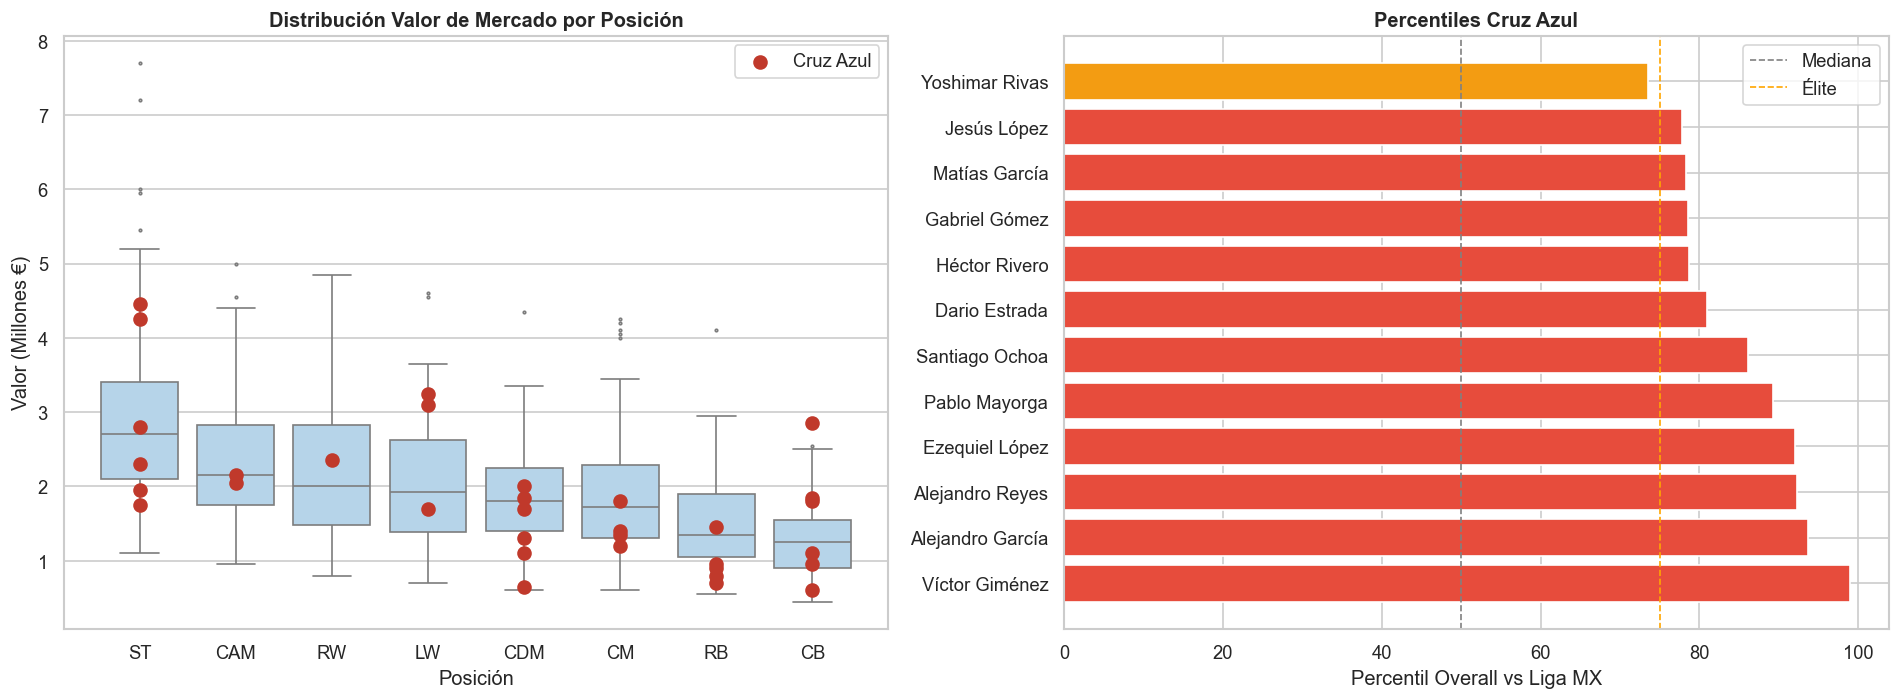


=== JUGADORES CRUZ AZUL — PERCENTIL Y VALOR ===


,Jugador,Pos,Edad,Overall,Valor Mercado,Percentil
924,Víctor Giménez,LW,35,84,EUR 3.1 M,98.9
380,Alejandro García,CM,32,83,N/A,93.7
478,Alejandro Reyes,SS,33,83,EUR 3.35 M,92.3
151,Ezequiel López,LW,34,82,EUR 1.7 M,92.0
905,Pablo Mayorga,CM,33,82,EUR 1.4 M,89.2
437,Santiago Ochoa,RB,36,81,EUR 0.95 M,86.1
249,Dario Estrada,GK,25,83,EUR 1.75 M,81.0
471,Héctor Rivero,ST,25,78,N/A,78.7
1091,Gabriel Gómez,LM,31,78,EUR 2.4 M,78.5
1070,Matías García,LB,23,79,EUR 1.8 M,78.3


In [47]:
# filtramos los que sí tienen valor de mercado y lo pasamos a millones
df_valor = df[df['valor_mercado_eur'].notna() & (df['valor_mercado_eur'] > 0)].copy()
df_valor['vm_m'] = df_valor['valor_mercado_eur'] / 1e6

posiciones_top = df_valor['posicion'].value_counts().head(8).index.tolist()
df_v8 = df_valor[df_valor['posicion'].isin(posiciones_top)]
ca_valor = df_v8[es_ca(df_v8['equipo_norm'])]

orden = df_v8.groupby('posicion')['vm_m'].median().sort_values(ascending=False).index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Graficamos el boxplot de valor
ax = axes[0]
sns.boxplot(data=df_v8, x='posicion', y='vm_m', order=orden, color='#AED6F1', fliersize=1.5, ax=ax)

# encimamos los puntos del cruz azul
flag_leyenda = False
for _, row in ca_valor.iterrows():
    if row['posicion'] in orden:
        idx = orden.index(row['posicion'])
        label = 'Cruz Azul' if not flag_leyenda else ''
        ax.scatter(idx, row['vm_m'], color='#C0392B', s=60, zorder=5, label=label)
        flag_leyenda = True
        
ax.set_title('Distribución Valor de Mercado por Posición', fontweight='bold')
ax.set_xlabel('Posición')
ax.set_ylabel('Valor (Millones €)')
ax.legend(loc='upper right')

# calculamos percentiles de FIFA Overall
df_ov = df[df['fifa_overall'].notna()].copy()
ca_ov = df_ov[es_ca(df_ov['equipo_norm'])].copy()

def saca_percentil(row, ref):
    peers = ref.loc[ref['posicion'] == row['posicion'], 'fifa_overall'].dropna()
    if len(peers) <= 1: return np.nan
    return round((peers < row['fifa_overall']).mean() * 100, 1)

ca_ov['pctil'] = ca_ov.apply(lambda r: saca_percentil(r, df_ov), axis=1)
top12 = ca_ov.nlargest(12, 'pctil')[['nombre_canonico', 'posicion', 'fifa_overall', 'pctil']].dropna()

ax2 = axes[1]
colores = ['#E74C3C' if p >= 75 else '#F39C12' if p >= 50 else '#3498DB' for p in top12['pctil']]
ax2.barh(top12['nombre_canonico'], top12['pctil'], color=colores)
ax2.axvline(50, color='gray', ls='--', lw=1, label='Mediana')
ax2.axvline(75, color='orange', ls='--', lw=1, label='Élite')
ax2.set_xlabel('Percentil Overall vs Liga MX')
ax2.set_title('Percentiles Cruz Azul', fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.show()

# Tabla 
print('\n=== JUGADORES CRUZ AZUL — PERCENTIL Y VALOR ===')
tabla = ca_ov[['nombre_canonico', 'posicion', 'edad', 'fifa_overall', 'valor_mercado_eur', 'pctil']].dropna(subset=['pctil'])
tabla = tabla.sort_values('pctil', ascending=False).copy()
tabla['valor_mercado_eur'] = tabla['valor_mercado_eur'].apply(lambda x: ('EUR ' + str(round(x / 1e6, 2)) + ' M') if pd.notna(x) else 'N/A')
tabla.columns = ['Jugador', 'Pos', 'Edad', 'Overall', 'Valor Mercado', 'Percentil']
display(tabla.head(15))

---
## P2 — ¿Cruz Azul rinde mejor en casa que fuera? ¿Cómo se compara con la liga?
> **Método:** Calculamos los puntos por partido (PPP) promedios en casa y fuera agrupando para cada equipo, para después realizar un ranking de ventaja local.  

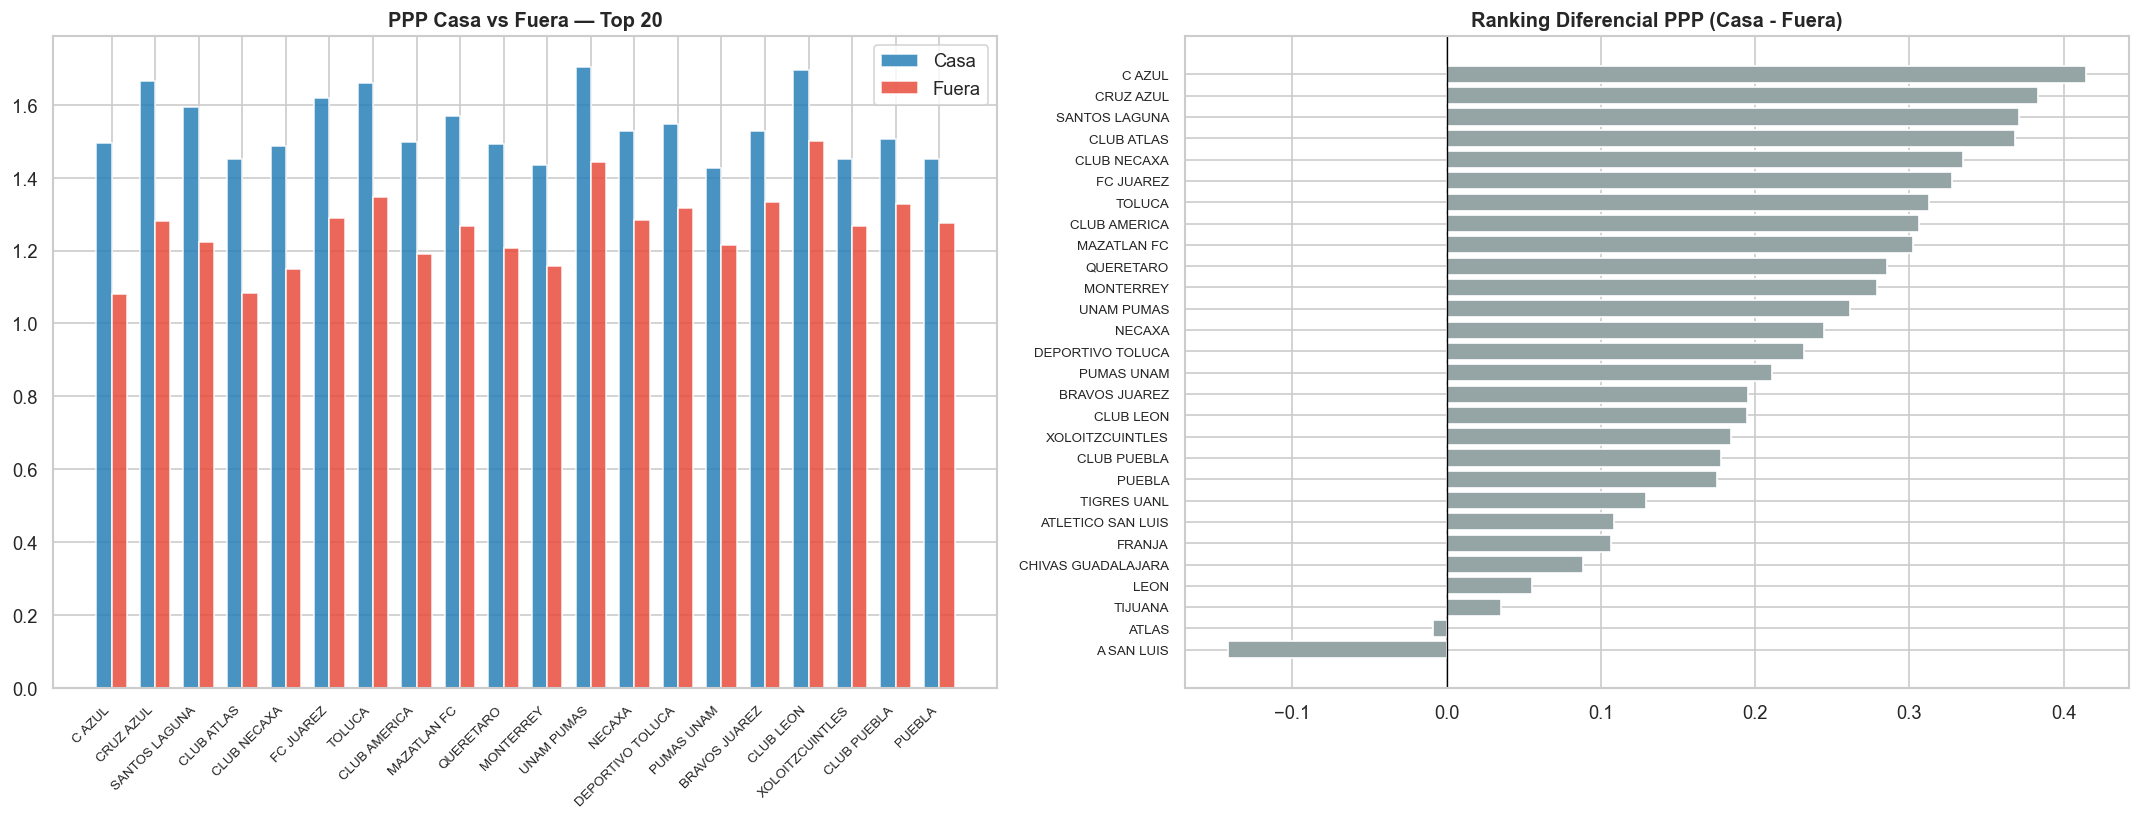

In [48]:

def saca_puntos(res, es_local=True):
    if res == 'D': return 1
    if es_local: return 3 if res == 'W' else 0
    else: return 3 if res == 'L' else 0

partidos_limpios = partidos[partidos['resultado_local'].isin(['W', 'D', 'L'])].copy()
partidos_limpios['pts_local'] = partidos_limpios['resultado_local'].apply(lambda x: saca_puntos(x, True))
partidos_limpios['pts_visitante'] = partidos_limpios['resultado_local'].apply(lambda x: saca_puntos(x, False))

# Cálculo de los puntos medios
ppp_casa = partidos_limpios.groupby('equipo_local_norm')['pts_local'].mean().rename('Casa')
ppp_fuera = partidos_limpios.groupby('equipo_visitante_norm')['pts_visitante'].mean().rename('Fuera')

df_ventaja = pd.concat([ppp_casa, ppp_fuera], axis=1).dropna()
df_ventaja['Ventaja'] = df_ventaja['Casa'] - df_ventaja['Fuera']
df_ventaja.sort_values('Ventaja', ascending=False, inplace=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# graficamos el top 20
top20 = df_ventaja.head(20)
x = np.arange(len(top20))
w = 0.35

ax1.bar(x - w/2, top20['Casa'], w, label='Casa', color='#2980B9', alpha=0.85)
ax1.bar(x + w/2, top20['Fuera'], w, label='Fuera', color='#E74C3C', alpha=0.85)

# resaltamos al cruz azul
for i, team in enumerate(top20.index):
    if 'Cruz' in str(team):
        ax1.bar(i - w/2, top20.loc[team, 'Casa'], w, color='red')
        ax1.bar(i + w/2, top20.loc[team, 'Fuera'], w, color='red')
        
ax1.set_xticks(x)
ax1.set_xticklabels(top20.index, rotation=45, ha='right', fontsize=8)
ax1.set_title('PPP Casa vs Fuera — Top 20', fontweight='bold')
ax1.legend()

# ranking de ventaja local
v_sorted = df_ventaja.sort_values('Ventaja', ascending=True)
colores_barras = ['#E74C3C' if 'Cruz' in str(t) else '#95A5A6' for t in v_sorted.index]

ax2.barh(range(len(v_sorted)), v_sorted['Ventaja'], color=colores_barras)
ax2.set_yticks(range(len(v_sorted)))
ax2.set_yticklabels(v_sorted.index, fontsize=8)
ax2.axvline(0, color='black', lw=0.8)
ax2.set_title('Ranking Diferencial PPP (Casa - Fuera)', fontweight='bold')

plt.tight_layout()
plt.show()



---
## P3 — ¿Cómo se comparan las métricas de desempeño de los jugadores extranjeros en comparación con los nacionales dentro del club?
> **Método:** Comparamos el valor de mercado, FIFA Overall y G+A/90 entre extranjeros y nacionales en Cruz Azul para contrastar con la liga.  

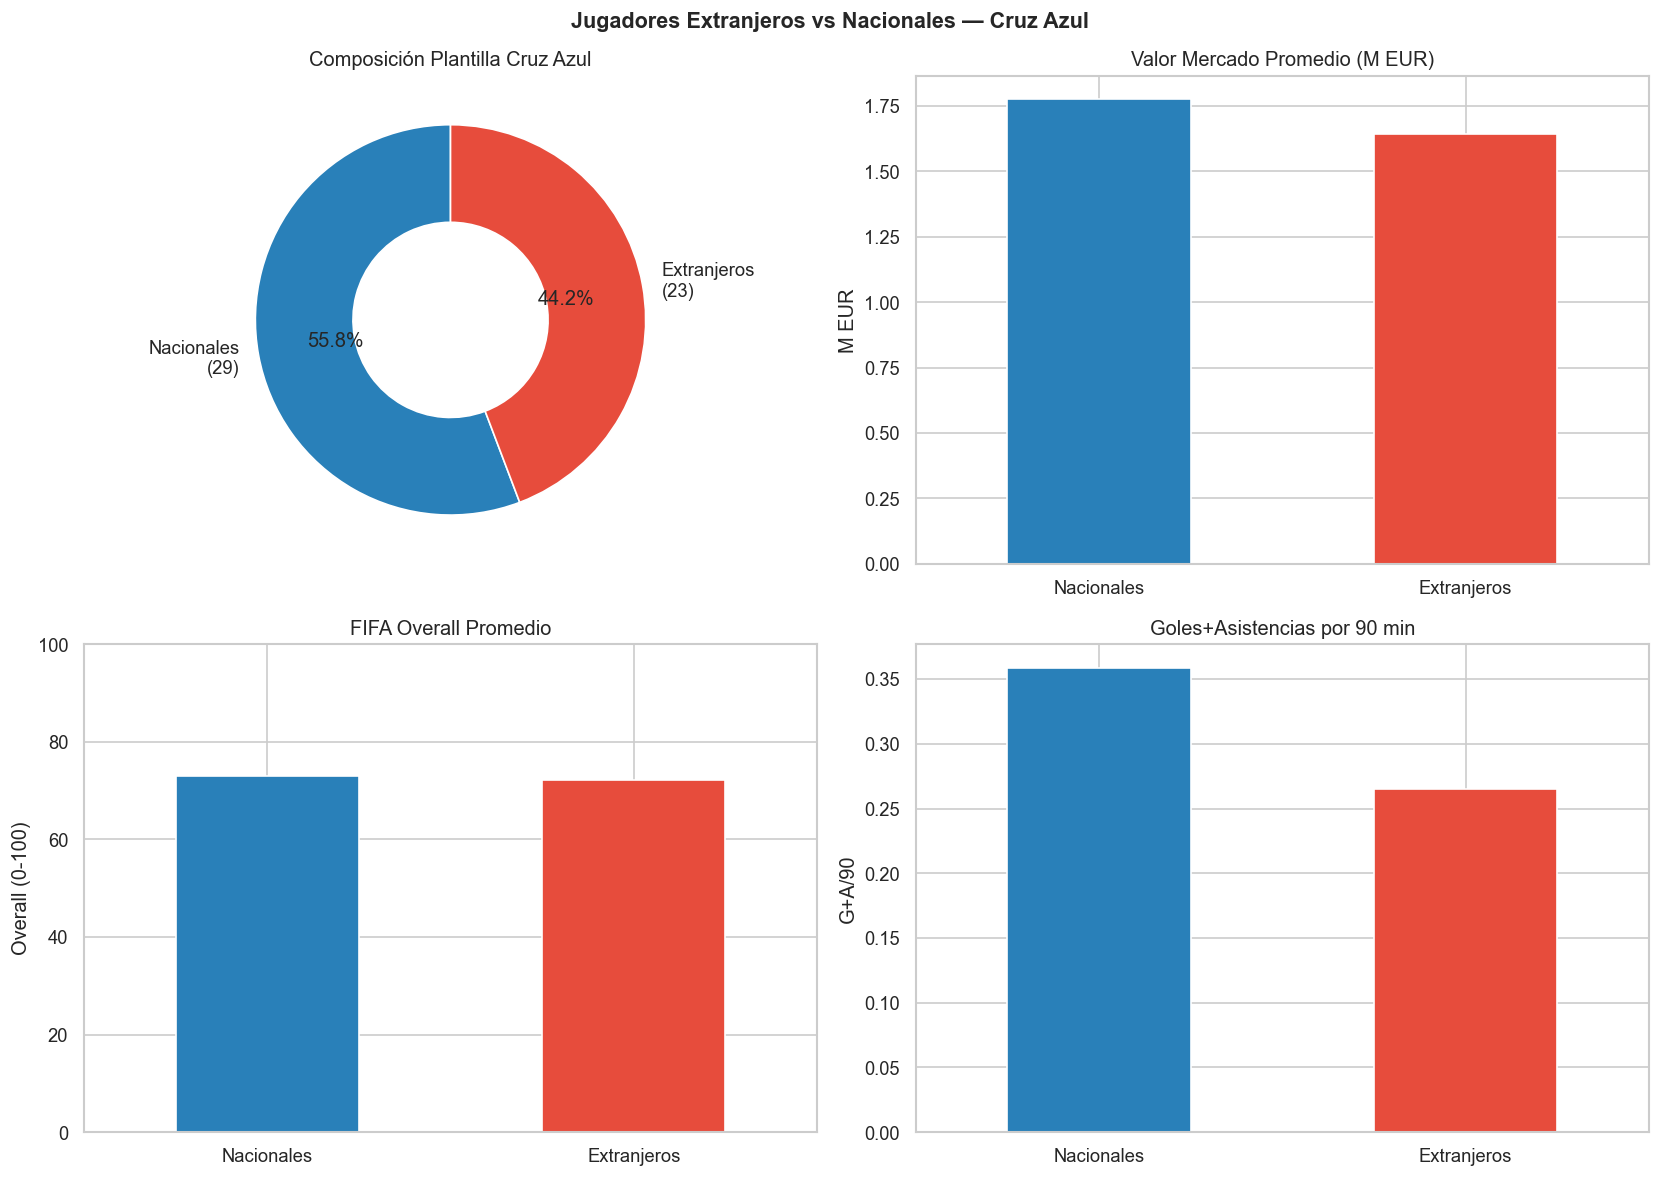


=== CRUZ AZUL: COMPARATIVA POR POSICIÓN Y ORIGEN ===


n  overall  valor_m  ga90
posicion extran                                
CAM      Nacionales   1    66.00     2.15  3.05
         Extranjeros  1    69.00     2.05  0.00
CB       Nacionales   4    71.75     1.30  0.13
         Extranjeros  2    73.00     1.98  0.16
CDM      Nacionales   3    70.67     1.50  0.20
         Extranjeros  3    71.33     1.37  0.41
CM       Nacionales   3    78.67     1.60  0.21
         Extranjeros  3    66.67     1.27  0.09
GK       Nacionales   4    78.50     1.19  0.07
         Extranjeros  2    79.50     1.42  0.21
LB       Nacionales   2    66.50     0.82  0.20
         Extranjeros  1    79.00     1.80  0.00
LM       Extranjeros  1    78.00     2.40  0.36
LW       Nacionales   1    84.00     3.10  0.13
         Extranjeros  3    76.33     2.48  0.59
RB       Nacionales   2    72.50     0.92  0.08
         Extranjeros  3    70.67     0.98  0.17
RM       Nacionales   2    66.50     1.30  0.04
         Extranjeros  1    66.00     1.00  0.41
RW       Nacionales   2    69.00     2.35  0.38
SS       Nacionales   1    83.00     3.35  0.54
ST       Nacionales   4    71.50     3.31  0.83
         Extranjeros  3    69.00     2.12  0.28


=== LIGA MX: EXTRANJEROS vs NACIONALES ===


,n,overall,valor_m,ga90
Nacionales,716,72.47,1.90,0.32
Extranjeros,434,73.08,1.89,0.30


In [49]:
CA4 = df[es_ca(df['equipo_norm'])].copy()
CA4['extran'] = CA4['es_extranjero'].fillna(False)

ext_count = int(CA4['extran'].sum())
nac_count = int((~CA4['extran']).sum())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0, 0]
ax.pie([nac_count, ext_count],
       labels=[f'Nacionales\n({nac_count})', f'Extranjeros\n({ext_count})'],
       colors=['#2980B9', '#E74C3C'],
       autopct='%1.1f%%', startangle=90,
       wedgeprops=dict(width=0.5))
ax.set_title('Composición Plantilla Cruz Azul')

def media_seg(df_in, col):
    return df_in.groupby('extran')[col].mean()

def plot_bar_p4(ax, serie, title, ylabel, fmt=None):
    serie.index = ['Nacionales', 'Extranjeros']
    serie.plot(kind='bar', ax=ax, color=['#2980B9', '#E74C3C'], rot=0)
    ax.set_title(title)
    ax.set_ylabel(ylabel)

#  Valor de mercado promedio
vm_ser = (CA4.groupby('extran')['valor_mercado_eur'].mean().fillna(0) / 1e6)
plot_bar_p4(axes[0, 1], vm_ser, 'Valor Mercado Promedio (M EUR)', 'M EUR')

# FIFA Overall promedio
ov_ser = media_seg(CA4, 'fifa_overall').fillna(0)
plot_bar_p4(axes[1, 0], ov_ser, 'FIFA Overall Promedio', 'Overall (0-100)')
axes[1, 0].set_ylim(0, 100)

# G+A por 90 min
ga_ser = media_seg(CA4, 'g_a_por_90').fillna(0)
plot_bar_p4(axes[1, 1], ga_ser, 'Goles+Asistencias por 90 min', 'G+A/90')
fig.suptitle('Jugadores Extranjeros vs Nacionales — Cruz Azul', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Tabla comparativa 
print('\n=== CRUZ AZUL: COMPARATIVA POR POSICIÓN Y ORIGEN ===')
tabla_pos = CA4.groupby(['posicion', 'extran']).agg(
    n=('nombre_canonico', 'count'),
    overall=('fifa_overall', 'mean'),
    valor_m=('valor_mercado_eur', lambda x: x.mean() / 1e6),
    ga90=('g_a_por_90', 'mean')
).round(2)
tabla_pos.index = tabla_pos.index.set_levels(['Nacionales', 'Extranjeros'], level=1)
display(tabla_pos)

# Comparativa vs liga
print('\n=== LIGA MX: EXTRANJEROS vs NACIONALES ===')
liga_comp = df.copy()
liga_comp['extran'] = liga_comp['es_extranjero'].fillna(False)
liga_agg = liga_comp.groupby('extran').agg(
    n=('nombre_canonico', 'count'),
    overall=('fifa_overall', 'mean'),
    valor_m=('valor_mercado_eur', lambda x: x.dropna().mean() / 1e6),
    ga90=('g_a_por_90', 'mean')
).round(2)
liga_agg.index = ['Nacionales', 'Extranjeros']
display(liga_agg)

---
## P4 — ¿Qué equipos presentan mayor brecha entre valoración FIFA y valor Transfermarkt?
> **Método:** Normalizamos FIFA Overall y transformamos con log(Valor TM) a rango 0-1. Calculamos la brecha = FIFA_norm − TM_norm para posteriormente agregar por equipo.  

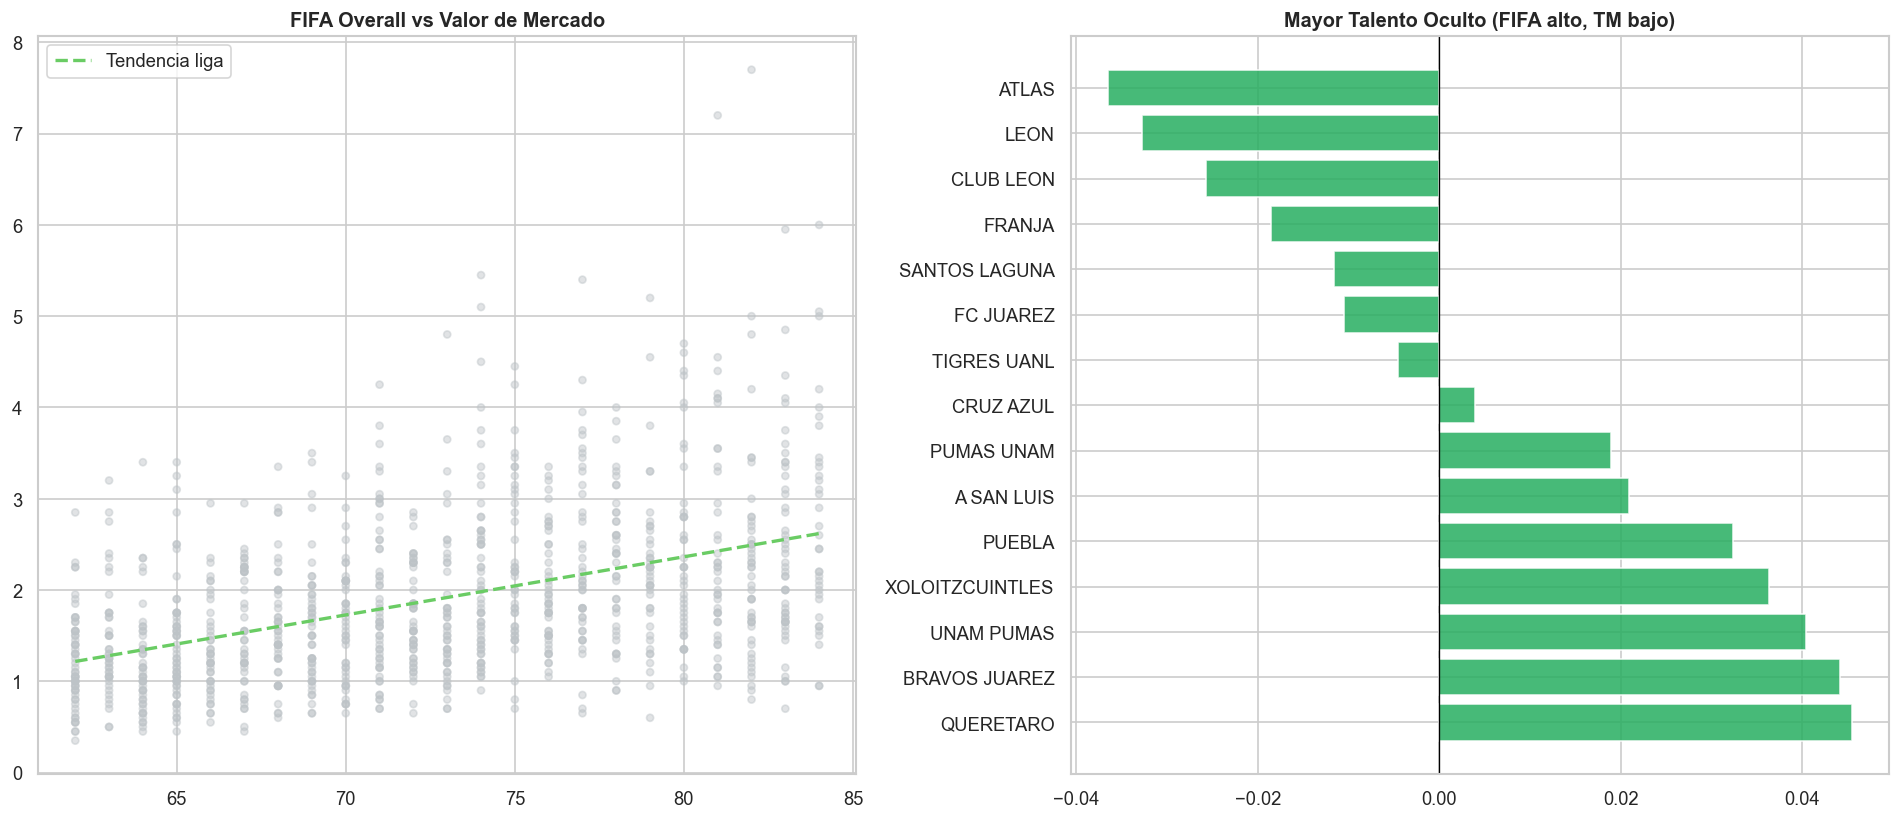


=== TOP 10 EQUIPOS CON MAYOR TALENTO OCULTO ===


,equipo_norm,brecha_media,n,overall_prom,vm_prom
21,QUERETARO,0.045,68,74.544,1905882.353
3,BRAVOS JUAREZ,0.044,24,73.167,1610416.667
26,UNAM PUMAS,0.040,21,74.857,2145238.095
27,XOLOITZCUINTLES,0.036,23,73.696,1865217.391
19,PUEBLA,0.032,19,72.316,1507894.737
0,A SAN LUIS,0.021,20,72.950,1677500.000
20,PUMAS UNAM,0.019,22,74.000,2011363.636
11,CRUZ AZUL,0.004,47,72.553,1719148.936
23,TIGRES UANL,-0.005,70,73.357,2013571.429
13,FC JUAREZ,-0.011,49,73.163,1958163.265



=== TOP 10 JUGADORES SUBVALORADOS POR TRANSFERMARKT ===


,nombre_canonico,equipo_norm,posicion,fifa_overall,valor_mercado_eur,brecha
159,Sebastián Rodríguez,BRAVOS JUAREZ,GK,83,0.70,0.730
197,Fernando Ochoa,LEON,CB,84,0.95,0.677
781,Rodrigo Pérez,QUERETARO,CB,84,0.95,0.677
131,Eduardo Corona,FRANJA,GK,82,0.80,0.642
59,Franco Orellana,TIGRES UANL,CB,83,1.00,0.615
788,Diego Rodríguez,TIGRES UANL,GK,83,1.00,0.615
750,Pol Guerrero,UNAM PUMAS,CB,82,0.90,0.604
708,Alan Lozano,QUERETARO,CB,83,1.05,0.599
535,Ramón Moreno,MAZATLAN FC,GK,79,0.60,0.598
629,Carlos Mora,BRAVOS JUAREZ,CB,82,0.95,0.586


In [50]:
df_brecha = df[df['valor_mercado_eur'].notna() & df['fifa_overall'].notna() & (df['valor_mercado_eur'] > 0)].copy()

# normalizamos para poder compararlos 
scaler = MinMaxScaler()
df_brecha['ov_norm'] = scaler.fit_transform(df_brecha[['fifa_overall']])
df_brecha['vm_norm'] = scaler.fit_transform(np.log1p(df_brecha['valor_mercado_eur']).values.reshape(-1, 1))

# Índice de brecha: si es positivo, está subvalorado en TM
df_brecha['brecha'] = df_brecha['ov_norm'] - df_brecha['vm_norm']

brecha_equipos = df_brecha.groupby('equipo_norm').agg(
    brecha_media=('brecha', 'mean'),
    n=('nombre_canonico', 'count'),          
    overall_prom=('fifa_overall', 'mean'),   
    vm_prom=('valor_mercado_eur', 'mean')    
).reset_index()
brecha_equipos = brecha_equipos[brecha_equipos['n'] >= 5].sort_values('brecha_media', ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# scatter plot
def asigna_color(t):
    if 'Cruz' in str(t): return '#E74C3C'
    if 'América' in str(t) or 'America' in str(t): return '#F39C12'
    if 'Monterrey' in str(t) or 'Rayados' in str(t): return '#2980B9'
    return '#BDC3C7'

colores_scatter = df_brecha['equipo_norm'].apply(asigna_color)
ax1.scatter(df_brecha['fifa_overall'], df_brecha['valor_mercado_eur'] / 1e6, c=colores_scatter, alpha=0.45, s=18)

# linea de tendencia de la liga
z = np.polyfit(df_brecha['fifa_overall'], df_brecha['valor_mercado_eur'] / 1e6, 1)
x_line = np.linspace(df_brecha['fifa_overall'].min(), df_brecha['fifa_overall'].max(), 100)
ax1.plot(x_line, np.poly1d(z)(x_line), 'g--', lw=2, label='Tendencia liga')
ax1.set_title('FIFA Overall vs Valor de Mercado', fontweight='bold')
ax1.legend()

# ranking de talento oculto
top_brecha = brecha_equipos.head(15)
colores_bar = ['#E74C3C' if 'Cruz' in str(t) else '#27AE60' for t in top_brecha['equipo_norm']]
ax2.barh(top_brecha['equipo_norm'], top_brecha['brecha_media'], color=colores_bar, alpha=0.85)
ax2.axvline(0, color='black', lw=0.8)
ax2.set_title('Mayor Talento Oculto (FIFA alto, TM bajo)', fontweight='bold')

plt.tight_layout()
plt.show()

print('\n=== TOP 10 EQUIPOS CON MAYOR TALENTO OCULTO ===')
display(brecha_equipos[['equipo_norm', 'brecha_media', 'n', 'overall_prom', 'vm_prom']].head(10).round(3))

# Top 10 jugadores subvalorados en Liga MX
top_jug = df_brecha.nlargest(10, 'brecha')[['nombre_canonico', 'equipo_norm', 'posicion', 'fifa_overall', 'valor_mercado_eur', 'brecha']].copy()
top_jug['valor_mercado_eur'] = top_jug['valor_mercado_eur'] / 1e6
print('\n=== TOP 10 JUGADORES SUBVALORADOS POR TRANSFERMARKT ===')
display(top_jug.round(3))


---
## P5 — ¿Cómo evolucionará (2 años) el valor de mercado total de la plantilla de Cruz Azul temporada a temporada comparado con América y Rayados?
> **Método:** Proyectamos una serie de tiempo del valor acumulado de plantilla por temporada para Cruz Azul, América y Rayados y calculamos la variación porcentual entre temporadas. Posteriormente, usamos **Holt's Linear Smoothing** (suavización exponencial doble) para ajustar por equipo sobre la serie 2010–2024. Aprende nivel y tendencia vía optimización MLE, sin asumir estacionariedad, y proyecta **2025 y 2026** con intervalo de confianza del 90% (banda proporcional a √horizonte).

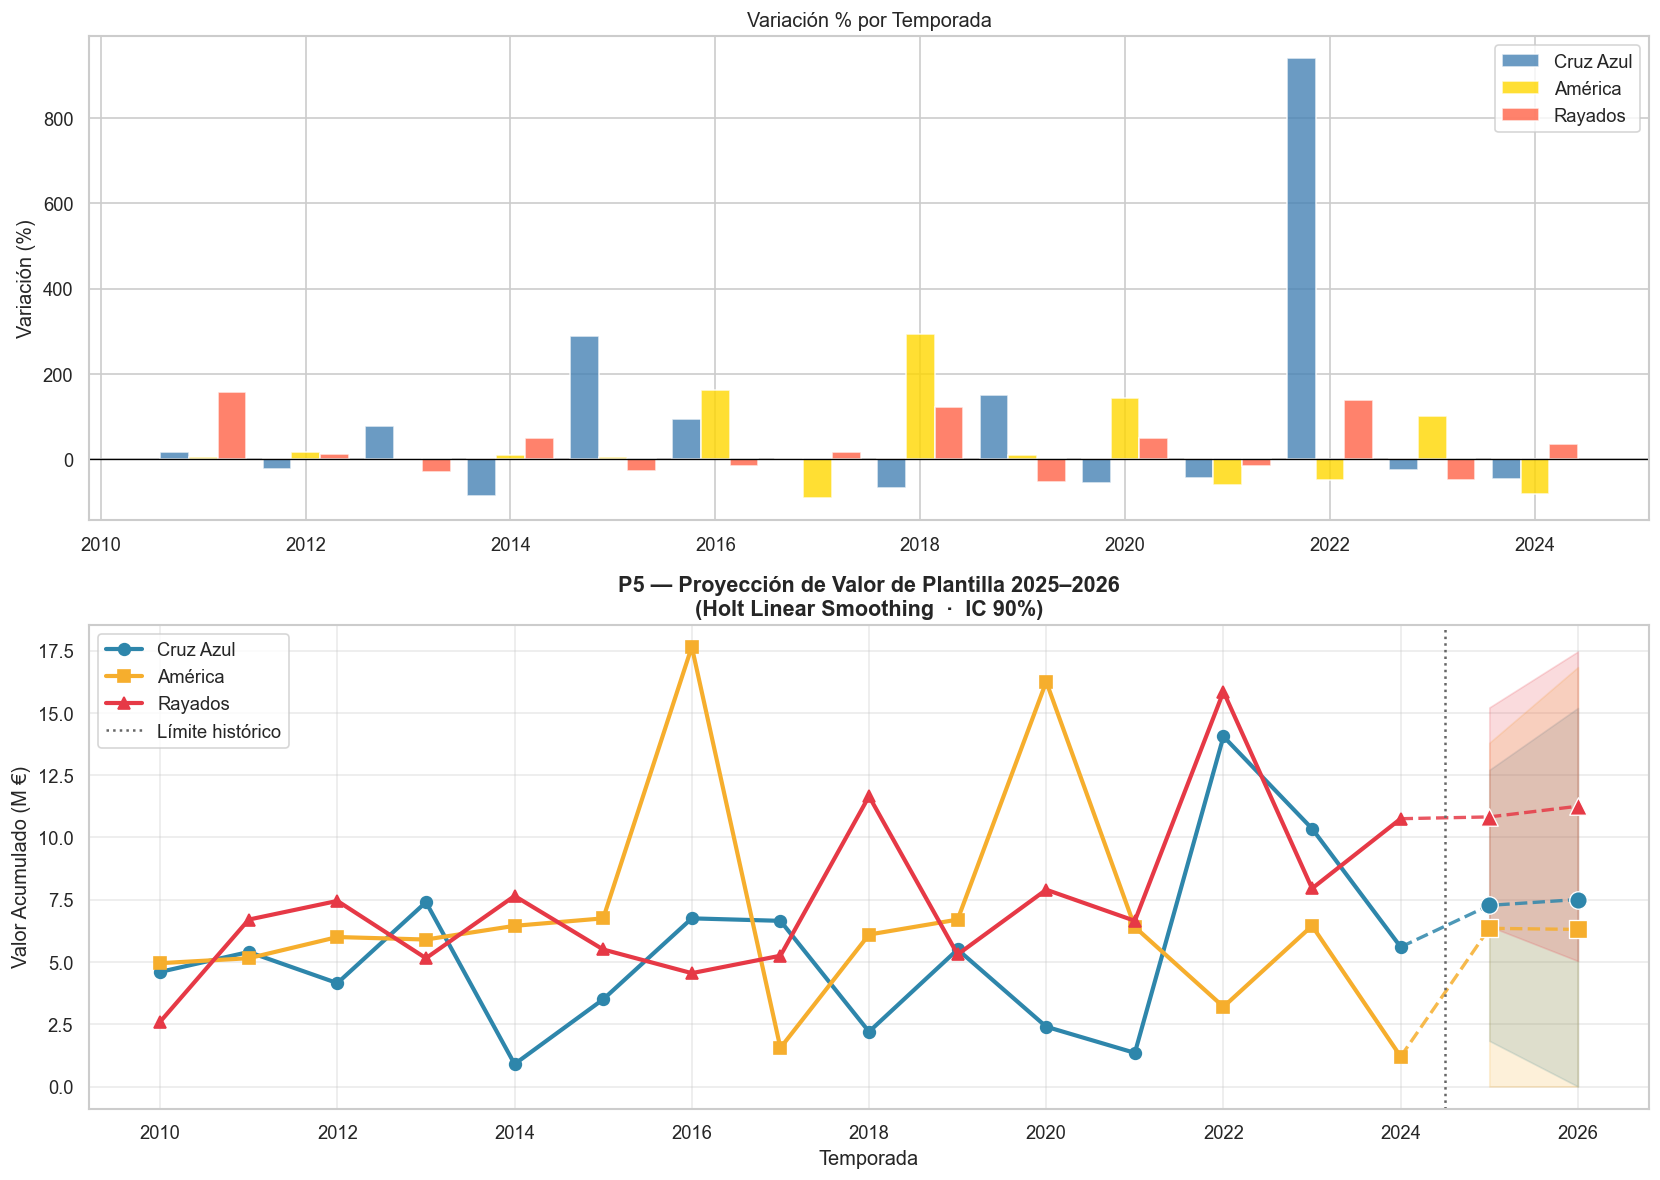


=== VALOR TOTAL DE PLANTILLA POR TEMPORADA (M EUR) ===


,Cruz Azul,América,Rayados
season_year,,,
2010,4.6,5.0,2.6
2011,5.4,5.2,6.7
2012,4.2,6.0,7.4
2013,7.4,5.9,5.2
2014,0.9,6.4,7.6
2015,3.5,6.8,5.5
2016,6.8,17.6,4.6
2017,6.6,1.6,5.2
2018,2.2,6.1,11.6



=== VARIACIÓN PORCENTUAL ===


,Cruz Azul,América,Rayados
season_year,,,
2011,17.4,4.0,157.7
2012,-23.1,16.5,11.2
2013,78.3,-1.7,-30.9
2014,-87.8,9.3,48.5
2015,288.9,4.7,-28.1
2016,92.9,161.5,-17.3
2017,-1.5,-91.2,15.4
2018,-66.9,293.5,121.9
2019,150.0,9.8,-54.5



=== PROYECCIÓN (Holt Linear Smoothing) — VALOR DE PLANTILLA (M EUR) ===


,Cruz Azul,América,Rayados,Nota
2010,4.6,5.0,2.6,
2011,5.4,5.2,6.7,
2012,4.2,6.0,7.4,
2013,7.4,5.9,5.2,
2014,0.9,6.4,7.6,
2015,3.5,6.8,5.5,
2016,6.8,17.6,4.6,
2017,6.6,1.6,5.2,
2018,2.2,6.1,11.6,
2019,5.5,6.7,5.3,


In [51]:
df_hist = df[df['valor_mercado_eur'].notna() & (df['valor_mercado_eur'] > 0)].copy()

def valor_por_temp(mask):
    return df_hist[mask].groupby('season_year')['valor_mercado_eur'].sum() / 1e6

val_ca = valor_por_temp(es_ca(df_hist['equipo_norm']))
val_am = valor_por_temp(es_am(df_hist['equipo_norm']))
val_ray = valor_por_temp(es_ray(df_hist['equipo_norm']))

# Proyección 2 temporadas (2025–2026)
HORIZONTE = 2
      
def proyectar(serie, horizonte=HORIZONTE):
    serie = serie.sort_index().dropna()
    last_yr = int(serie.index[-1])
    fut_idx = np.arange(last_yr + 1, last_yr + horizonte + 1)

    if _backend == 'holt':
        model = HoltETS(
            serie, trend='add', seasonal=None,
            initialization_method='estimated'
        ).fit(optimized=True)
        fc = model.forecast(horizonte)
        fc.index = fut_idx
        sigma = model.resid.std()
    else:
        X = serie.index.values.reshape(-1, 1).astype(float)
        pipe = make_pipeline(PolynomialFeatures(2), LinearRegression())
        pipe.fit(X, serie.values)
        fc_vals = pipe.predict(fut_idx.reshape(-1, 1).astype(float))
        fc = pd.Series(fc_vals, index=fut_idx)
        sigma = (serie.values - pipe.predict(X)).std()

    # banda que crece con sqrt(horizonte)
    z90 = 1.645
    steps = np.arange(1, horizonte + 1)
    lower = (fc - z90 * sigma * np.sqrt(steps)).clip(lower=0)
    upper = fc + z90 * sigma * np.sqrt(steps)
    return fc, lower, upper

fc_ca, lo_ca, hi_ca = proyectar(val_ca)
fc_am, lo_am, hi_am = proyectar(val_am)
fc_ray, lo_ray, hi_ray = proyectar(val_ray)

fig, (ax, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# calculamos las variaciones porcentuales (rendimientos)
pct_ca = val_ca.pct_change() * 100
pct_am = val_am.pct_change() * 100
pct_ray = val_ray.pct_change() * 100

w = 0.28
ax.bar(pct_ca.dropna().index - w, pct_ca.dropna().values, w, label='Cruz Azul', color='steelblue', alpha=0.8)
ax.bar(pct_am.dropna().index, pct_am.dropna().values, w, label='América', color='gold', alpha=0.8)
ax.bar(pct_ray.dropna().index + w, pct_ray.dropna().values, w, label='Rayados', color='tomato', alpha=0.8)
ax.axhline(0, color='black', lw=0.8)
ax.set_title('Variación % por Temporada', fontsize=12)
ax.set_ylabel('Variación (%)')
ax.legend()

series_cfg = [
    (val_ca, fc_ca, lo_ca, hi_ca, '#2E86AB', 'Cruz Azul', 'o'),
    (val_am, fc_am, lo_am, hi_am, '#F6AE2D', 'América', 's'),
    (val_ray, fc_ray, lo_ray, hi_ray, '#E63946', 'Rayados', '^'),
]

for hist, fc, lo, hi, color, label, marker in series_cfg:
    ax2.plot(hist.index, hist.values, color=color, lw=2.5,
            marker=marker, ms=7, label=label)
    # línea punteada de proyección anclada al último punto histórico
    bridge_x = [hist.index[-1]] + fc.index.tolist()
    bridge_y = [hist.values[-1]] + fc.values.tolist()
    ax2.plot(bridge_x, bridge_y, '--', color=color, lw=2, alpha=0.85)
    ax2.scatter(fc.index, fc.values, color=color, marker=marker, s=110, zorder=5, edgecolors='white', linewidths=0.8)
    ax2.fill_between(fc.index, lo.values, hi.values, color=color, alpha=0.18)

ax2.axvline(2024.5, color='#666', ls=':', lw=1.5, label='Límite histórico')
modelo_str = 'Holt Linear Smoothing' if _backend == 'holt' else 'Regresión Polinómica'
ax2.set_title(
    f'P5 — Proyección de Valor de Plantilla 2025–2026\n'
    f'({modelo_str}  ·  IC 90%)',
    fontsize=13, fontweight='bold'
)
ax2.set_xlabel('Temporada')
ax2.set_ylabel('Valor Acumulado (M €)')
ax2.legend()
ax2.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

print('\n=== VALOR TOTAL DE PLANTILLA POR TEMPORADA (M EUR) ===')
resumen = pd.DataFrame({'Cruz Azul': val_ca, 'América': val_am, 'Rayados': val_ray})
display(resumen.round(1))

print('\n=== VARIACIÓN PORCENTUAL ===')
resumen_pct = pd.DataFrame({'Cruz Azul': pct_ca, 'América': pct_am, 'Rayados': pct_ray})
display(resumen_pct.round(1).dropna())

print(f'\n=== PROYECCIÓN ({modelo_str}) — VALOR DE PLANTILLA (M EUR) ===')
tabla_fc = pd.DataFrame({
    'Cruz Azul': pd.concat([val_ca,  fc_ca]),
    'América':   pd.concat([val_am,  fc_am]),
    'Rayados':   pd.concat([val_ray, fc_ray]),
})
tabla_fc.index = tabla_fc.index.astype(int)
tabla_fc.sort_index(inplace=True)
tabla_fc['Nota'] = ['<- proyección' if y >= 2025 else '' for y in tabla_fc.index]
display(tabla_fc.round(1))



---
## P6 — ¿Qué jugadores de Liga MX tienen mayor probabilidad de ser transferidos en el próximo mercado de pases?
> *Método*: Usamos un modelo **XGBoost** con `scale_pos_weight` para compensar el desbalance de clases. Tratamos el problema con features base (edad, overall, goles…) + **features delta YoY** como variación de valor de mercado, variación de Overall y años consecutivos en el mismo equipo.

Features usadas: ['edad', 'fifa_overall', 'log_valor', 'goles', 'asistencias', 'partidos', 'g_a_por_90', 'delta_valor', 'delta_overall', 'anios_equipo']
Registros tras calcular deltas : 269
No transferido: 217 | Transferido: 52

AUC-ROC en test: 0.4755


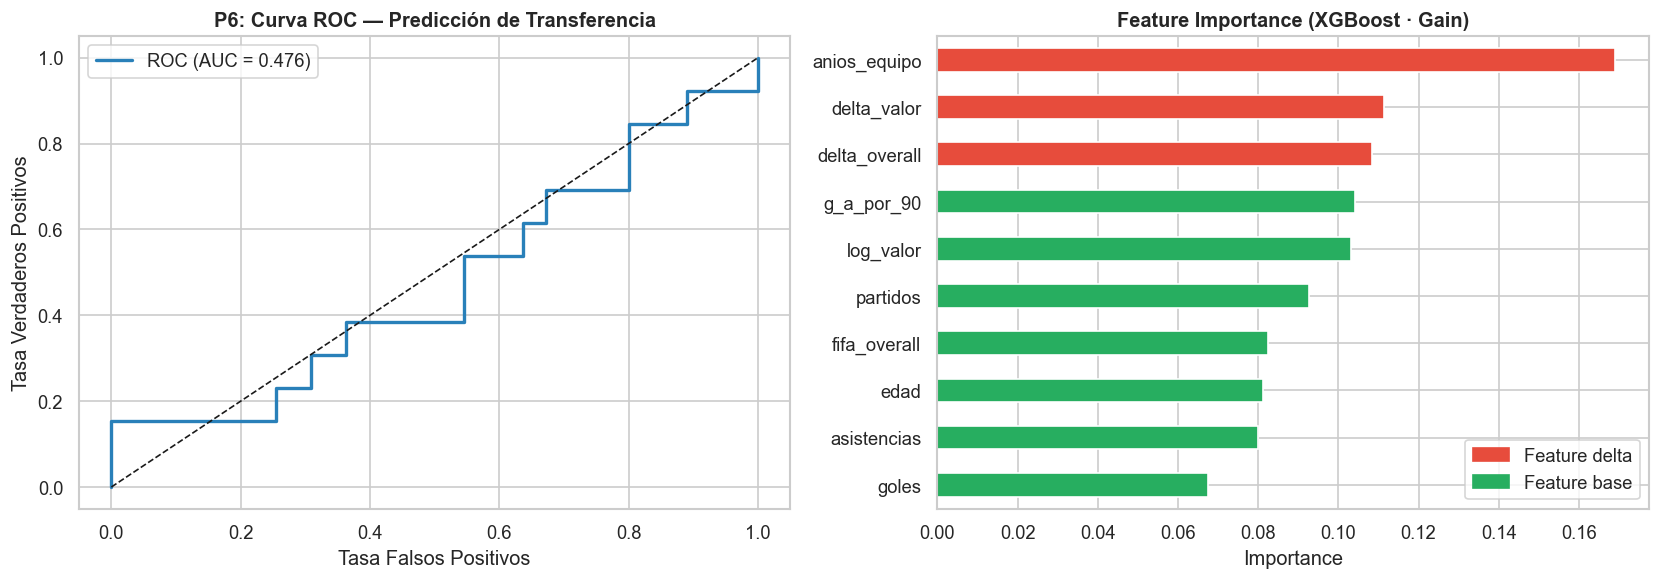


=== TOP 15 JUGADORES CON MAYOR PROBABILIDAD DE TRANSFERENCIA ===


,nombre_canonico,equipo_norm,posicion,prob_transfer
583,Jorge Rodríguez,BRAVOS JUAREZ,CB,0.966
1116,Yoshimar Torres,MAZATLAN FC,CAM,0.690
453,André Martínez,MAZATLAN FC,RB,0.674
484,Hirving Rodríguez,MAZATLAN FC,RM,0.632
237,Jonathan Juárez,LEON,CM,0.614
178,Luis Vázquez,MAZATLAN FC,RB,0.571
403,Lucas Villanueva,CHIVAS GUADALAJARA,RW,0.510
769,Franco Estrada,UNAM PUMAS,CB,0.503
556,Felipe Cáceres,ATLAS,ST,0.503
488,Santiago Vázquez,NECAXA,LM,0.453



=== JUGADORES CRUZ AZUL — RANKING DE RIESGO ===


,nombre_canonico,posicion,prob_transfer
725,Santiago Mayorga,CAM,0.197
393,Diego García,CDM,0.140
552,Michael Flores,CDM,0.128
836,Yoshimar Rivas,CDM,0.088
762,Sebastián Antuna,ST,0.086
1091,Gabriel Gómez,LM,0.059
1127,Jesús López,GK,0.050
34,Ezequiel Rodríguez,ST,0.049
531,Jesús Martínez,CDM,0.031
1013,Eduardo Hernández,ST,0.017


In [52]:


# ─Creacion de features de variación y "Fidelidad"
cols_p6 = ['nombre_key', 'season_year', 'equipo_norm', 'edad', 'fifa_overall', 'valor_mercado_eur', 'goles', 'asistencias', 'partidos', 'g_a_por_90', 'posicion', 'nombre_canonico']
df_p6 = df[[c for c in cols_p6 if c in df.columns]].copy()
df_p6 = df_p6.sort_values(['nombre_key', 'season_year'])

# Target (Transferido/No transferido)
df_p6['equipo_next'] = df_p6.groupby('nombre_key')['equipo_norm'].shift(-1)
df_p6['transferido'] = (df_p6['equipo_next'].notna() & (df_p6['equipo_norm'] != df_p6['equipo_next'])).astype(int)

# Deltas YoY: capturan la trayectoria del jugador, no solo su estado actual
df_p6['delta_valor'] = df_p6.groupby('nombre_key')['valor_mercado_eur'].diff()
df_p6['delta_overall'] = df_p6.groupby('nombre_key')['fifa_overall'].diff()
df_p6['anios_equipo'] = df_p6.groupby(['nombre_key', 'equipo_norm']).cumcount() + 1
df_p6['log_valor'] = np.log1p(df_p6['valor_mercado_eur'])  # corrige asimetría

base_feats = ['edad', 'fifa_overall', 'log_valor', 'goles', 'asistencias', 'partidos', 'g_a_por_90']
delta_feats = ['delta_valor', 'delta_overall', 'anios_equipo']
features = [f for f in base_feats + delta_feats if f in df_p6.columns]

ml_df = df_p6[features + ['transferido', 'nombre_canonico', 'equipo_norm', 'posicion']].dropna(subset=features + ['transferido'])

X = ml_df[features].values
y = ml_df['transferido'].values

print('Features usadas:', features)
print(f'Registros tras calcular deltas : {len(ml_df)}')
print(f'No transferido: {(y==0).sum()} | Transferido: {(y==1).sum()}')

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

scale_pw = (y_tr == 0).sum() / (y_tr == 1).sum()  # compensa desbalance de clases
xgb6 = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=scale_pw,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='auc',
    verbosity=0
)
xgb6.fit(X_tr, y_tr)
y_prob = xgb6.predict_proba(X_te)[:, 1]
auc = roc_auc_score(y_te, y_prob)
print(f'\nAUC-ROC en test: {round(auc, 4)}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

fpr, tpr, _ = roc_curve(y_te, y_prob)
ax1.plot(fpr, tpr, color='#2980B9', lw=2, label=f'ROC (AUC = {round(auc, 3)})')
ax1.plot([0, 1], [0, 1], 'k--', lw=1)
ax1.set_xlabel('Tasa Falsos Positivos')
ax1.set_ylabel('Tasa Verdaderos Positivos')
ax1.set_title('P6: Curva ROC — Predicción de Transferencia', fontweight='bold')
ax1.legend()

# Feature importance coloreada: rojo = delta (nuevas), verde = base
imp = pd.Series(xgb6.feature_importances_, index=features).sort_values(ascending=True)
bar_colors = ['#E74C3C' if f in delta_feats else '#27AE60' for f in imp.index]
imp.plot(kind='barh', ax=ax2, color=bar_colors)
ax2.legend(handles=[
    Patch(color='#E74C3C', label='Feature delta'),
    Patch(color='#27AE60', label='Feature base')
], loc='lower right')
ax2.set_title('Feature Importance (XGBoost · Gain)', fontweight='bold')
ax2.set_xlabel('Importance')

plt.tight_layout()
plt.show()

ml_df2 = df_p6[features + ['nombre_canonico', 'equipo_norm', 'posicion']].dropna(subset=features).copy()
ml_df2['prob_transfer'] = xgb6.predict_proba(ml_df2[features].values)[:, 1]

last_idx = df_p6.sort_values('season_year').groupby('nombre_key').tail(1).index
candidates = ml_df2.loc[ml_df2.index.isin(last_idx)].sort_values('prob_transfer', ascending=False)

print('\n=== TOP 15 JUGADORES CON MAYOR PROBABILIDAD DE TRANSFERENCIA ===')
display(candidates[['nombre_canonico', 'equipo_norm', 'posicion', 'prob_transfer']].head(15).round(3))

print('\n=== JUGADORES CRUZ AZUL — RANKING DE RIESGO ===')
ca_risk = candidates[es_ca(candidates['equipo_norm'])]
display(ca_risk[['nombre_canonico', 'posicion', 'prob_transfer']].head(10).round(3))

---
## P7 — ¿Cuál es el valor de mercado esperado dado el rendimiento real y atributos FIFA?
> **Método:** Calculado a través de XGBRegressor, tomando como target log(valor_mercado_eur). Features usadas: overall, potential, edad, posición codificada, goles, asistencias, minutos. 

RMSE (log-escala): 0.2721
R²: 0.6948


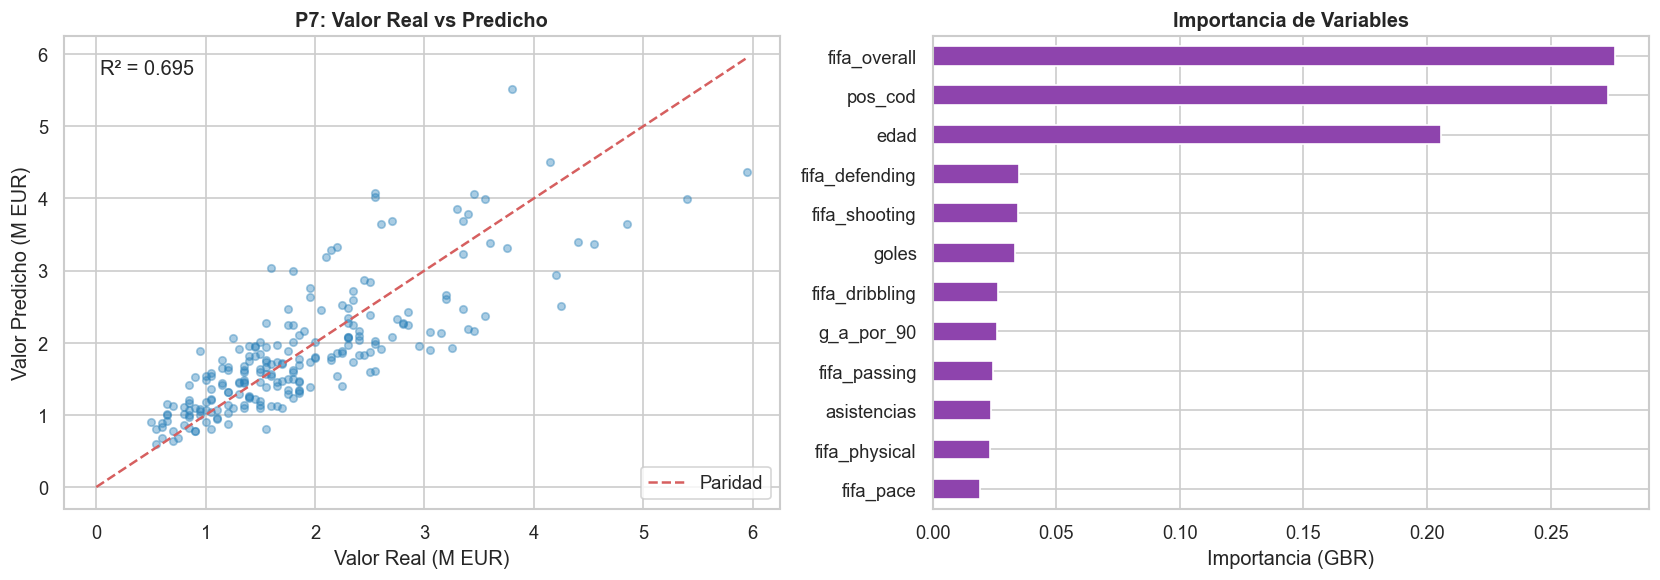


=== CRUZ AZUL: VALOR REAL vs ESPERADO POR EL MODELO ===


,Jugador,Pos,Overall,Valor Real M,Valor Esperado M,Diferencia M
603,Felipe Rivas,RM,66,1.00,1.54,0.54
1070,Matías García,LB,79,1.80,2.25,0.45
1084,Jonathan Mora,CM,74,1.20,1.62,0.42
569,Luis Moreno,LB,68,0.60,0.89,0.29
588,Pablo Torres,RB,71,0.70,0.98,0.28
905,Pablo Mayorga,CM,82,1.40,1.66,0.26
1045,Hirving Romo,RM,66,1.35,1.59,0.24
1088,Dario Carneiro,CDM,73,1.10,1.33,0.23
201,Erick Hernández,LB,65,1.05,1.28,0.23
462,Víctor Salcedo,CDM,66,0.65,0.86,0.21


In [53]:
feats7 = ['fifa_overall', 'edad', 'goles', 'asistencias', 'minutos', 'g_a_por_90', 'fifa_pace', 'fifa_shooting', 'fifa_passing', 'fifa_dribbling', 'fifa_defending', 'fifa_physical']
feats7_present = [f for f in feats7 if f in df.columns]

df_p7 = df[feats7_present + ['valor_mercado_eur', 'posicion', 'nombre_canonico', 'equipo_norm']].copy()
df_p7 = df_p7[df_p7['valor_mercado_eur'].notna() & (df_p7['valor_mercado_eur'] > 0)].copy()

# Codificar posición
le = LabelEncoder()
df_p7['pos_cod'] = le.fit_transform(df_p7['posicion'].fillna('Unknown'))
features7 = feats7_present + ['pos_cod']

df_p7 = df_p7.dropna(subset=feats7_present)
df_p7['log_vm'] = np.log1p(df_p7['valor_mercado_eur'])

X7 = df_p7[features7].values
y7 = df_p7['log_vm'].values

X7_tr, X7_te, y7_tr, y7_te, idx7_tr, idx7_te = train_test_split(X7, y7, df_p7.index, test_size=0.2, random_state=42)

gbr = XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.05, random_state=42)
gbr.fit(X7_tr, y7_tr)
y7_pred = gbr.predict(X7_te)

rmse = np.sqrt(mean_squared_error(y7_te, y7_pred))
r2 = r2_score(y7_te, y7_pred)
print('RMSE (log-escala):', round(rmse, 4))
print('R²:', round(r2, 4))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Scatter predicho vs real 
y7_real_m = np.expm1(y7_te) / 1e6
y7_pred_m = np.expm1(y7_pred) / 1e6
ax1.scatter(y7_real_m, y7_pred_m, alpha=0.4, s=20, color='#2980B9')
lim = max(y7_real_m.max(), y7_pred_m.max())
ax1.plot([0, lim], [0, lim], 'r--', lw=1.5, label='Paridad')
ax1.set_xlabel('Valor Real (M EUR)')
ax1.set_ylabel('Valor Predicho (M EUR)')
ax1.set_title('P7: Valor Real vs Predicho', fontweight='bold')
ax1.legend()
ax1.text(0.05, 0.92, 'R² = ' + str(round(r2, 3)), transform=ax1.transAxes)

imp7 = pd.Series(gbr.feature_importances_, index=features7).sort_values(ascending=True)
imp7.plot(kind='barh', ax=ax2, color='#8E44AD')
ax2.set_title('Importancia de Variables', fontweight='bold')
ax2.set_xlabel('Importancia (GBR)')

plt.tight_layout()
plt.show()

# Jugadores Cruz Azul: valor real vs esperado
ca_p7 = df_p7[es_ca(df_p7['equipo_norm'])].copy()
ca_p7['vm_esperado'] = np.expm1(gbr.predict(ca_p7[features7].values))
ca_p7['diferencia_m'] = (ca_p7['vm_esperado'] - ca_p7['valor_mercado_eur']) / 1e6
ca_p7['vm_real_m']    = ca_p7['valor_mercado_eur'] / 1e6
ca_p7['vm_esperado_m'] = ca_p7['vm_esperado'] / 1e6

print('\n=== CRUZ AZUL: VALOR REAL vs ESPERADO POR EL MODELO ===')
disp7 = ca_p7[['nombre_canonico', 'posicion', 'fifa_overall', 'vm_real_m', 'vm_esperado_m', 'diferencia_m']].sort_values('diferencia_m', ascending=False)
disp7.columns = ['Jugador', 'Pos', 'Overall', 'Valor Real M', 'Valor Esperado M', 'Diferencia M']
display(disp7.round(2))

---
## P8 — ¿Qué resultado puede esperarse en un partido de Cruz Azul?
> **Método:** **XGBoost binario** (`binary:logistic`). Target: **Victoria local (1) vs No victoria — empate o derrota — (0)**. Features: diferencial de Overall promedio entre plantillas, diferencial de forma reciente (pts), y diferencial de **forma goleadora** (goles a favor y en contra en últimos 5 partidos).
> **Evaluación:** AUC-ROC + Feature Importance (Gain).


Victoria local : 1453 (42.4%)
No victoria : 1971 (57.6%)

AUC-ROC en test: 0.5493
              precision    recall  f1-score   support

 No Victoria       0.60      0.58      0.59       493
    Victoria       0.45      0.48      0.47       363

    accuracy                           0.54       856
   macro avg       0.53      0.53      0.53       856
weighted avg       0.54      0.54      0.54       856



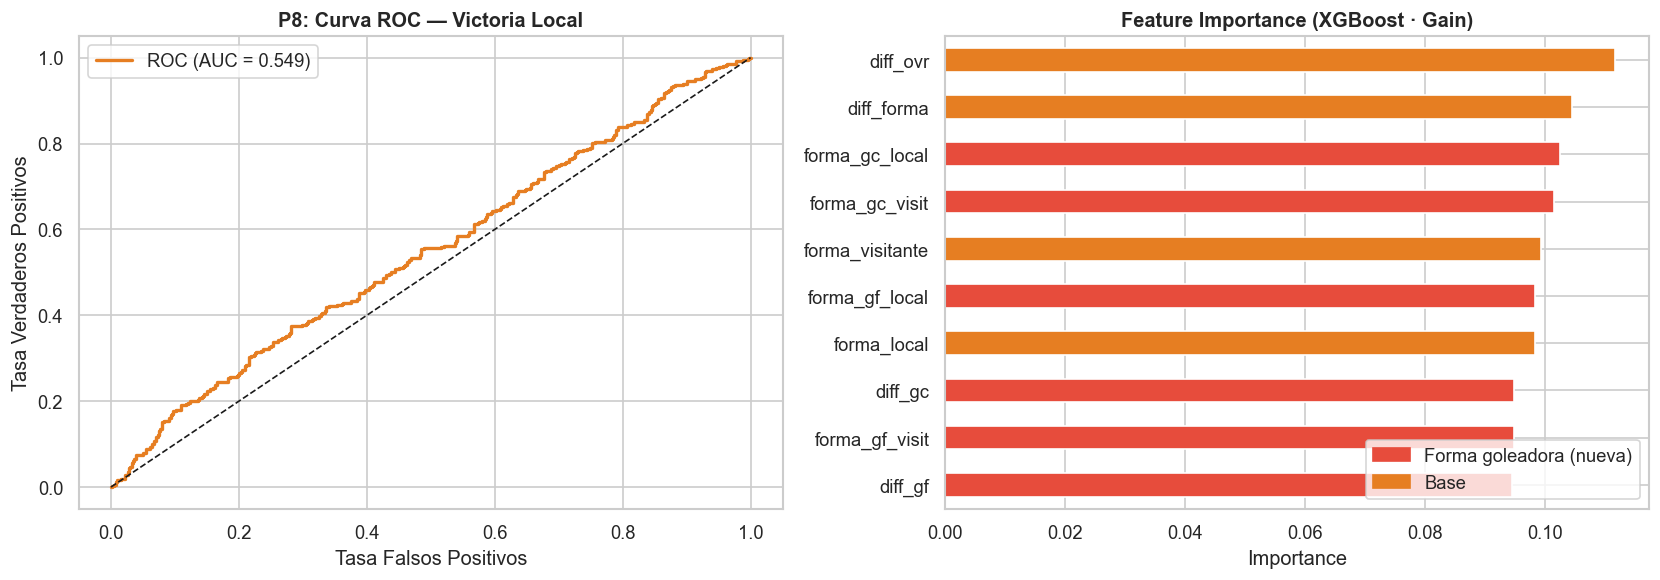


=== ÚLTIMO PARTIDO DE CRUZ AZUL ===
Victoria    : 74.6 %
No victoria : 25.4 %


In [54]:
# Fuerza de plantilla por equipo y temporada 
squad_str = (df[df['fifa_overall'].notna()].groupby(['equipo_norm', 'season_year'])['fifa_overall'].mean().reset_index().rename(columns={'fifa_overall': 'squad_overall'}))

pt = partidos.copy()
pt['season_year'] = pt['season_year'].astype('Int64')
pt = pt.merge(squad_str.rename(columns={'equipo_norm': 'equipo_local_norm', 'squad_overall': 'ovr_local'}), on=['equipo_local_norm', 'season_year'], how='left')
pt = pt.merge(squad_str.rename(columns={'equipo_norm': 'equipo_visitante_norm', 'squad_overall': 'ovr_visit'}), on=['equipo_visitante_norm', 'season_year'], how='left')
pt['diff_ovr'] = pt['ovr_local'] - pt['ovr_visit']

pt_sorted = pt.sort_values('date').reset_index(drop=True)
pt_sorted['pts_local'] = pt_sorted['resultado_local'].map({'W': 3, 'D': 1, 'L': 0})
pt_sorted['pts_visitante'] = pt_sorted['resultado_local'].map({'W': 0, 'D': 1, 'L': 3})
 
# Registro largo: una fila por equipo por partido
home_rec = pt_sorted[['date', 'match_id', 'equipo_local_norm', 'pts_local', 'goles_local', 'goles_visitante']].rename(
    columns={'equipo_local_norm': 'equipo', 'pts_local': 'pts', 'goles_local': 'gf', 'goles_visitante': 'gc'})
away_rec = pt_sorted[['date', 'match_id', 'equipo_visitante_norm', 'pts_visitante', 'goles_visitante', 'goles_local']].rename(
    columns={'equipo_visitante_norm': 'equipo', 'pts_visitante': 'pts', 'goles_visitante': 'gf', 'goles_local': 'gc'})
hist = pd.concat([home_rec, away_rec]).sort_values(['equipo', 'date']).reset_index(drop=True)

# Si el partido actual no entra en su propia forma, evita filtración
for col in ['pts', 'gf', 'gc']:
    hist[f'forma_{col}'] = (hist.groupby('equipo')[col].transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean()))

forma = hist[['match_id', 'equipo', 'forma_pts', 'forma_gf', 'forma_gc']]

pt_sorted = pt_sorted.merge(forma.rename(columns={'equipo': 'equipo_local_norm', 'forma_pts': 'forma_local', 'forma_gf': 'forma_gf_local', 'forma_gc': 'forma_gc_local'}),
    on=['match_id', 'equipo_local_norm'], how='left')
pt_sorted = pt_sorted.merge(forma.rename(columns={'equipo': 'equipo_visitante_norm', 'forma_pts': 'forma_visitante', 'forma_gf': 'forma_gf_visit', 'forma_gc': 'forma_gc_visit'}),
    on=['match_id', 'equipo_visitante_norm'], how='left')

pt_sorted['diff_forma'] = pt_sorted['forma_local'] - pt_sorted['forma_visitante']
pt_sorted['diff_gf'] = pt_sorted['forma_gf_local'] - pt_sorted['forma_gf_visit']
pt_sorted['diff_gc'] = pt_sorted['forma_gc_local'] - pt_sorted['forma_gc_visit']

# Target binario: Victoria local (1) vs No victoria (0)
pt_sorted['gano_local'] = (pt_sorted['resultado_local'] == 'W').astype(int)

feats8 = ['diff_ovr', 'diff_forma', 'diff_gf', 'diff_gc', 'forma_local', 'forma_visitante', 'forma_gf_local', 'forma_gc_local', 'forma_gf_visit', 'forma_gc_visit']
feats8 = [f for f in feats8 if f in pt_sorted.columns]

df_ml8 = pt_sorted[feats8 + ['gano_local']].dropna()
X8 = df_ml8[feats8].values
y8 = df_ml8['gano_local'].values

print(f'Victoria local : {y8.sum()} ({y8.mean()*100:.1f}%)')
print(f'No victoria : {(1-y8).sum()} ({(1-y8).mean()*100:.1f}%)')

X8_tr, X8_te, y8_tr, y8_te = train_test_split(X8, y8, test_size=0.25, random_state=42, stratify=y8)

# Modelo: XGBoost binario
scale_pw8 = (y8_tr == 0).sum() / (y8_tr == 1).sum()
xgb_p8 = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    objective='binary:logistic',
    scale_pos_weight=scale_pw8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='auc',
    verbosity=0
)
xgb_p8.fit(X8_tr, y8_tr)
y8_pred = xgb_p8.predict(X8_te)
y8_prob = xgb_p8.predict_proba(X8_te)[:, 1]

auc8 = roc_auc_score(y8_te, y8_prob)
print(f'\nAUC-ROC en test: {round(auc8, 4)}')
print(classification_report(y8_te, y8_pred, target_names=['No Victoria', 'Victoria']))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

fpr8, tpr8, _ = roc_curve(y8_te, y8_prob)
ax1.plot(fpr8, tpr8, color='#E67E22', lw=2, label=f'ROC (AUC = {round(auc8, 3)})')
ax1.plot([0, 1], [0, 1], 'k--', lw=1)
ax1.set_xlabel('Tasa Falsos Positivos')
ax1.set_ylabel('Tasa Verdaderos Positivos')
ax1.set_title('P8: Curva ROC — Victoria Local', fontweight='bold')
ax1.legend()

goal_feats = ['diff_gf', 'diff_gc', 'forma_gf_local', 'forma_gc_local', 'forma_gf_visit', 'forma_gc_visit']
imp8 = pd.Series(xgb_p8.feature_importances_, index=feats8).sort_values(ascending=True)
bar_colors8 = ['#E74C3C' if f in goal_feats else '#E67E22' for f in imp8.index]
imp8.plot(kind='barh', ax=ax2, color=bar_colors8)
ax2.legend(handles=[
    Patch(color='#E74C3C', label='Forma goleadora (nueva)'),
    Patch(color='#E67E22', label='Base')
], loc='lower right')
ax2.set_title('Feature Importance (XGBoost · Gain)', fontweight='bold')
ax2.set_xlabel('Importance')

plt.tight_layout()
plt.show()

# Predicción del último partido disponible de Cruz Azul
ca_p8 = pt_sorted[es_ca(pt_sorted['equipo_local_norm']) |
                  es_ca(pt_sorted['equipo_visitante_norm'])].copy()
if len(ca_p8) > 0:
    sample = ca_p8[feats8].dropna().iloc[-1:]
    prob_win = xgb_p8.predict_proba(sample.values)[0][1]
    print(f'\n=== ÚLTIMO PARTIDO DE CRUZ AZUL ===')
    print(f'Victoria    : {prob_win*100:.1f} %')
    print(f'No victoria : {(1-prob_win)*100:.1f} %')


---
## P9 — ¿Qué mediocampista disponible en Liga MX maximiza rendimiento/costo ≤ 3 M USD?
> **Método:** Filtramos mediocampistas con valor ≤ 3 M USD. Con base a eso, generamos un índice compuesto ponderado: 40 % Overall + 30 % G+A/90 + 20 % Relación valor/rendimiento + 10 % Juventud.  

Mediocampistas disponibles (excl. Cruz Azul, VM <= 3M USD): 262

=== TOP 5 MEDIOCAMPISTAS RECOMENDADOS PARA CRUZ AZUL ===


,Jugador,Equipo,Pos,Edad,Overall,G+A/90,Valor (M EUR),Índice
188,Sebastián Villanueva,CHIVAS GUADALAJARA,CM,35,82,2.762,1.90,0.753
566,Jesús Torres,SANTOS LAGUNA,CDM,18,84,0.239,1.50,0.637
937,Leandro Lotti,BRAVOS JUAREZ,CAM,36,83,0.828,1.45,0.598
510,Jonathan Álvarez,BRAVOS JUAREZ,CM,17,83,0.408,2.15,0.582
166,Diego Torres,ATLAS,CM,31,79,1.636,2.05,0.582


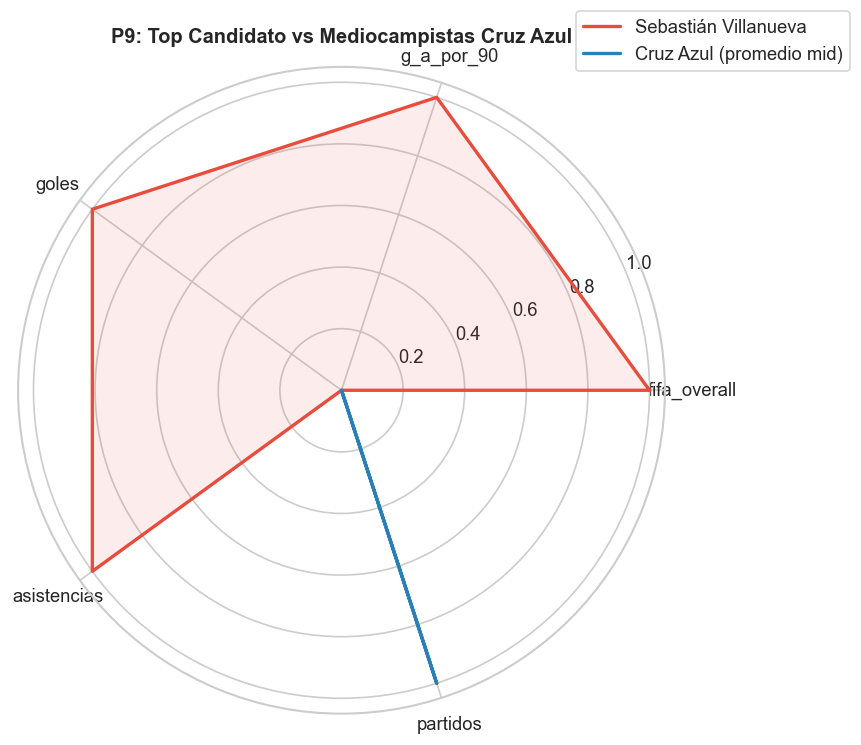

In [55]:

BUDGET_USD = 3_000_000
EUR_USD    = 1.08
BUDGET_EUR = BUDGET_USD / EUR_USD

# Posiciones de mediocampo
mid_kw = ['CM', 'CDM', 'CAM', 'MC', 'MCD', 'MCC', 'MCO', 'MI', 'MD', 'Centrocampista', 'Mediocamp', 'MF', 'DM', 'AM']
mid_pattern = '|'.join(mid_kw)

mids = df[
    df['posicion'].str.contains(mid_pattern, case=False, na=False) &
    df['valor_mercado_eur'].notna() &
    (df['valor_mercado_eur'] > 0) &
    (df['valor_mercado_eur'] <= BUDGET_EUR) &
    ~es_ca(df['equipo_norm'])
].copy()

print('Mediocampistas disponibles (excl. Cruz Azul, VM <= 3M USD):', len(mids))

if len(mids) == 0:
    print('Sin coincidencias exactas — ampliando presupuesto x2')
    mids = df[
        df['posicion'].str.contains(mid_pattern, case=False, na=False) &
        df['valor_mercado_eur'].notna() &
        (df['valor_mercado_eur'] > 0) &
        (df['valor_mercado_eur'] <= BUDGET_EUR * 2) &
        ~es_ca(df['equipo_norm'])
    ].copy()

# Índice compuesto
mids_clean = mids.dropna(subset=['fifa_overall', 'g_a_por_90']).copy()
sc = MinMaxScaler()

mids_clean['ov_n'] = sc.fit_transform(mids_clean[['fifa_overall']])
mids_clean['ga_n'] = sc.fit_transform(mids_clean[['g_a_por_90']].fillna(0))
vm_n_vals = 1 - sc.fit_transform(mids_clean[['valor_mercado_eur']])
mids_clean['vm_n'] = vm_n_vals
mids_clean['edad_n'] = 1 - sc.fit_transform(mids_clean[['edad']].fillna(30))

mids_clean['indice'] = (0.40 * mids_clean['ov_n'] +
                        0.30 * mids_clean['ga_n'] +
                        0.20 * mids_clean['vm_n'] +
                        0.10 * mids_clean['edad_n'])

top5 = mids_clean.nlargest(5, 'indice')[['nombre_canonico', 'equipo_norm', 'posicion', 'edad', 'fifa_overall', 'g_a_por_90', 'valor_mercado_eur', 'indice']].copy()
top5['valor_mercado_eur'] = top5['valor_mercado_eur'] / 1e6

print('\n=== TOP 5 MEDIOCAMPISTAS RECOMENDADOS PARA CRUZ AZUL ===')
top5_disp = top5.copy()
top5_disp.columns = ['Jugador', 'Equipo', 'Pos', 'Edad', 'Overall', 'G+A/90', 'Valor (M EUR)', 'Índice']
display(top5_disp.round(3))

#  top candidato vs mediocampistas de Cruz Azul
radar_feats = [f for f in ['fifa_overall', 'g_a_por_90', 'goles', 'asistencias', 'partidos'] if f in df.columns]
ca_mids = df[
    es_ca(df['equipo_norm']) &
    df['posicion'].str.contains(mid_pattern, case=False, na=False)
][radar_feats + ['nombre_canonico']].dropna()

if len(top5) > 0 and len(ca_mids) > 0:
    cand_name = top5.iloc[0]['nombre_canonico']
    cand_rows = mids_clean[mids_clean['nombre_canonico'] == cand_name][radar_feats]
    if len(cand_rows) == 0:
        cand_rows = mids_clean[radar_feats].iloc[[0]]
    cand_row = cand_rows.iloc[0]
    ca_mean  = ca_mids[radar_feats].mean()

    sc_r = MinMaxScaler()
    combined = pd.DataFrame([cand_row.values, ca_mean.values], columns=radar_feats)
    combined_n = pd.DataFrame(sc_r.fit_transform(combined), columns=radar_feats)

    angles = np.linspace(0, 2 * np.pi, len(radar_feats), endpoint=False).tolist()
    angles += angles[:1]

    fig, ax_r = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
    for i, (label, color) in enumerate(zip(
            [cand_name, 'Cruz Azul (promedio mid)'], ['#E74C3C', '#2980B9'])):
        vals = combined_n.iloc[i].tolist() + [combined_n.iloc[i].tolist()[0]]
        ax_r.plot(angles, vals, color=color, lw=2, label=label)
        ax_r.fill(angles, vals, color=color, alpha=0.1)
    ax_r.set_xticks(angles[:-1])
    ax_r.set_xticklabels(radar_feats)
    ax_r.set_title('P9: Top Candidato vs Mediocampistas Cruz Azul', fontweight='bold', pad=15)
    ax_r.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.show()

---
## P10 — ¿Qué debilidades tácticas tiene Cruz Azul y qué perfil de jugador necesita?
> **Método:** Analizamos goles concedidos por jornada en partidos de Cruz Azul. Comparamos atributos defensivos FIFA vs los 3 equipos más sólidos de la liga. Identificamos perfil y candidatos.  

Equipos más sólidos defensivamente: ['TOLUCA', 'CLUB LEON', 'LEON']
Goles concedidos promedio por partido:
TOLUCA       1.378
CLUB LEON    1.392
LEON         1.440
Name: gc_total, dtype: float64

Cruz Azul — goles concedidos promedio por partido: 1.603


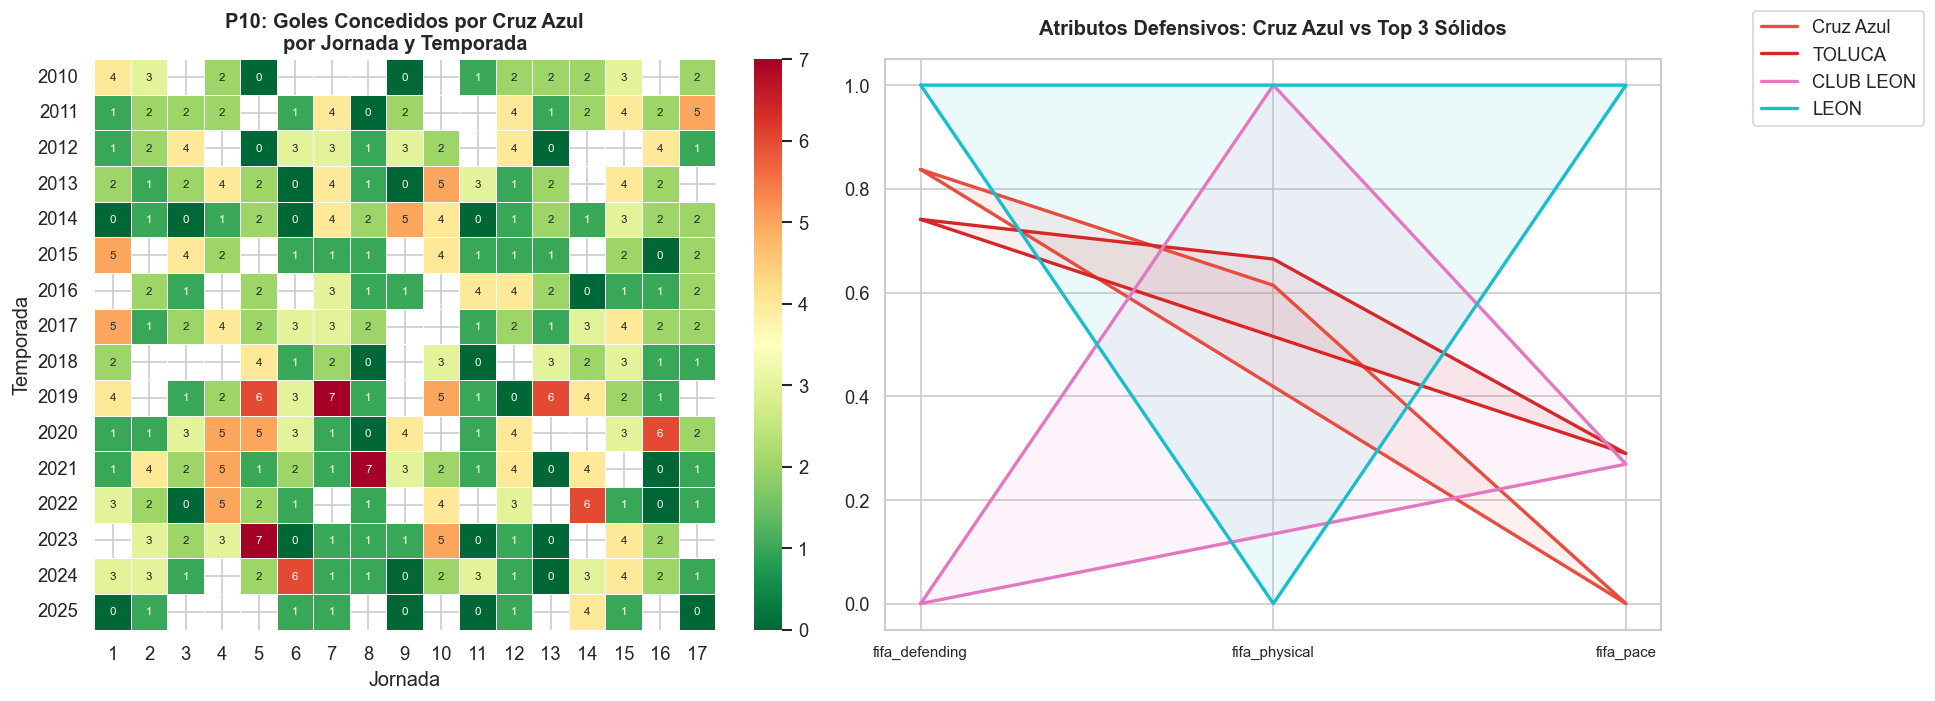


=== PERFIL DEFENSIVO NECESARIO PARA CRUZ AZUL ===
Gap atributos defensivos (Top3 - Cruz Azul):
fifa_defending   -1.1
fifa_physical    -0.2
fifa_pace         3.3

=== TOP 10 CANDIDATOS DEFENSIVOS DISPONIBLES (VM <= 5M EUR) ===


,nombre_canonico,equipo_norm,posicion,edad,defending,overall,Valor M
146,Lucas Suárez,TIJUANA,CB,17,85,71,0.80
160,Fernando Álvarez,CLUB AMERICA,CDM,26,85,82,2.65
440,Héctor Rivas,TIGRES UANL,CDM,28,85,83,4.35
350,Erick Aguirre,ATLETICO SAN LUIS,CDM,18,85,69,1.25
64,Rodrigo Fernández,CHIVAS GUADALAJARA,CB,33,85,82,1.90
480,Santiago Giménez,FC JUAREZ,RB,37,85,73,0.70
564,Jorge Lozano,SANTOS LAGUNA,RB,30,85,70,1.05
529,Marco Moreno,BRAVOS JUAREZ,CDM,21,85,66,0.95
487,Alan Macías,CHIVAS GUADALAJARA,CDM,34,85,84,2.05
711,Ramón Macías,DEPORTIVO TOLUCA,CB,31,85,83,1.85


In [56]:

# Goles concedidos por Cruz Azul por temporada/jornada
ca_local = partidos[es_ca(partidos['equipo_local_norm'])].copy()
ca_visit = partidos[es_ca(partidos['equipo_visitante_norm'])].copy()

ca_local['goles_concedidos'] = ca_local['goles_visitante']
ca_local['goles_favor'] = ca_local['goles_local']
ca_visit['goles_concedidos'] = ca_visit['goles_local']
ca_visit['goles_favor'] = ca_visit['goles_visitante']

ca_all = pd.concat([ca_local[['season_year', 'round', 'goles_concedidos', 'goles_favor']],
                    ca_visit[['season_year', 'round', 'goles_concedidos', 'goles_favor']]])
ca_all = ca_all.dropna(subset=['goles_concedidos', 'season_year', 'round'])
ca_all['season_year'] = ca_all['season_year'].astype(int)
ca_all['round'] = ca_all['round'].astype(int)

# Heatmap de goles concedidos por jornada/temporada
pivot_gc = ca_all.pivot_table(index='season_year', columns='round', values='goles_concedidos', aggfunc='sum')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(pivot_gc, cmap='RdYlGn_r', ax=ax1, linewidths=0.3, annot=True, fmt='.0f', annot_kws={'size': 7})
ax1.set_title('P10: Goles Concedidos por Cruz Azul\npor Jornada y Temporada', fontweight='bold')
ax1.set_xlabel('Jornada')
ax1.set_ylabel('Temporada')

# Cruz Azul vs top 3 defensivos de la liga
def_feats = ['fifa_defending', 'fifa_physical', 'fifa_pace']
def_feats_ok = [f for f in def_feats if f in df.columns]

# Equipos que menos goles conceden (promedio por partido)
gc_eq_local = (partidos.groupby('equipo_local_norm')['goles_visitante'].mean().rename('gc_local'))
gc_eq_visit = (partidos.groupby('equipo_visitante_norm')['goles_local'].mean().rename('gc_visit'))
gc_eq = pd.concat([gc_eq_local, gc_eq_visit], axis=1)
gc_eq['gc_total'] = gc_eq.mean(axis=1)
top3_def = gc_eq.nsmallest(3, 'gc_total').index.tolist()

print('Equipos más sólidos defensivamente:', top3_def)
print('Goles concedidos promedio por partido:')
print(gc_eq.loc[top3_def, 'gc_total'].round(3))

ca_gc = ca_all['goles_concedidos'].mean()
print('\nCruz Azul — goles concedidos promedio por partido:', round(ca_gc, 3))

# Radar defensivo
if len(def_feats_ok) > 0:
    def_df = df[def_feats_ok + ['equipo_norm']].dropna()

    groups_names = ['Cruz Azul'] + [t for t in top3_def]
    groups_masks = [es_ca(def_df['equipo_norm'])] + [
        def_df['equipo_norm'].str.contains(t.split()[0], case=False, na=False)
        for t in top3_def]

    profiles = []
    valid_names = []
    for name, mask in zip(groups_names, groups_masks):
        sub = def_df[mask][def_feats_ok]
        if len(sub) > 0:
            profiles.append(sub.mean().values)
            valid_names.append(name)

    if len(profiles) > 1:
        sc_r2 = MinMaxScaler()
        profiles_n = sc_r2.fit_transform(np.array(profiles))

        angles2 = np.linspace(0, 2 * np.pi, len(def_feats_ok), endpoint=False).tolist()
        angles2 += angles2[:1]
        cmap = plt.cm.get_cmap('tab10', len(valid_names))

        for i, (name, pn) in enumerate(zip(valid_names, profiles_n)):
            vals2 = pn.tolist() + [pn[0]]
            color2 = '#E74C3C' if 'Cruz' in name else cmap(i)
            ax2.plot(angles2, vals2, color=color2, lw=2, label=name)
            ax2.fill(angles2, vals2, color=color2, alpha=0.08)

        ax2.set_xticks(angles2[:-1])
        ax2.set_xticklabels(def_feats_ok, fontsize=9)
        ax2.set_title('Atributos Defensivos: Cruz Azul vs Top 3 Sólidos', fontweight='bold', pad=15)
        ax2.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1))
    else:
        ax2.text(0.5, 0.5, 'Datos insuficientes para radar', ha='center', transform=ax2.transAxes)
else:
    ax2.text(0.5, 0.5, 'Columnas FIFA defensivas no disponibles', ha='center', transform=ax2.transAxes)

plt.tight_layout()
plt.show()

# Perfil del jugador a fichar y candidatos
print('\n=== PERFIL DEFENSIVO NECESARIO PARA CRUZ AZUL ===')
if len(def_feats_ok) > 0:
    ca_def_mean = def_df[es_ca(def_df['equipo_norm'])][def_feats_ok].mean()
    liga_top_mean = def_df[def_df['equipo_norm'].isin(top3_def)][def_feats_ok].mean()
    gap = (liga_top_mean - ca_def_mean).round(1)
    print('Gap atributos defensivos (Top3 - Cruz Azul):')
    print(gap.to_string())

# Candidatos: defensores/mediocampistas defensivos con alto defending
def_pos_kw = ['CB', 'RB', 'LB', 'CDM', 'SW', 'DC', 'DF', 'Defensa', 'Central']
def_pos_pat = '|'.join(def_pos_kw)

candidatos_def = df[
    df['posicion'].str.contains(def_pos_pat, case=False, na=False) &
    ~es_ca(df['equipo_norm']) &
    df['valor_mercado_eur'].notna() &
    (df['valor_mercado_eur'] <= 5_000_000)
].copy()

if 'fifa_defending' in df.columns:
    candidatos_def = candidatos_def.dropna(subset=['fifa_defending'])
    candidatos_def = candidatos_def.sort_values('fifa_defending', ascending=False)
    print('\n=== TOP 10 CANDIDATOS DEFENSIVOS DISPONIBLES (VM <= 5M EUR) ===')
    cols_disp = ['nombre_canonico', 'equipo_norm', 'posicion', 'edad', 'fifa_defending', 'fifa_overall', 'valor_mercado_eur']
    cols_ok = [c for c in cols_disp if c in candidatos_def.columns]
    disp_cand = candidatos_def[cols_ok].head(10).copy()
    disp_cand['valor_mercado_eur'] = disp_cand['valor_mercado_eur'] / 1e6
    disp_cand.columns = [c.replace('fifa_', '').replace('valor_mercado_eur', 'Valor M') for c in disp_cand.columns]
    display(disp_cand.round(2))
else:
    print('Columna fifa_defending no disponible — usando fifa_overall como proxy')
    candidatos_def = candidatos_def.dropna(subset=['fifa_overall'])
    print(candidatos_def[['nombre_canonico', 'equipo_norm', 'posicion', 'fifa_overall', 'valor_mercado_eur']].nlargest(10, 'fifa_overall').round(2).to_string(index=False))

---
# Análisis por dataset original

Para poder expandir nuestro horizonte de información, planteamos adicionalmente consultas de naturaleza descriptiva (Denotadas `D`), predictiva (Denotadas `P`) y prescriptiva (Denotadas `PR`) sobre los conjuntos de datos originales.

---

## Fuentes de datos

| Dataset | Tipo | Preguntas |
|---------|------|-----------|
| `partidos_historicos_ligamx.csv` | CSV | D1.1 · D1.2 · D1.3 · P1.4 · PR1.5 |
| `perfiles_jugadores_historico.json` | JSON | D2.1 · D2.2 · D2.3 · P2.4 · PR2.5 |
| `scouting_historico_ligamx.txt` | TXT ancho fijo | D3.1 · D3.2 · D3.3 · P3.4 · PR3.5 |
| `valor_mercado_historico.xlsx` | XLSX | D4.1 · D4.2 · D4.3 · P4.4 · PR4.5 |

---

Recordando un poco la composición de las fuentes de información:

## Dataset 1 — `partidos_historicos_ligamx.csv`
**4 080 partidos · Liga MX 2010–2024 · Fuente: Kaggle / Open Football Data**

| # | Pregunta | Tipo |
|---|----------|------|
| D1.1 | ¿Cómo ha evolucionado el promedio de goles por partido temporada a temporada? | Descriptivo |
| D1.2 | ¿Qué estadios presentan mayor ventaja local (promedio de goles locales vs visitantes)? | Descriptivo |
| D1.3 | ¿Difiere la distribución de resultados (W/D/L) entre Apertura y Clausura? | Descriptivo |
| P1.4 | ¿Se puede predecir el resultado final a partir del marcador al medio tiempo? | **Predictivo** |
| PR1.5 | ¿En qué jornadas históricas Cruz Azul rinde peor como visitante y debe prepararse más? | Prescriptivo |

## Dataset 2 — `perfiles_jugadores_historico.json`
**1 158 jugadores · 3 sub-fuentes anidadas: FIFA, Transfermarkt, football.csv**

| # | Pregunta | Tipo |
|---|----------|------|
| D2.1 | ¿Cuáles son los atributos FIFA promedio (pace, shooting, passing, dribbling, defending, physical) por posición? | Descriptivo |
| D2.2 | ¿Cuánto sobre o infra-pagan los equipos respecto al valor Transfermarkt en las transferencias? | Descriptivo |
| D2.3 | ¿Qué equipos han registrado más jugadores distintos a lo largo de las temporadas (mayor rotación)? | Descriptivo |
| P2.4 | ¿Se puede clasificar la posición táctica (GK/DEF/MID/FWD) usando solo los atributos FIFA? | **Predictivo** |
| PR2.5 | ¿Qué perfil de atributos FIFA le falta a Cruz Azul comparado con sus rivales más fuertes? | Prescriptivo |

## Dataset 3 — `scouting_historico_ligamx.txt`
**Reporte de scouting en formato de ancho fijo · ~1 150 jugadores por temporada**

| # | Pregunta | Tipo |
|---|----------|------|
| D3.1 | ¿Cuál es el ranking de equipos según el Overall (OVR) promedio de sus jugadores en el reporte? | Descriptivo |
| D3.2 | ¿Cómo se distribuye el G+A/90 por posición y se diferencia entre extranjeros y nacionales? | Descriptivo |
| D3.3 | ¿Hay correlación entre minutos jugados (MINS) y producción ofensiva (G+A/90)? | Descriptivo |
| P3.4 | ¿Se puede predecir el G+A/90 de un jugador a partir de OVR, posición, edad y origen? | **Predictivo** |
| PR3.5 | ¿Qué jugadores del scouting tienen la mejor relación calidad-precio (G+A/90 alto, MVAL bajo)? | Prescriptivo |

## Dataset 4 — `valor_mercado_historico.xlsx`
**Valores de mercado, datos de partidos casa/fuera y disciplina por jugador**

| # | Pregunta | Tipo |
|---|----------|------|
| D4.1 | ¿Qué equipos concentran más jugadores con doble nacionalidad y cómo rinden estos vs el resto? | Descriptivo |
| D4.2 | ¿Qué equipos acumulan más tarjetas amarillas y rojas? ¿Hay equipos con índice de disciplina preocupante? | Descriptivo |
| D4.3 | ¿Hay diferencia en la tasa goleadora casa/fuera (goles_casa/p_casa vs goles_fuera/p_fuera) por equipo? | Descriptivo |
| P4.4 | ¿Se puede predecir si un jugador recibirá al menos una tarjeta roja (tarj_roj > 0)? | **Predictivo** |
| PR4.5 | ¿Qué jugadores externos a Cruz Azul tienen mejor rendimiento visitante y serían un refuerzo ofensivo ideal? | Prescriptivo |

In [57]:
# Carga de los 4 datasets originales
import os, io, json, warnings
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LogisticRegression
from scipy import stats

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='muted')

DATA_ORIG = 'c:/Users/Unredeemer/Desktop/Proyecto_Final_Calidad/datos_final'

# 1. CSV — Partidos
df_partidos_csv = pd.read_csv(
    os.path.join(DATA_ORIG, 'partidos_historicos_ligamx.csv'),
    parse_dates=['date']
)
print('CSV — Partidos:', df_partidos_csv.shape)
print('Columnas:', df_partidos_csv.columns.tolist())

# 2. JSON — Perfiles jugadores
with open(os.path.join(DATA_ORIG, 'perfiles_jugadores_historico.json'), encoding='utf-8') as f:
    raw_json = json.load(f)

rows_json = []
for j in raw_json['jugadores']:
    fifa = j['fuentes'].get('fifa', {})
    tm   = j['fuentes'].get('transfermarkt', {})
    cons = j.get('datos_consolidados', {})
    rend = cons.get('rendimiento', {})
    rows_json.append({
        'player_id' : j['player_id'],
        'posicion' : cons.get('posicion'),
        'nacionalidad' : cons.get('nacionalidad'),
        'es_extranjero' : cons.get('es_extranjero'),
        'doble_nac' : cons.get('doble_nacionalidad'),
        'edad' : cons.get('edad'),
        'temporada' : cons.get('temporada'),
        'season_year' : cons.get('season_year'),
        'equipo_id' : cons.get('equipo_id'),
        'goles' : rend.get('goles'),
        'asistencias' : rend.get('asistencias'),
        'minutos' : rend.get('minutos_jugados'),
        'partidos' : rend.get('partidos'),
        'g_a_por_90' : rend.get('g_a_por_90'),
        'fifa_overall' : fifa.get('overall'),
        'fifa_pace' : fifa.get('pace'),
        'fifa_shooting' : fifa.get('shooting'),
        'fifa_passing' : fifa.get('passing'),
        'fifa_dribbling' : fifa.get('dribbling'),
        'fifa_defending' : fifa.get('defending'),
        'fifa_physical' : fifa.get('physical'),
        'valor_mercado_eur': tm.get('valor_mercado_eur'),
        'transfer_paid_eur': tm.get('transfer_paid_eur'),
        'fecha_tm' : tm.get('fecha_actualizacion'),
    })
df_json = pd.DataFrame(rows_json)
print('\nJSON — Jugadores:', df_json.shape)

# 3. TXT — Scouting (ancho fijo) 
with open(os.path.join(DATA_ORIG, 'scouting_historico_ligamx.txt'), encoding='utf-8') as f:
    lines_sc = f.readlines()
header_sc   = lines_sc[0]
data_sc     = [l for l in lines_sc[2:] if l.strip() and l.strip()[0] == 'P']
df_scouting = pd.read_fwf(io.StringIO(header_sc + ''.join(data_sc)), header=0)
df_scouting.columns = [c.strip().replace('+', '_').replace('/', '_') for c in df_scouting.columns]
_nac_ext = next((c for c in df_scouting.columns if 'NAC' in c and 'EXT' in c), None)
if _nac_ext:
    _split_ne = df_scouting[_nac_ext].astype(str).str.rsplit(n=1, expand=True)
    df_scouting['NAC'] = _split_ne[0].str.strip()
    df_scouting['EXT'] = _split_ne[1].str.strip()
_temp_eq = next((c for c in df_scouting.columns if 'TEMP' in c and 'EQUIPO' in c), None)
if _temp_eq:
    _split_te = df_scouting[_temp_eq].astype(str).str.split(r'\s{2,}', n=1, expand=True, regex=True)
    df_scouting['TEMP']   = _split_te[0].str.strip()
    df_scouting['EQUIPO'] = _split_te[1].str.strip() if 1 in _split_te.columns else np.nan
for col in ['OVR', 'MVAL_EUR', 'TPAG_EUR', 'GOLES', 'ASIS', 'MINS', 'G_A_90']:
    if col in df_scouting.columns:
        df_scouting[col] = pd.to_numeric(
            df_scouting[col].astype(str).str.replace(',', '').str.replace('N/D', 'NaN'),
            errors='coerce'
        )
print('\nTXT — Scouting:', df_scouting.shape)
print('Columnas:', df_scouting.columns.tolist())

# 4. XLSX — Valor de mercado 
df_xlsx = pd.read_excel(os.path.join(DATA_ORIG, 'valor_mercado_historico.xlsx'))
print('\nXLSX — Valor mercado:', df_xlsx.shape)
print('Columnas:', df_xlsx.columns.tolist())

CSV — Partidos: (4090, 17)
Columnas: ['match_id', 'season', 'season_year', 'half', 'round', 'date', 'home_team_id', 'home_team', 'away_team_id', 'away_team', 'home_goals', 'away_goals', 'home_goals_ht', 'away_goals_ht', 'venue', 'result_home', 'involves_cruz_azul']

JSON — Jugadores: (1158, 24)

TXT — Scouting: (1150, 19)
Columnas: ['ID', 'NOMBRE_TM', 'NOMBRE_FIFA', 'NOMBRE_CSV', 'POS', 'NAC          EXT', 'EDAD', 'TEMP           EQUIPO', 'OVR', 'MVAL_EUR', 'TPAG_EUR', 'GOLES', 'ASIS', 'MINS', 'G_A_90', 'NAC', 'EXT', 'TEMP', 'EQUIPO']

XLSX — Valor mercado: (1165, 26)
Columnas: ['player_id', 'nombre_tm', 'nombre_fifa', 'nombre_csv', 'posicion', 'nacionalidad', 'segunda_nac', 'es_extranjero', 'doble_nac', 'edad', 'temporada', 'equipo', 'fifa_overall', 'valor_mercado_eur', 'transfer_pagada_eur', 'goles', 'asistencias', 'minutos', 'partidos', 'p_casa', 'goles_casa', 'p_fuera', 'goles_fuera', 'tarj_am', 'tarj_roj', 'g_a_por_90']


---
### D1.1 — ¿Cómo ha evolucionado el promedio de goles por partido temporada a temporada?
> **Método:** Calculamos goles totales (local + visitante) y promedio por partido para cada `season_year`. Identificamos tendencias y años atípicos. 

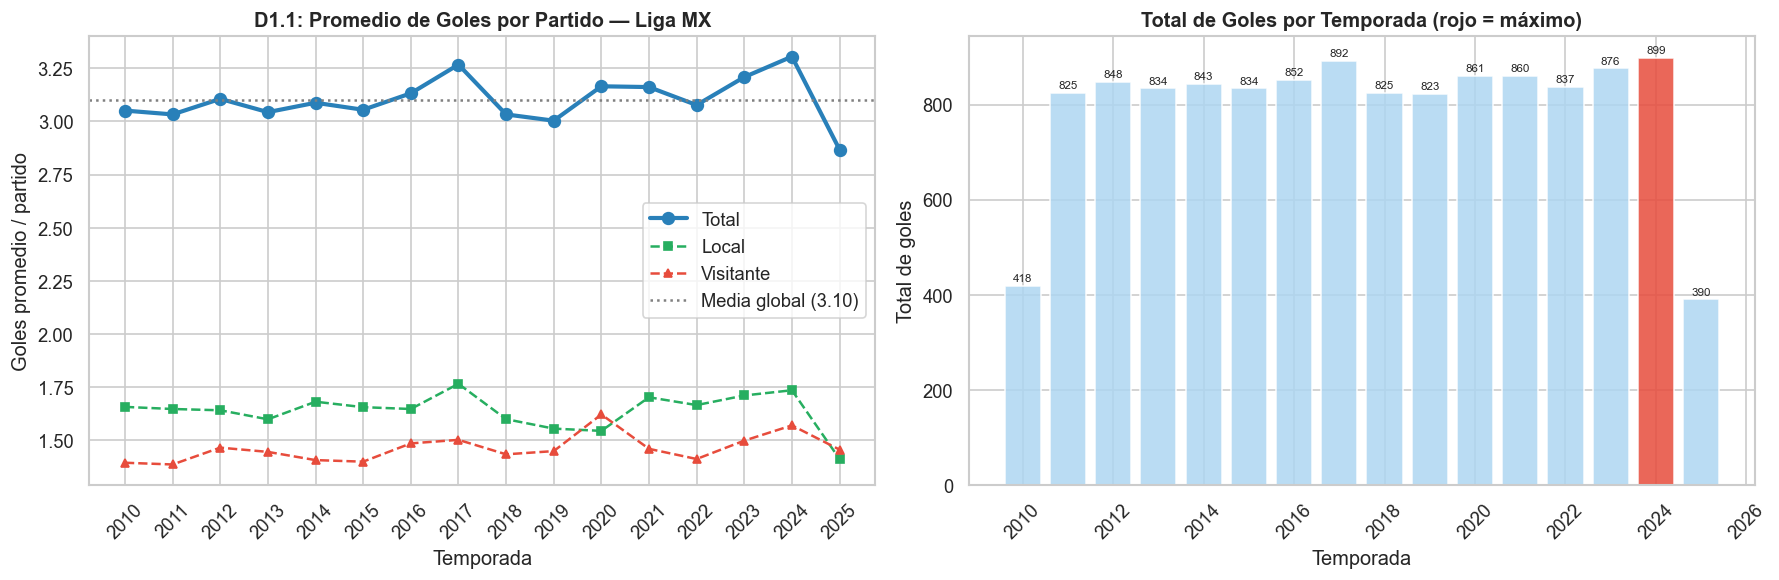

=== ESTADÍSTICAS POR TEMPORADA ===


,partidos,goles,media_goles,media_local,media_visit
season_year,,,,,
2010,137,418,3.051,1.657,1.394
2011,272,825,3.033,1.647,1.386
2012,273,848,3.106,1.641,1.465
2013,274,834,3.044,1.599,1.445
2014,273,843,3.088,1.681,1.407
2015,273,834,3.055,1.656,1.399
2016,272,852,3.132,1.647,1.485
2017,273,892,3.267,1.766,1.502
2018,272,825,3.033,1.599,1.434



Temporada más goleadora : 2024 (3.31 goles/partido)
Temporada menos goleadora: 2025 (2.87 goles/partido)


In [58]:
p = df_partidos_csv.copy()
p['goles_totales'] = p['home_goals'] + p['away_goals']

by_yr = p.groupby('season_year').agg(
    partidos=('match_id', 'count'),
    goles=('goles_totales', 'sum'),
    media_goles=('goles_totales', 'mean'),
    media_local=('home_goals', 'mean'),
    media_visit=('away_goals', 'mean')
).reset_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Promedio de goles por partido
ax1.plot(by_yr['season_year'], by_yr['media_goles'], 'o-', color='#2980B9', lw=2.5, ms=7, label='Total')
ax1.plot(by_yr['season_year'], by_yr['media_local'], 's--', color='#27AE60', lw=1.5, ms=5, label='Local')
ax1.plot(by_yr['season_year'], by_yr['media_visit'], '^--', color='#E74C3C', lw=1.5, ms=5, label='Visitante')
ax1.axhline(by_yr['media_goles'].mean(), color='gray', ls=':', lw=1.5, label=f'Media global ({by_yr["media_goles"].mean():.2f})')
ax1.set_title('D1.1: Promedio de Goles por Partido — Liga MX', fontweight='bold')
ax1.set_xlabel('Temporada'); ax1.set_ylabel('Goles promedio / partido')
ax1.legend(); ax1.set_xticks(by_yr['season_year'])
ax1.tick_params(axis='x', rotation=45)

# Total de goles por temporada
colors_yr = ['#E74C3C' if g == by_yr['goles'].max() else '#AED6F1' for g in by_yr['goles']]
ax2.bar(by_yr['season_year'], by_yr['goles'], color=colors_yr, alpha=0.85)
ax2.set_title('Total de Goles por Temporada (rojo = máximo)', fontweight='bold')
ax2.set_xlabel('Temporada'); ax2.set_ylabel('Total de goles')
ax2.tick_params(axis='x', rotation=45)
for _, row in by_yr.iterrows():
    ax2.text(row['season_year'], row['goles'] + 10, str(int(row['goles'])), ha='center', fontsize=7)

plt.tight_layout()
plt.show()

print('=== ESTADÍSTICAS POR TEMPORADA ===')
display(by_yr.set_index('season_year').round(3))

mejor = by_yr.loc[by_yr['media_goles'].idxmax()]
peor = by_yr.loc[by_yr['media_goles'].idxmin()]
print(f'\nTemporada más goleadora : {int(mejor.season_year)} ({mejor.media_goles:.2f} goles/partido)')
print(f'Temporada menos goleadora: {int(peor.season_year)} ({peor.media_goles:.2f} goles/partido)')

---
### D1.2 — ¿Qué estadios presentan mayor ventaja local?
> **Método:** Para cada `venue`, calculamos el promedio de goles locales, visitantes y diferencial. Mostramos el ranking de los 15 estadios con mayor ventaja local.  

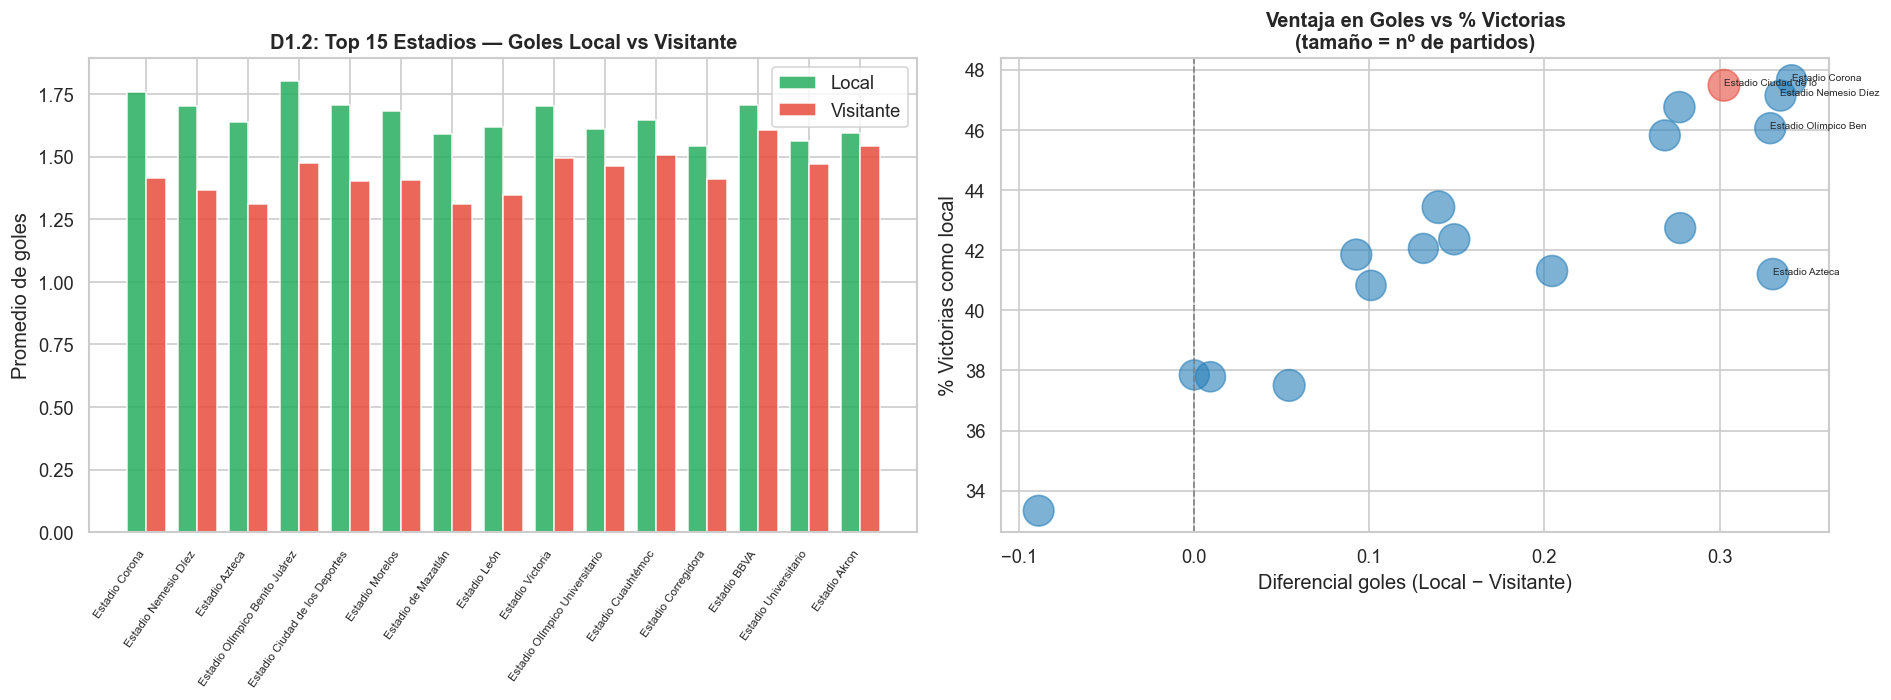

=== TOP 10 ESTADIOS CON MAYOR VENTAJA LOCAL ===


,Estadio,Partidos,Goles Local,Goles Visita,Ventaja,% Victoria
6,Estadio Corona,214,1.757,1.416,0.341,47.664
12,Estadio Nemesio Díez,227,1.700,1.366,0.335,47.137
2,Estadio Azteca,233,1.639,1.309,0.330,41.202
13,Estadio Olímpico Benito Juárez,228,1.803,1.474,0.329,46.053
5,Estadio Ciudad de los Deportes,238,1.706,1.403,0.303,47.479
11,Estadio Morelos,227,1.683,1.405,0.278,42.731
17,Estadio de Mazatlán,231,1.589,1.312,0.277,46.753
10,Estadio León,227,1.617,1.348,0.269,45.815
16,Estadio Victoria,230,1.700,1.496,0.204,41.304
14,Estadio Olímpico Universitario,229,1.611,1.463,0.148,42.358


In [59]:
venues = (df_partidos_csv.groupby('venue').agg(
    partidos=('match_id', 'count'),
    goles_local_prom=('home_goals', 'mean'),
    goles_visit_prom=('away_goals', 'mean'),
    victorias_local=('result_home', lambda x: (x == 'W').sum()),
    empates=('result_home', lambda x: (x == 'D').sum()),
    derrotas_local=('result_home', lambda x: (x == 'L').sum()),
).reset_index())

venues = venues[venues['partidos'] >= 10].copy()
venues['ventaja'] = venues['goles_local_prom'] - venues['goles_visit_prom']
venues['pct_victoria'] = venues['victorias_local'] / venues['partidos'] * 100
venues = venues.sort_values('ventaja', ascending=False)

top15 = venues.head(15)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Barras agrupadas: goles local vs visitante
x = np.arange(len(top15))
w = 0.38
ax1.bar(x - w/2, top15['goles_local_prom'], w, label='Local',    color='#27AE60', alpha=0.85)
ax1.bar(x + w/2, top15['goles_visit_prom'], w, label='Visitante', color='#E74C3C', alpha=0.85)
ax1.set_xticks(x)
ax1.set_xticklabels(top15['venue'], rotation=55, ha='right', fontsize=7)
ax1.set_title('D1.2: Top 15 Estadios — Goles Local vs Visitante', fontweight='bold')
ax1.set_ylabel('Promedio de goles'); ax1.legend()

# % victorias locales vs ventaja en goles
sc_colors = ['#E74C3C' if 'Ciudad de los Deportes' in str(v) or 'Cruz' in str(v) else '#2980B9' for v in venues['venue']]
ax2.scatter(venues['ventaja'], venues['pct_victoria'], s=venues['partidos'] * 1.5, alpha=0.6, c=sc_colors[:len(venues)])
ax2.axvline(0, color='gray', ls='--', lw=1)
ax2.set_xlabel('Diferencial goles (Local − Visitante)')
ax2.set_ylabel('% Victorias como local')
ax2.set_title('Ventaja en Goles vs % Victorias\n(tamaño = nº de partidos)', fontweight='bold')
for _, row in venues.head(5).iterrows():
    ax2.annotate(row['venue'][:20], (row['ventaja'], row['pct_victoria']), fontsize=6, ha='left')

plt.tight_layout()
plt.show()

print('=== TOP 10 ESTADIOS CON MAYOR VENTAJA LOCAL ===')
disp = top15[['venue', 'partidos', 'goles_local_prom', 'goles_visit_prom', 'ventaja', 'pct_victoria']].head(10)
disp.columns = ['Estadio', 'Partidos', 'Goles Local', 'Goles Visita', 'Ventaja', '% Victoria']
display(disp.round(3))

---
### D1.3 — ¿Difiere la distribución de resultados entre Apertura y Clausura?
> **Método:** Comparamos el porcentaje de victorias locales, empates y derrotas para cada mitad de temporada (`half`). 

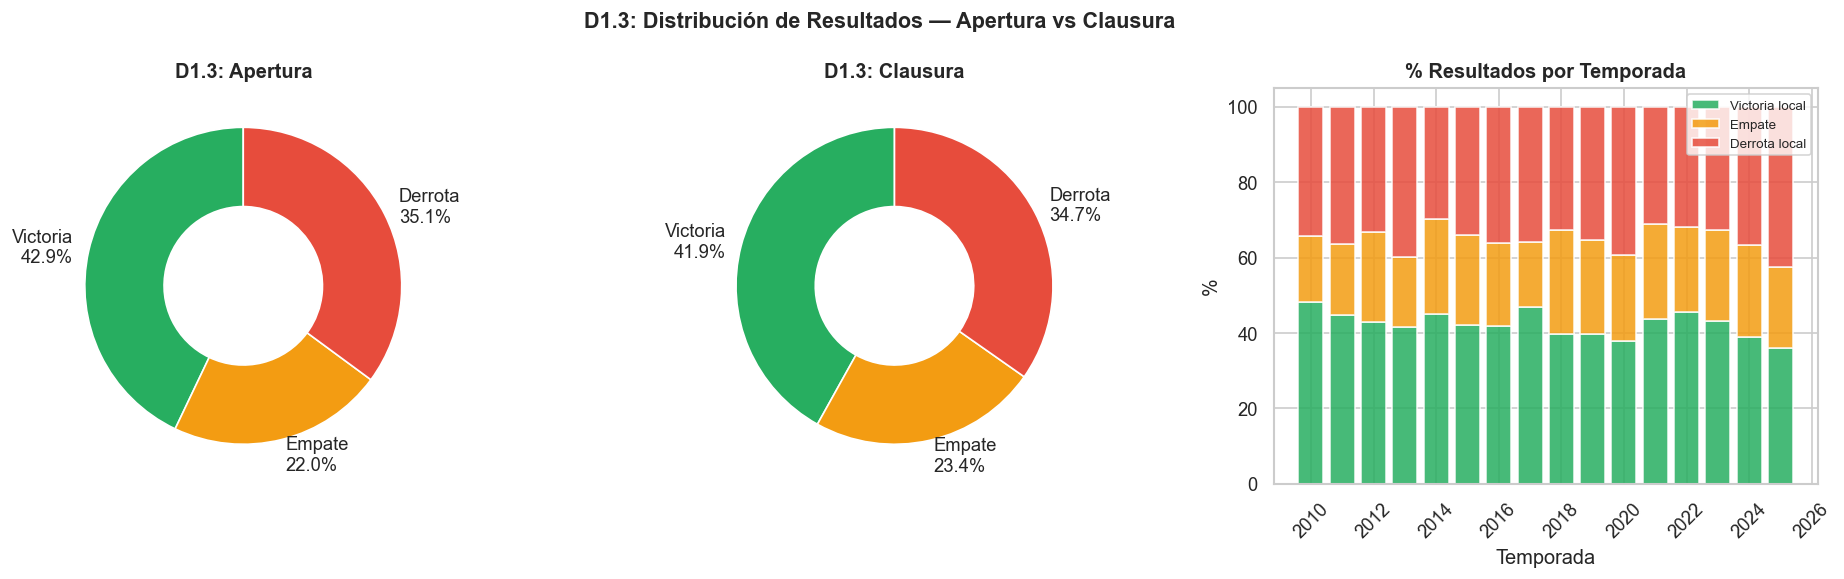

=== % RESULTADOS APERTURA vs CLAUSURA ===


result_home,W,D,L
half,,,
apertura,42.93,21.98,35.10
clausura,41.91,23.35,34.73



Test Chi² (Apertura vs Clausura): χ²=1.137, p=0.5665, dof=2
Sin diferencia significativa entre torneos


In [60]:
half_res = df_partidos_csv.groupby(['half', 'result_home'])['match_id'].count().unstack(fill_value=0)
half_res = half_res[['W', 'D', 'L']]
half_res['total'] = half_res.sum(axis=1)
half_pct = half_res[['W', 'D', 'L']].div(half_res['total'], axis=0) * 100

# Distribución por temporada y mitad
yr_half = df_partidos_csv.groupby(['season_year', 'half', 'result_home'])['match_id'].count().unstack(fill_value=0).reset_index()
yr_half.columns.name = None

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Donas Apertura / Clausura
colors_wdl = ['#27AE60', '#F39C12', '#E74C3C']
for i, half in enumerate(['apertura', 'clausura']):
    if half not in half_pct.index:
        continue
    vals = half_pct.loc[half, ['W', 'D', 'L']].values
    axes[i].pie(vals, labels=[f'Victoria\n{vals[0]:.1f}%',
                               f'Empate\n{vals[1]:.1f}%',
                               f'Derrota\n{vals[2]:.1f}%'],
                colors=colors_wdl, startangle=90,
                wedgeprops=dict(width=0.5))
    axes[i].set_title(f'D1.3: {half.capitalize()}', fontweight='bold')

# Barras apiladas por temporada (% victorias locales)
ax3 = axes[2]
yr_res = df_partidos_csv.groupby(['season_year', 'result_home'])['match_id']\
    .count().unstack(fill_value=0)
yr_res = yr_res.reindex(columns=['W', 'D', 'L'], fill_value=0)
yr_pct = yr_res.div(yr_res.sum(axis=1), axis=0) * 100

bottom_d = yr_pct['W']
bottom_l = yr_pct['W'] + yr_pct['D']
ax3.bar(yr_pct.index, yr_pct['W'], color='#27AE60', alpha=0.85, label='Victoria local')
ax3.bar(yr_pct.index, yr_pct['D'], bottom=bottom_d, color='#F39C12', alpha=0.85, label='Empate')
ax3.bar(yr_pct.index, yr_pct['L'], bottom=bottom_l, color='#E74C3C', alpha=0.85, label='Derrota local')
ax3.set_title('% Resultados por Temporada', fontweight='bold')
ax3.set_xlabel('Temporada'); ax3.set_ylabel('%')
ax3.tick_params(axis='x', rotation=45)
ax3.legend(fontsize=8)

plt.suptitle('D1.3: Distribución de Resultados — Apertura vs Clausura', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('=== % RESULTADOS APERTURA vs CLAUSURA ===')
display(half_pct.round(2))

# Test chi-cuadrado para comparar distribuciones
if 'apertura' in half_res.index and 'clausura' in half_res.index:
    chi2, p_val, dof, _ = stats.chi2_contingency(
        half_res.loc[['apertura', 'clausura'], ['W', 'D', 'L']])
    print(f'\nTest Chi² (Apertura vs Clausura): χ²={chi2:.3f}, p={p_val:.4f}, dof={dof}')
    print('Diferencia estadísticamente significativa (p<0.05)' if p_val < 0.05
          else 'Sin diferencia significativa entre torneos')

---
### P1.4 — ¿Se puede predecir el resultado final a partir del marcador al medio tiempo?
> **Método:** Usamos clasificación por Random Forest multiclase (W/D/L). Features: `home_goals_ht`, `away_goals_ht`, diferencial al MT, `half` codificado.  

=== P1.4: PREDICCIÓN RESULTADO FINAL DESDE MARCADOR MT ===
              precision    recall  f1-score   support

           D       0.33      0.51      0.40       232
           L       0.69      0.58      0.63       357
           W       0.75      0.64      0.69       434

    accuracy                           0.59      1023
   macro avg       0.59      0.57      0.57      1023
weighted avg       0.63      0.59      0.60      1023

AUC-ROC (macro OvR): 0.7600


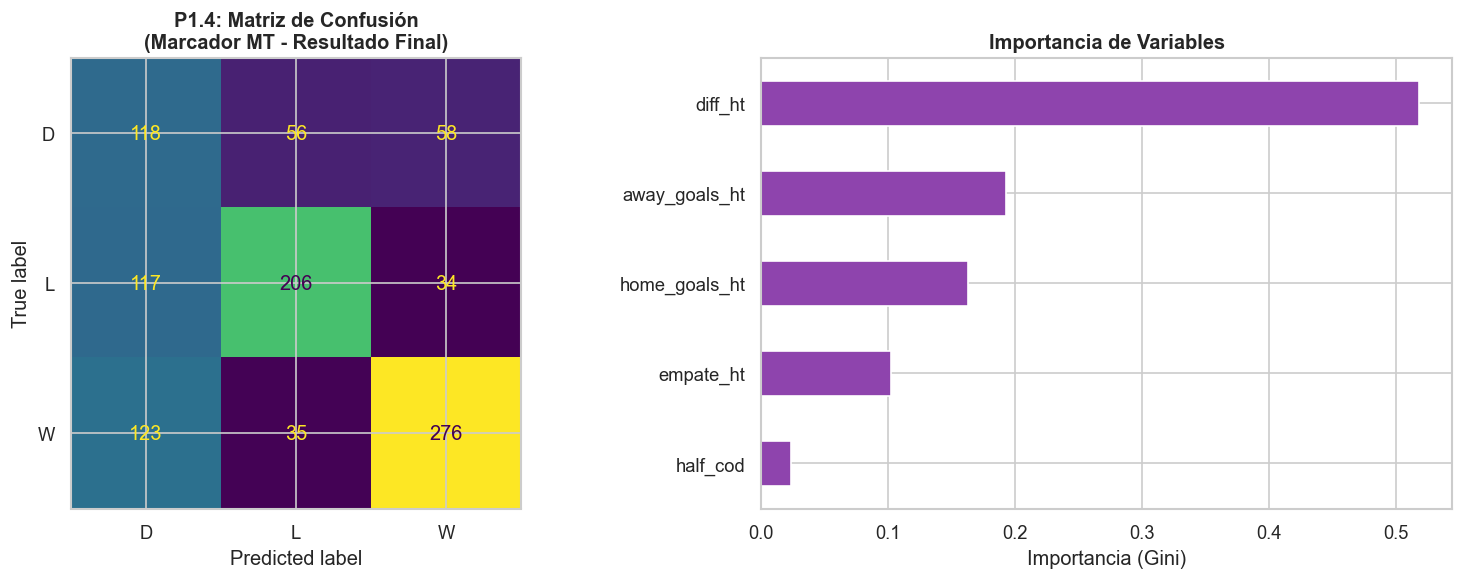


=== PROBABILIDADES RESULTADO FINAL SEGÚN MARCADOR MT ===
MT 2-0 -> D: 15.4% | L: 6.6% | W: 78.0%
MT 1-0 -> D: 26.7% | L: 15.0% | W: 58.3%
MT 0-0 -> D: 43.7% | L: 29.5% | W: 26.8%
MT 1-1 -> D: 47.6% | L: 26.0% | W: 26.3%
MT 0-1 -> D: 34.0% | L: 51.9% | W: 14.1%
MT 0-2 -> D: 16.0% | L: 78.5% | W: 5.5%


In [61]:
p14 = df_partidos_csv[['home_goals_ht', 'away_goals_ht', 'result_home', 'half']].dropna().copy()
p14['diff_ht']   = p14['home_goals_ht'] - p14['away_goals_ht']
p14['empate_ht'] = (p14['diff_ht'] == 0).astype(int)
p14['half_cod']  = (p14['half'] == 'clausura').astype(int)

feats14 = ['home_goals_ht', 'away_goals_ht', 'diff_ht', 'empate_ht', 'half_cod']
le14 = LabelEncoder()
y14  = le14.fit_transform(p14['result_home'])
X14  = p14[feats14].values

X14_tr, X14_te, y14_tr, y14_te = train_test_split(X14, y14, test_size=0.25, random_state=42, stratify=y14)
rf14 = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42, class_weight='balanced')
rf14.fit(X14_tr, y14_tr)
y14_pred = rf14.predict(X14_te)
y14_prob  = rf14.predict_proba(X14_te)

print('=== P1.4: PREDICCIÓN RESULTADO FINAL DESDE MARCADOR MT ===')
print(classification_report(y14_te, y14_pred, target_names=le14.classes_))

auc_ovr = roc_auc_score(y14_te, y14_prob, multi_class='ovr', average='macro')
print(f'AUC-ROC (macro OvR): {auc_ovr:.4f}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

cm14 = confusion_matrix(y14_te, y14_pred)
ConfusionMatrixDisplay(cm14, display_labels=le14.classes_).plot(ax=ax1, colorbar=False)
ax1.set_title('P1.4: Matriz de Confusión\n(Marcador MT - Resultado Final)', fontweight='bold')

imp14 = pd.Series(rf14.feature_importances_, index=feats14).sort_values()
imp14.plot(kind='barh', ax=ax2, color='#8E44AD')
ax2.set_title('Importancia de Variables', fontweight='bold')
ax2.set_xlabel('Importancia (Gini)')

plt.tight_layout()
plt.show()

print('\n=== PROBABILIDADES RESULTADO FINAL SEGÚN MARCADOR MT ===')
escenarios = pd.DataFrame([
    [2, 0], [1, 0], [0, 0], [1, 1], [0, 1], [0, 2]
], columns=['home_goals_ht', 'away_goals_ht'])
escenarios['diff_ht'] = escenarios['home_goals_ht'] - escenarios['away_goals_ht']
escenarios['empate_ht'] = (escenarios['diff_ht'] == 0).astype(int)
escenarios['half_cod'] = 0
probs_esc = rf14.predict_proba(escenarios[feats14].values)
for i, (_, row) in enumerate(escenarios.iterrows()):
    p = probs_esc[i]
    print(f"MT {int(row.home_goals_ht)}-{int(row.away_goals_ht)} -> " + ' | '.join([f'{cls}: {p[j]*100:.1f}%' for j, cls in enumerate(le14.classes_)]))

### PR1.5 — ¿En qué jornadas históricas Cruz Azul rinde peor como visitante?
> **Método:** Filtramos partidos donde Cruz Azul es visitante (`involves_cruz_azul=1` + `away_team` contiene Cruz Azul) y calculamos puntos obtenidos, goles a favor/en contra y tasa de derrota por `round`.  

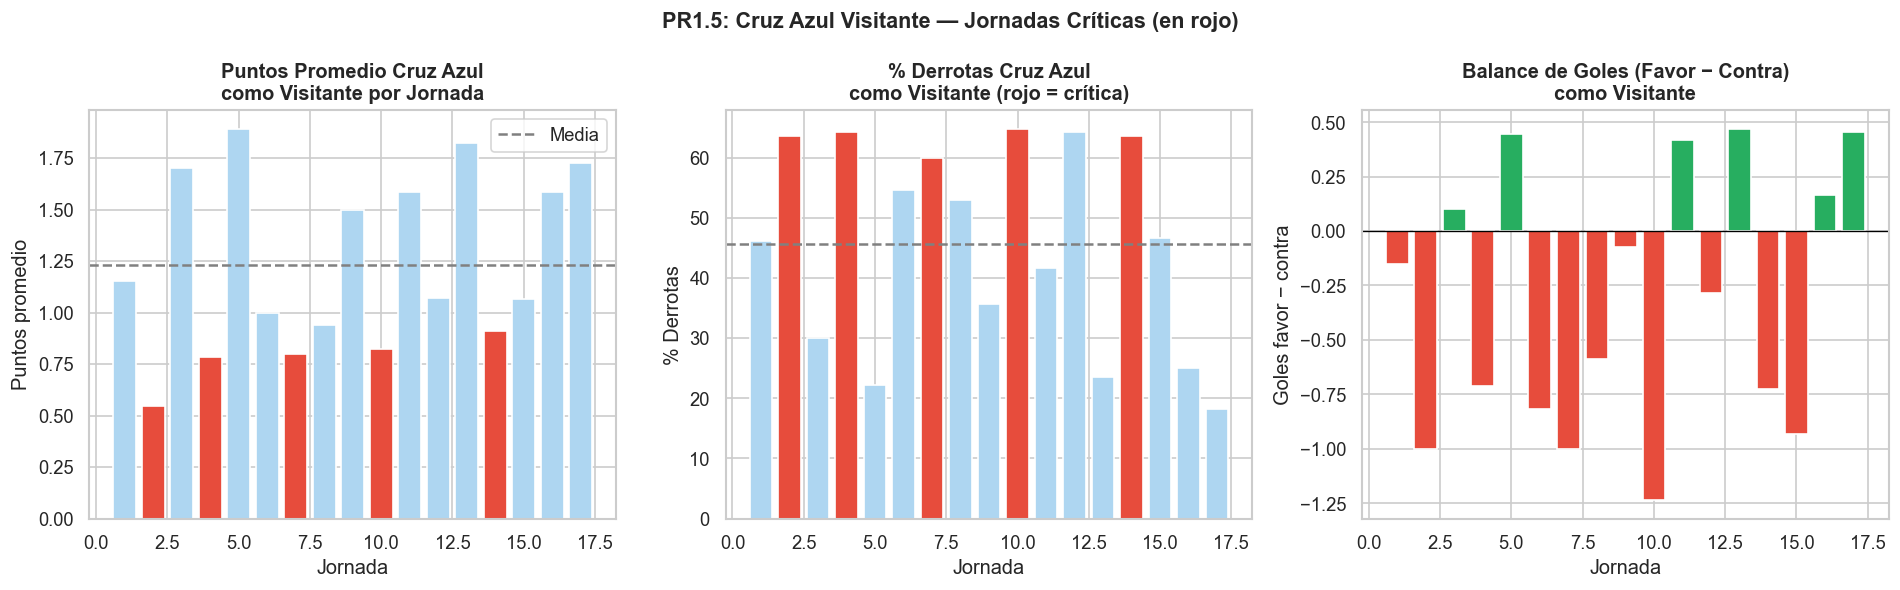

=== PRESCRIPCIÓN: JORNADAS CRÍTICAS PARA PREPARACIÓN REFORZADA ===
Total partidos como visitante analizados: 223

Jornadas críticas identificadas: [2, 4, 7, 10, 14]

Detalle de las 5 jornadas más problemáticas:


,Jornada,Partidos,Pts Prom,Tasa Derrota,Goles Favor,Goles Contra,Balance,Índice Crítico
1,2,11,0.545,0.636,0.727,1.727,-1.000,0.991
3,4,14,0.786,0.643,1.357,2.071,-0.714,0.889
9,10,17,0.824,0.647,0.765,2.000,-1.235,0.876
6,7,15,0.800,0.600,1.067,2.067,-1.000,0.846
13,14,11,0.909,0.636,1.545,2.273,-0.727,0.828


In [62]:
ca_visit_csv = df_partidos_csv[df_partidos_csv['away_team'].str.contains('Cruz Azul|C\. Azul|C\.Azul', case=False, na=False)].copy()

ca_visit_csv['pts_ca'] = ca_visit_csv['result_home'].map({'W': 0, 'D': 1, 'L': 3})
ca_visit_csv['derrota'] = (ca_visit_csv['result_home'] == 'W').astype(int)

by_round = ca_visit_csv.groupby('round').agg(
    partidos=('match_id', 'count'),
    pts_promedio=('pts_ca', 'mean'),
    tasa_derrota=('derrota', 'mean'),
    goles_favor=('away_goals', 'mean'),
    goles_contra=('home_goals', 'mean')
).reset_index()
by_round['balance_goles'] = by_round['goles_favor'] - by_round['goles_contra']
by_round = by_round[by_round['partidos'] >= 3]

# Jornadas críticas: baja puntuación Y alta tasa de derrota
by_round['indice_critico'] = (1 - MinMaxScaler().fit_transform(by_round[['pts_promedio']])).flatten() * 0.6 + MinMaxScaler().fit_transform(by_round[['tasa_derrota']]).flatten() * 0.4
criticas = by_round.nlargest(5, 'indice_critico')['round'].tolist()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Puntos promedio por jornada
colors_r = ['#E74C3C' if r in criticas else '#AED6F1' for r in by_round['round']]
axes[0].bar(by_round['round'], by_round['pts_promedio'], color=colors_r)
axes[0].axhline(by_round['pts_promedio'].mean(), color='gray', ls='--', lw=1.5, label='Media')
axes[0].set_title('Puntos Promedio Cruz Azul\ncomo Visitante por Jornada', fontweight='bold')
axes[0].set_xlabel('Jornada'); axes[0].set_ylabel('Puntos promedio')
axes[0].legend()

# Tasa de derrota
colors_r2 = ['#E74C3C' if r in criticas else '#AED6F1' for r in by_round['round']]
axes[1].bar(by_round['round'], by_round['tasa_derrota'] * 100, color=colors_r2)
axes[1].axhline(by_round['tasa_derrota'].mean() * 100, color='gray', ls='--', lw=1.5)
axes[1].set_title('% Derrotas Cruz Azul\ncomo Visitante (rojo = crítica)', fontweight='bold')
axes[1].set_xlabel('Jornada'); axes[1].set_ylabel('% Derrotas')

# Balance de goles
axes[2].bar(by_round['round'], by_round['balance_goles'], color=['#27AE60' if b >= 0 else '#E74C3C' for b in by_round['balance_goles']])
axes[2].axhline(0, color='black', lw=0.8)
axes[2].set_title('Balance de Goles (Favor − Contra)\ncomo Visitante', fontweight='bold')
axes[2].set_xlabel('Jornada'); axes[2].set_ylabel('Goles favor − contra')

plt.suptitle('PR1.5: Cruz Azul Visitante — Jornadas Críticas (en rojo)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('=== PRESCRIPCIÓN: JORNADAS CRÍTICAS PARA PREPARACIÓN REFORZADA ===')
print(f'Total partidos como visitante analizados: {len(ca_visit_csv)}')
print(f'\nJornadas críticas identificadas: {sorted(criticas)}')
print('\nDetalle de las 5 jornadas más problemáticas:')
detalle = by_round[by_round['round'].isin(criticas)].sort_values('indice_critico', ascending=False)
detalle.columns = ['Jornada', 'Partidos', 'Pts Prom', 'Tasa Derrota', 'Goles Favor', 'Goles Contra', 'Balance', 'Índice Crítico']
display(detalle.round(3))

---
### D2.1 — Atributos FIFA promedio por posición
> **Método:** Agrupamos por posición y calculamos la media de los 6 atributos FIFA. Con esto, creamos un heatmap de la matriz posición × atributo. 

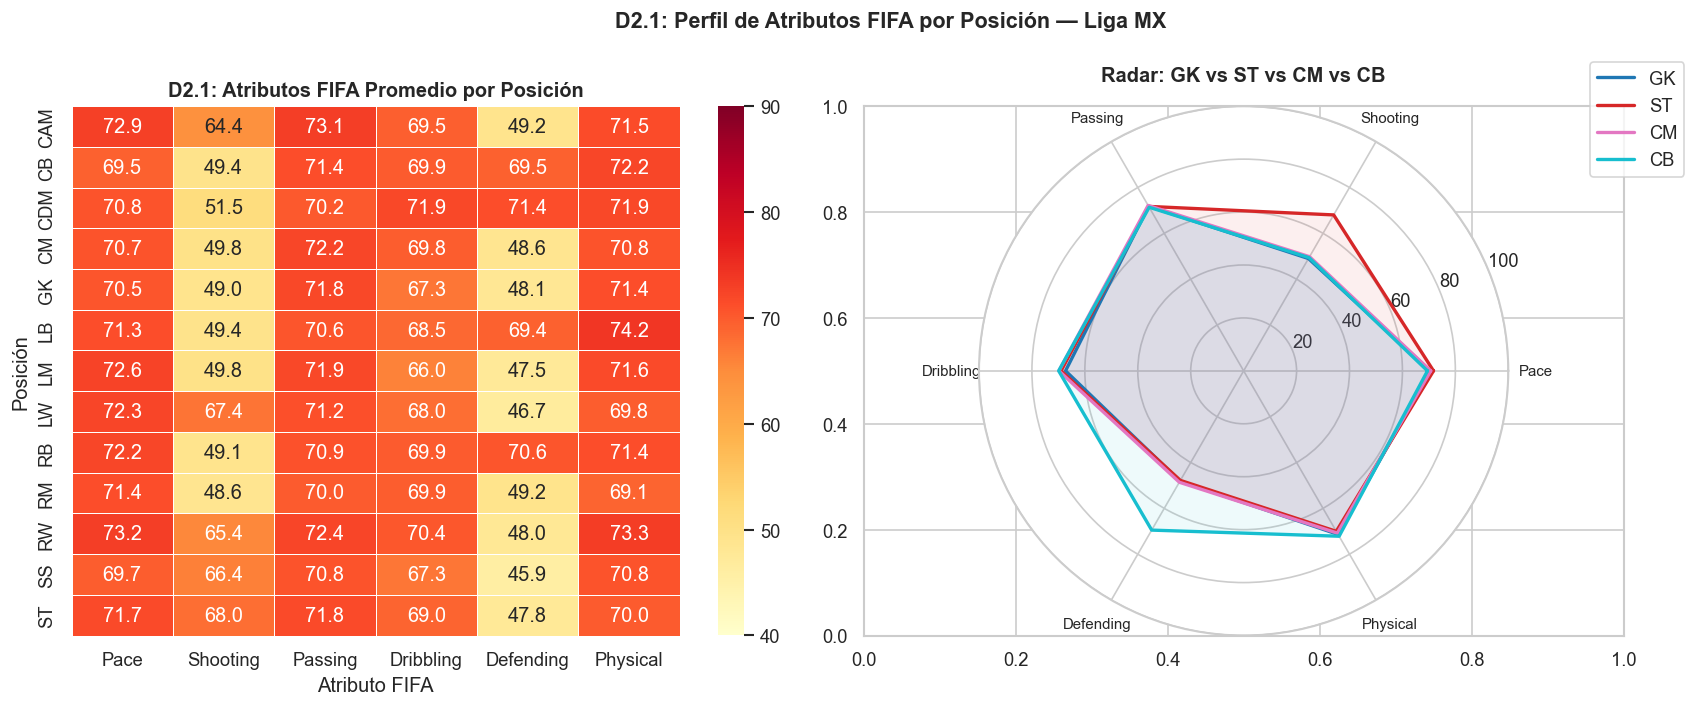

=== ATRIBUTOS FIFA PROMEDIO POR POSICIÓN ===


,Pace,Shooting,Passing,Dribbling,Defending,Physical
posicion,,,,,,
CAM,72.9,64.4,73.1,69.5,49.2,71.5
CB,69.5,49.4,71.4,69.9,69.5,72.2
CDM,70.8,51.5,70.2,71.9,71.4,71.9
CM,70.7,49.8,72.2,69.8,48.6,70.8
GK,70.5,49.0,71.8,67.3,48.1,71.4
LB,71.3,49.4,70.6,68.5,69.4,74.2
LM,72.6,49.8,71.9,66.0,47.5,71.6
LW,72.3,67.4,71.2,68.0,46.7,69.8
RB,72.2,49.1,70.9,69.9,70.6,71.4



Total registros con datos FIFA completos: 1158


In [63]:
fifa_attrs = ['fifa_pace', 'fifa_shooting', 'fifa_passing', 'fifa_dribbling', 'fifa_defending', 'fifa_physical']
attr_labels = ['Pace', 'Shooting', 'Passing', 'Dribbling', 'Defending', 'Physical']

d21 = df_json[['posicion'] + fifa_attrs].dropna()
pos_counts = d21['posicion'].value_counts()
top_pos21 = pos_counts[pos_counts >= 15].index.tolist()
d21 = d21[d21['posicion'].isin(top_pos21)]

pos_means = d21.groupby('posicion')[fifa_attrs].mean()
pos_means.columns = attr_labels

# Normalizar para el heatmap 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

sns.heatmap(pos_means, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5, ax=ax1, vmin=40, vmax=90)
ax1.set_title('D2.1: Atributos FIFA Promedio por Posición', fontweight='bold')
ax1.set_xlabel('Atributo FIFA'); ax1.set_ylabel('Posición')

# chart para GK vs ST vs CM
ax2 = plt.subplot(1, 2, 2, polar=True)
radar_pos = [p for p in ['GK', 'ST', 'CM', 'CB'] if p in pos_means.index]
angles21  = np.linspace(0, 2 * np.pi, len(attr_labels), endpoint=False).tolist()
angles21 += angles21[:1]
cmap21 = plt.cm.get_cmap('tab10', len(radar_pos))

for i, pos in enumerate(radar_pos):
    vals21 = pos_means.loc[pos].tolist() + [pos_means.loc[pos].tolist()[0]]
    ax2.plot(angles21, vals21, lw=2, label=pos, color=cmap21(i))
    ax2.fill(angles21, vals21, alpha=0.07, color=cmap21(i))

ax2.set_xticks(angles21[:-1])
ax2.set_xticklabels(attr_labels, fontsize=9)
ax2.set_ylim(0, 100)
ax2.set_title('Radar: GK vs ST vs CM vs CB', fontweight='bold', pad=15)
ax2.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1))

plt.suptitle('D2.1: Perfil de Atributos FIFA por Posición — Liga MX', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('=== ATRIBUTOS FIFA PROMEDIO POR POSICIÓN ===')
display(pos_means.round(1))
print(f'\nTotal registros con datos FIFA completos: {len(d21)}')

---
### D2.2 — ¿Cuánto sobre o infra-pagan los equipos en transferencias vs valor Transfermarkt?
> **Método:** Calculamos `ratio_pago = transfer_paid_eur / valor_mercado_eur` por equipo, donde un ratio > 1 = sobre-pago.  

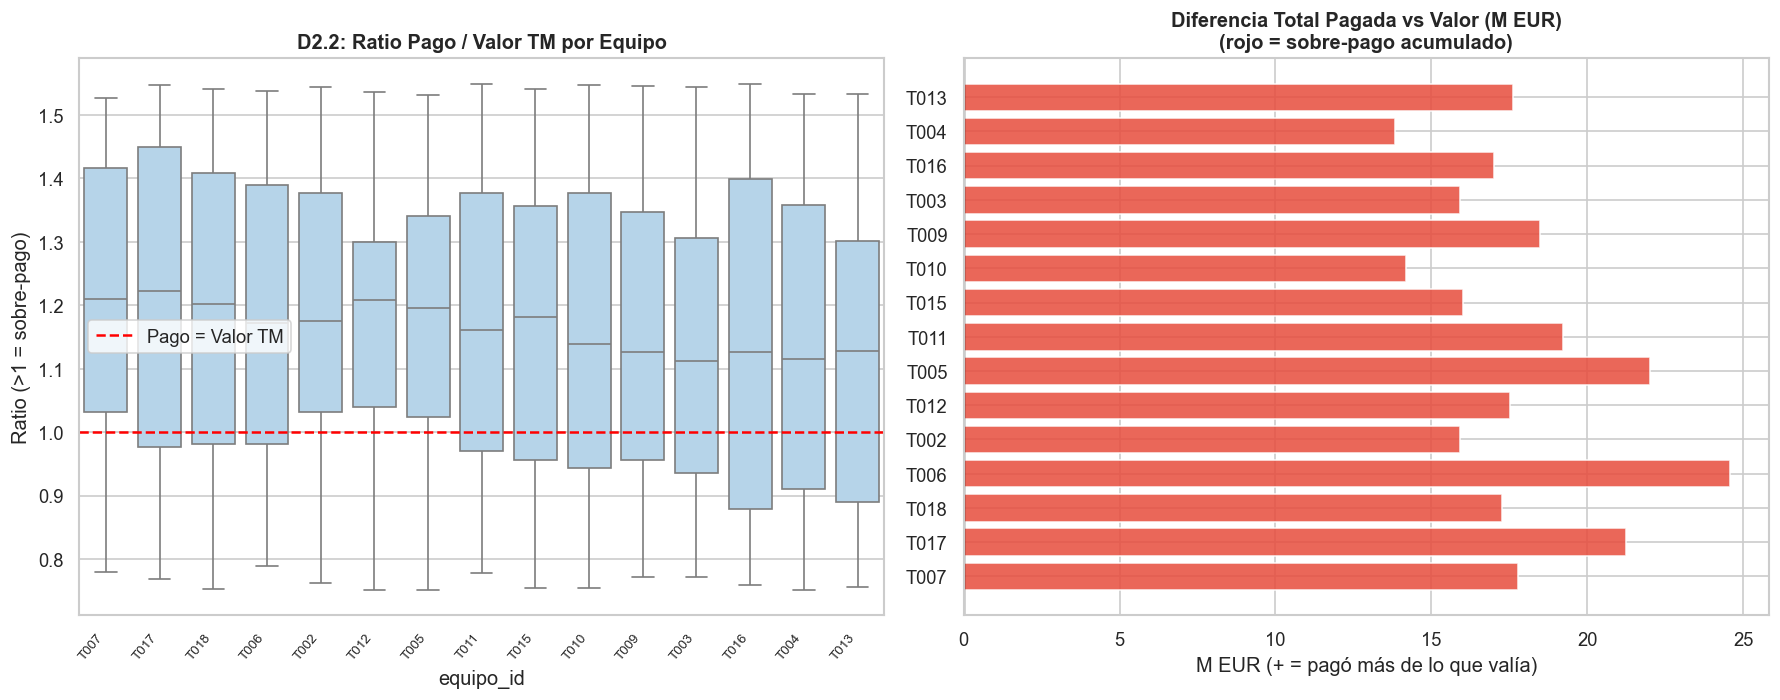

=== D2.2: RATIO PAGO/VALOR POR EQUIPO (n≥5 transferencias) ===
Total registros: 1085 jugadores con datos Transfermarkt completos



,equipo_id,n,ratio_medio,ratio_mediano,dif_total_m
6,T007,44,1.204,1.210,17.788
16,T017,58,1.197,1.222,21.242
17,T018,55,1.188,1.202,17.279
5,T006,65,1.187,1.172,24.588
1,T002,58,1.183,1.176,15.926
11,T012,57,1.172,1.208,17.519
4,T005,70,1.171,1.196,22.008
10,T011,65,1.169,1.161,19.207
14,T015,56,1.163,1.181,16.020
9,T010,58,1.149,1.139,14.174



Ratio global promedio : 1.152
Ratio global mediano  : 1.155
Los equipos pagan en promedio 15.2% MÁS que el valor Transfermarkt.


In [64]:
d22 = df_json[df_json['valor_mercado_eur'].notna() &
              df_json['transfer_paid_eur'].notna() &
              (df_json['valor_mercado_eur'] > 0)].copy()
d22['ratio_pago']  = d22['transfer_paid_eur'] / d22['valor_mercado_eur']
d22['diferencia_m'] = (d22['transfer_paid_eur'] - d22['valor_mercado_eur']) / 1e6
 
# Usamos equipo_id como referencia
equipo_ratio = d22.groupby('equipo_id').agg(
    n=('ratio_pago', 'count'),
    ratio_medio=('ratio_pago', 'mean'),
    ratio_mediano=('ratio_pago', 'median'),
    dif_total_m=('diferencia_m', 'sum')
).reset_index()
equipo_ratio = equipo_ratio[equipo_ratio['n'] >= 5].sort_values('ratio_medio', ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Boxplot ratio por equipo (top 15)
top15_eq = equipo_ratio.head(15)['equipo_id'].tolist()
d22_top  = d22[d22['equipo_id'].isin(top15_eq)]
order22  = equipo_ratio[equipo_ratio['equipo_id'].isin(top15_eq)].sort_values('ratio_medio', ascending=False)['equipo_id'].tolist()
sns.boxplot(data=d22_top, x='equipo_id', y='ratio_pago', order=order22, color='#AED6F1', fliersize=2, ax=ax1)
ax1.axhline(1.0, color='red', ls='--', lw=1.5, label='Pago = Valor TM')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=50, ha='right', fontsize=8)
ax1.set_title('D2.2: Ratio Pago / Valor TM por Equipo', fontweight='bold')
ax1.set_ylabel('Ratio (>1 = sobre-pago)'); ax1.legend()

# Diferencia total acumulada 
colors22 = ['#E74C3C' if v > 0 else '#27AE60' for v in equipo_ratio.head(15)['dif_total_m']]
ax2.barh(equipo_ratio.head(15)['equipo_id'], equipo_ratio.head(15)['dif_total_m'], color=colors22, alpha=0.85)
ax2.axvline(0, color='black', lw=0.8)
ax2.set_title('Diferencia Total Pagada vs Valor (M EUR)\n(rojo = sobre-pago acumulado)', fontweight='bold')
ax2.set_xlabel('M EUR (+ = pagó más de lo que valía)')

plt.tight_layout()
plt.show()

print(f'=== D2.2: RATIO PAGO/VALOR POR EQUIPO (n≥5 transferencias) ===')
print(f'Total registros: {len(d22)} jugadores con datos Transfermarkt completos\n')
display(equipo_ratio.head(12).round(3))

media_global = d22['ratio_pago'].mean()
mediana_global = d22['ratio_pago'].median()
print(f'\nRatio global promedio : {media_global:.3f}')
print(f'Ratio global mediano  : {mediana_global:.3f}')
print('Los equipos pagan en promedio'
      + (f' {(media_global-1)*100:.1f}% MÁS' if media_global > 1 else f' {(1-media_global)*100:.1f}% MENOS')
      + ' que el valor Transfermarkt.')

---
### D2.3 — ¿Qué equipos han registrado más jugadores distintos a lo largo de las temporadas?
> **Método:** Contamos jugadores únicos (`player_id`) por `equipo_id` y por `season_year`. Calculamos la tasa de rotación media anual.  

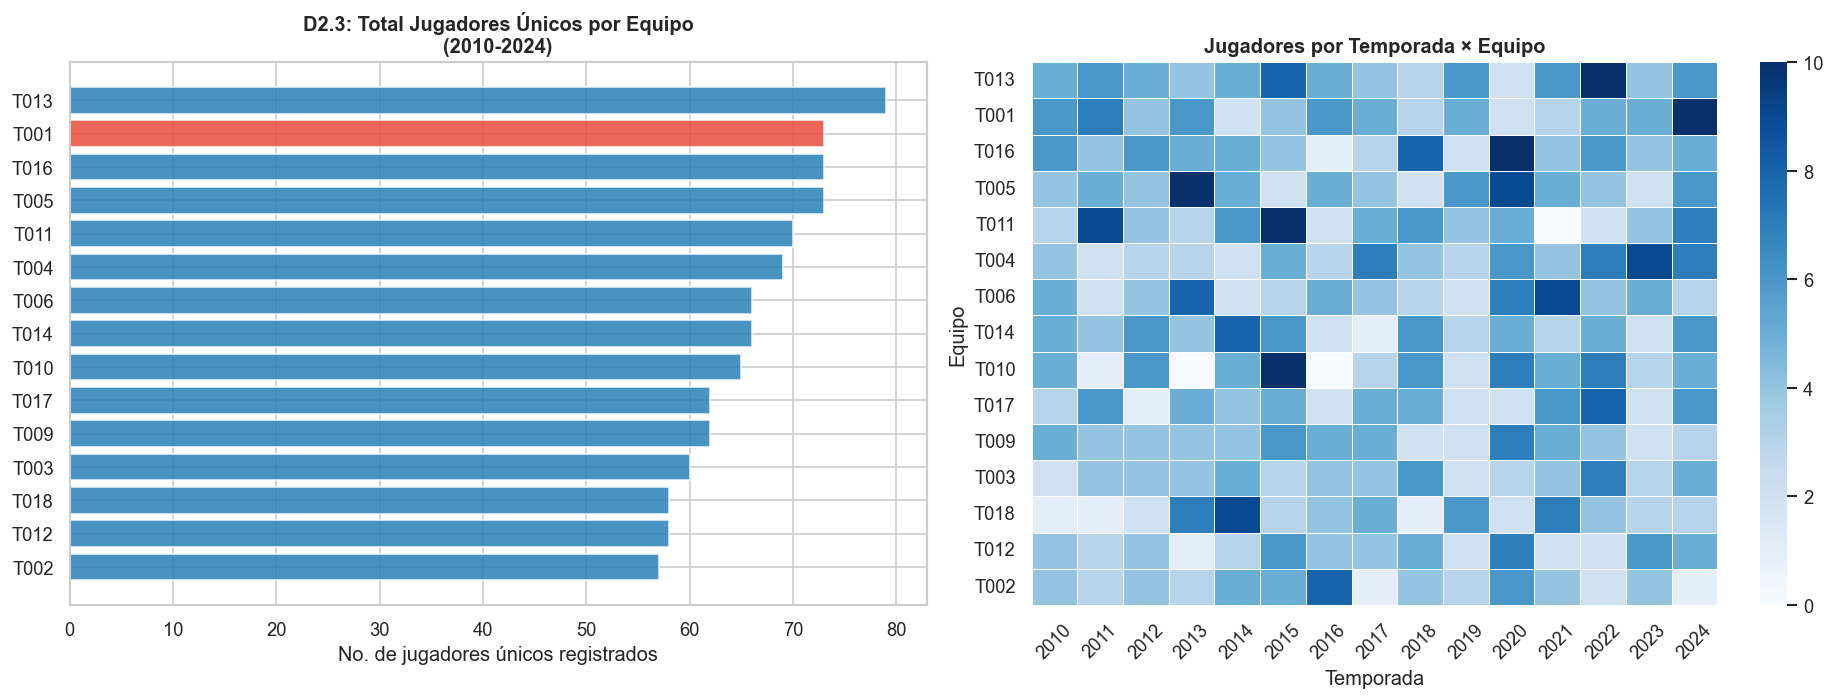

=== TOP 15 EQUIPOS POR TOTAL DE JUGADORES ÚNICOS ===


,equipo_id,jugadores_unicos
12,T013,79
0,T001,73
15,T016,73
4,T005,73
10,T011,70
3,T004,69
5,T006,66
13,T014,66
9,T010,65
16,T017,62



=== TASA DE ROTACIÓN (volatilidad de plantilla) ===


,mean,std,tasa_rotacion
equipo_id,,,
T010,4.33,2.82,0.65
T018,3.87,2.47,0.64
T011,4.67,2.66,0.57
T006,4.40,2.16,0.49
T017,4.13,2.03,0.49
T002,3.80,1.82,0.48
T005,4.87,2.29,0.47
T004,4.60,2.13,0.46
T016,4.87,2.23,0.46


In [65]:
d23 = df_json[df_json['equipo_id'].notna() & df_json['season_year'].notna()].copy()

# Total jugadores únicos por equipo
total_por_eq = (d23.groupby('equipo_id')['player_id'].nunique().reset_index(name='jugadores_unicos').sort_values('jugadores_unicos', ascending=False))

# Jugadores por temporada × equipo 
piv23 = d23.groupby(['season_year', 'equipo_id'])['player_id'].nunique().unstack(fill_value=0)
# Top 15 equipos con más jugadores únicos totales
top15_eq23 = total_por_eq.head(15)['equipo_id'].tolist()
piv23_top = piv23[top15_eq23] if all(e in piv23.columns for e in top15_eq23) else piv23

# Tasa de rotación = std de jugadores por temporada / media
rotacion = piv23_top.agg(['mean', 'std']).T
rotacion['tasa_rotacion'] = rotacion['std'] / rotacion['mean']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
 
colors23 = ['#E74C3C' if 'T001' in str(e) or 'Cruz' in str(e) else '#2980B9' for e in total_por_eq.head(15)['equipo_id']]
ax1.barh(total_por_eq.head(15)['equipo_id'][::-1], total_por_eq.head(15)['jugadores_unicos'][::-1], color=colors23[::-1], alpha=0.85)
ax1.set_title('D2.3: Total Jugadores Únicos por Equipo\n(2010-2024)', fontweight='bold')
ax1.set_xlabel('No. de jugadores únicos registrados')
 
sns.heatmap(piv23_top.T, cmap='Blues', ax=ax2, linewidths=0.3, annot=False, fmt='d')
ax2.set_title('Jugadores por Temporada × Equipo', fontweight='bold')
ax2.set_xlabel('Temporada'); ax2.set_ylabel('Equipo')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print('=== TOP 15 EQUIPOS POR TOTAL DE JUGADORES ÚNICOS ===')
display(total_por_eq.head(15))

print('\n=== TASA DE ROTACIÓN (volatilidad de plantilla) ===')
rot_sorted = rotacion.sort_values('tasa_rotacion', ascending=False)
display(rot_sorted[['mean', 'std', 'tasa_rotacion']].round(2).head(12))

---
### P2.4 — ¿Se puede clasificar la posición táctica usando solo atributos FIFA?
> **Método:** Agrupamos posiciones en 4 categorías (GK / DEF / MID / FWD), y después utilizamos Random Forest con estas como target y 6 atributos FIFA como features.  

=== P2.4: CLASIFICACIÓN DE POSICIÓN TÁCTICA CON ATRIBUTOS FIFA ===
Distribución por grupo: {'DEF': np.int64(296), 'FWD': np.int64(466), 'GK': np.int64(63), 'MID': np.int64(333)}

              precision    recall  f1-score   support

         DEF       0.58      0.85      0.69        74
         FWD       0.62      0.63      0.63       117
          GK       0.23      0.19      0.21        16
         MID       0.29      0.17      0.21        83

    accuracy                           0.53       290
   macro avg       0.43      0.46      0.43       290
weighted avg       0.49      0.53      0.50       290



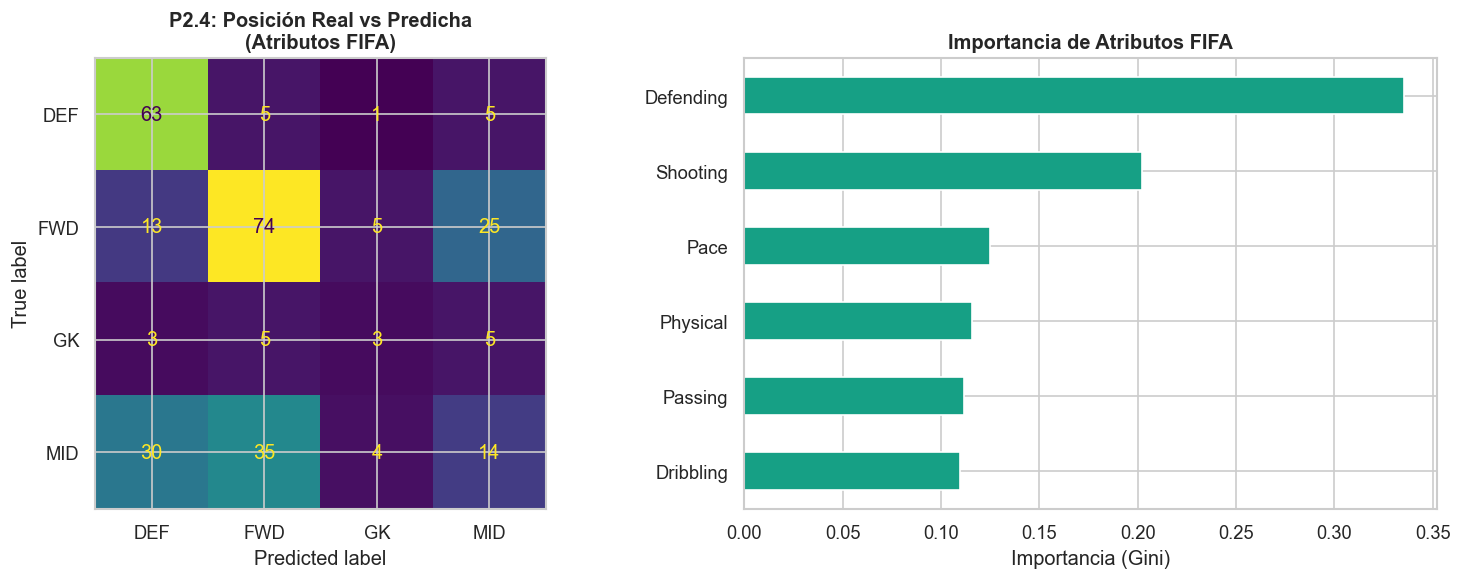

AUC-ROC (macro OvR): 0.7426

Atributo más discriminativo: Defending


In [66]:
def pos_grupo(p):
    if pd.isna(p): return None
    p = str(p).upper()
    if p == 'GK': 
        return 'GK'
    if any(x in p for x in ['CB','RB','LB','RWB','LWB','DF','SW','DC']): 
        return 'DEF'
    if any(x in p for x in ['CM','CDM','CAM','MF','DM','AM','MC','MI','MD']): 
        return 'MID'
    if any(x in p for x in ['ST','CF','LW','RW','SS','FW','RM','LM','AT']): 
        return 'FWD'
    return None

d24 = df_json[fifa_attrs + ['posicion']].dropna().copy()
d24['grupo'] = d24['posicion'].apply(pos_grupo)
d24 = d24.dropna(subset=['grupo'])

X24 = d24[fifa_attrs].values
le24 = LabelEncoder()
y24 = le24.fit_transform(d24['grupo'])

X24_tr, X24_te, y24_tr, y24_te = train_test_split(X24, y24, test_size=0.25, random_state=42, stratify=y24)
rf24 = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, class_weight='balanced')
rf24.fit(X24_tr, y24_tr)
y24_pred = rf24.predict(X24_te)

print('=== P2.4: CLASIFICACIÓN DE POSICIÓN TÁCTICA CON ATRIBUTOS FIFA ===')
print(f'Distribución por grupo: {dict(zip(*np.unique(d24["grupo"], return_counts=True)))}')
print()
print(classification_report(y24_te, y24_pred, target_names=le24.classes_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

cm24 = confusion_matrix(y24_te, y24_pred)
ConfusionMatrixDisplay(cm24, display_labels=le24.classes_).plot(ax=ax1, colorbar=False)
ax1.set_title('P2.4: Posición Real vs Predicha\n(Atributos FIFA)', fontweight='bold')

imp24 = pd.Series(rf24.feature_importances_, index=attr_labels).sort_values()
imp24.plot(kind='barh', ax=ax2, color='#16A085')
ax2.set_title('Importancia de Atributos FIFA', fontweight='bold')
ax2.set_xlabel('Importancia (Gini)')

plt.tight_layout()
plt.show()

auc24 = roc_auc_score(y24_te, rf24.predict_proba(X24_te), multi_class='ovr', average='macro')
print(f'AUC-ROC (macro OvR): {auc24:.4f}')
print(f'\nAtributo más discriminativo: {attr_labels[np.argmax(rf24.feature_importances_)]}')

---
### PR2.5 — ¿Qué perfil FIFA le falta a Cruz Azul respecto a sus rivales más fuertes?
> **Método:** Comparamos el vector de atributos FIFA promedio de Cruz Azul (equipo_id T001) vs la media de los 3 equipos con mayor overall de la liga. Calculamos el gap atributo a atributo.  

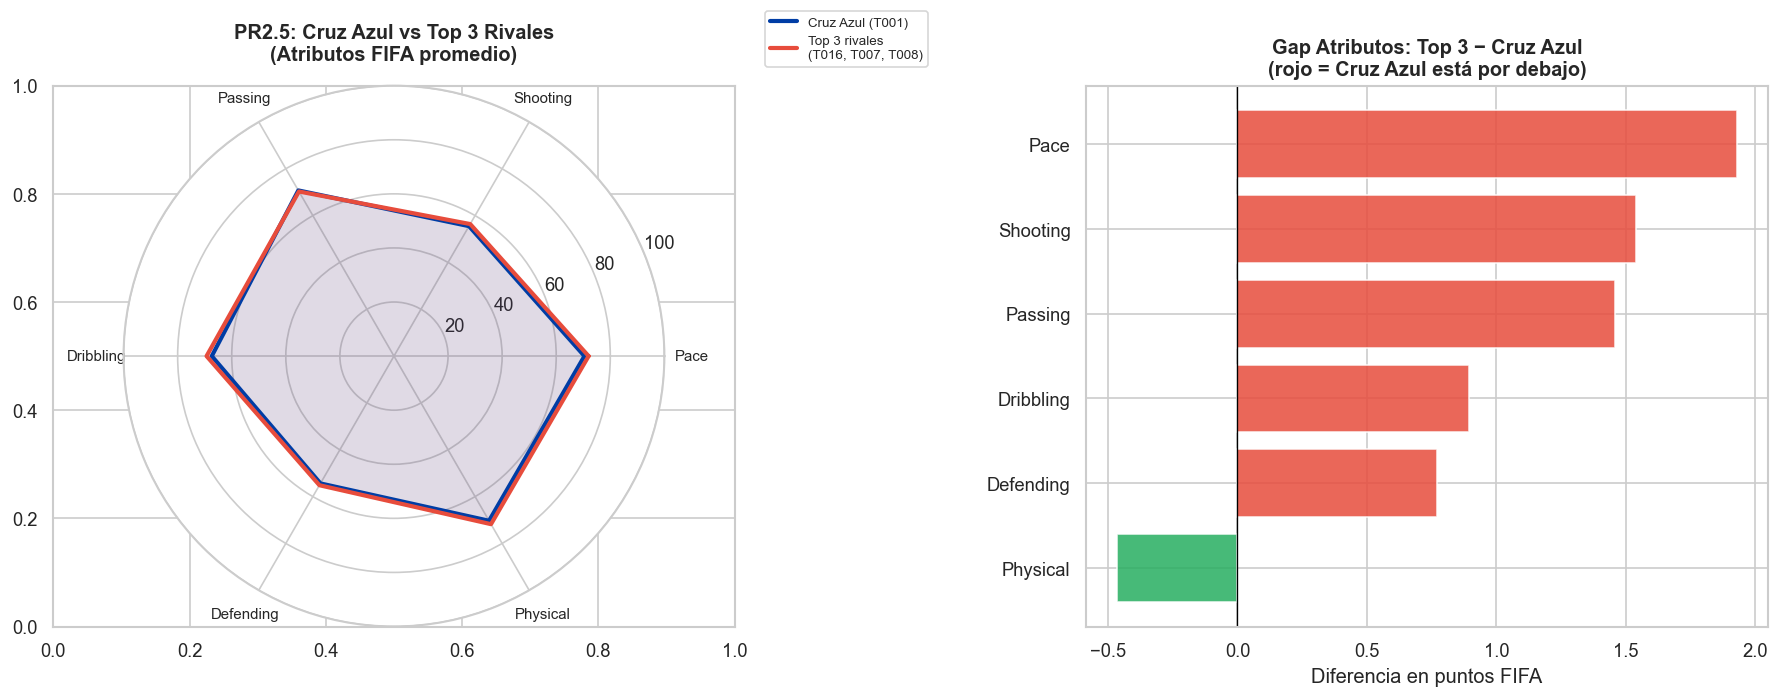

=== PR2.5: GAP ATRIBUTOS FIFA — CRUZ AZUL vs TOP 3 RIVALES ===
Top 3 rivales por overall: ['T016', 'T007', 'T008']

Cruz Azul overall promedio: N/A


,Cruz Azul,Top 3,Gap (Top3-CA)
Pace,70.44,71.98,1.93
Shooting,55.49,56.39,1.54
Passing,70.75,70.29,1.46
Dribbling,67.38,69.31,0.89
Defending,54.37,55.14,0.77
Physical,70.32,71.77,-0.46



Atributo con mayor brecha: Pace (1.93 pts)
PRESCRIPCIÓN: Cruz Azul debe priorizar la incorporación de jugadores con alto Pace y los demás atributos por encima de la media de la liga.


In [67]:
d25 = df_json[df_json['equipo_id'].notna()].copy()
d25['grupo'] = d25['posicion'].apply(pos_grupo)

# Overall promedio por equipo
eq_overall = (d25.groupby('equipo_id')['fifa_overall'].mean().sort_values(ascending=False).reset_index())
top3_rivales = eq_overall[eq_overall['equipo_id'] != 'T001'].head(3)['equipo_id'].tolist()

ca_mean = d25[d25['equipo_id'] == 'T001'][fifa_attrs].mean()
top_mean = d25[d25['equipo_id'].isin(top3_rivales)][fifa_attrs].mean()
gap = (top_mean - ca_mean).sort_values(ascending=False)
gap.index = attr_labels

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Radar comparativo
angles25 = np.linspace(0, 2 * np.pi, len(attr_labels), endpoint=False).tolist() + [0]
vals_ca = ca_mean.tolist()  + [ca_mean.tolist()[0]]
vals_top = top_mean.tolist() + [top_mean.tolist()[0]]

ax_r25 = plt.subplot(1, 2, 1, polar=True)
ax_r25.plot(angles25, vals_ca, color='#003DA5', lw=2.5, label='Cruz Azul (T001)')
ax_r25.fill(angles25, vals_ca, color='#003DA5', alpha=0.12)
ax_r25.plot(angles25, vals_top, color='#E74C3C', lw=2.5, label=f'Top 3 rivales\n({", ".join(top3_rivales)})')
ax_r25.fill(angles25, vals_top, color='#E74C3C', alpha=0.08)
ax_r25.set_xticks(angles25[:-1])
ax_r25.set_xticklabels(attr_labels, fontsize=9)
ax_r25.set_ylim(0, 100)
ax_r25.set_title('PR2.5: Cruz Azul vs Top 3 Rivales\n(Atributos FIFA promedio)', fontweight='bold', pad=15)
ax_r25.legend(loc='upper right', bbox_to_anchor=(1.5, 1.15), fontsize=8)

# Gap por atributo
ax2 = plt.subplot(1, 2, 2)
gap_colors = ['#E74C3C' if g > 0 else '#27AE60' for g in gap.values]
ax2.barh(gap.index[::-1], gap.values[::-1], color=gap_colors[::-1], alpha=0.85)
ax2.axvline(0, color='black', lw=0.8)
ax2.set_title('Gap Atributos: Top 3 − Cruz Azul\n(rojo = Cruz Azul está por debajo)', fontweight='bold')
ax2.set_xlabel('Diferencia en puntos FIFA')

plt.tight_layout()
plt.show()

print('=== PR2.5: GAP ATRIBUTOS FIFA — CRUZ AZUL vs TOP 3 RIVALES ===')
print(f'Top 3 rivales por overall: {top3_rivales}')
_ca_ovr_val = ca_mean['fifa_overall'] if ('fifa_overall' in ca_mean.index and 'fifa_overall' in d25.columns) else None
print(f'\nCruz Azul overall promedio: {_ca_ovr_val:.1f}' if _ca_ovr_val is not None else '\nCruz Azul overall promedio: N/A')
gap_df = pd.DataFrame({'Cruz Azul': ca_mean.values, 'Top 3': top_mean.values, 'Gap (Top3-CA)': gap.values}, index=attr_labels)
display(gap_df.round(2))

mayor_gap = gap.idxmax()
print(f'\nAtributo con mayor brecha: {mayor_gap} ({gap.max():.2f} pts)')
print(f'PRESCRIPCIÓN: Cruz Azul debe priorizar la incorporación de jugadores con alto {mayor_gap} y los demás atributos por encima de la media de la liga.')

---
### D3.1 — Ranking de equipos por Overall (OVR) promedio en el scouting
> **Método:** Agrupamos por `EQUIPO`, calculamos media y desviación del OVR. IEsto nos permite identificar si Cruz Azul está por encima o debajo del promedio de la liga. 

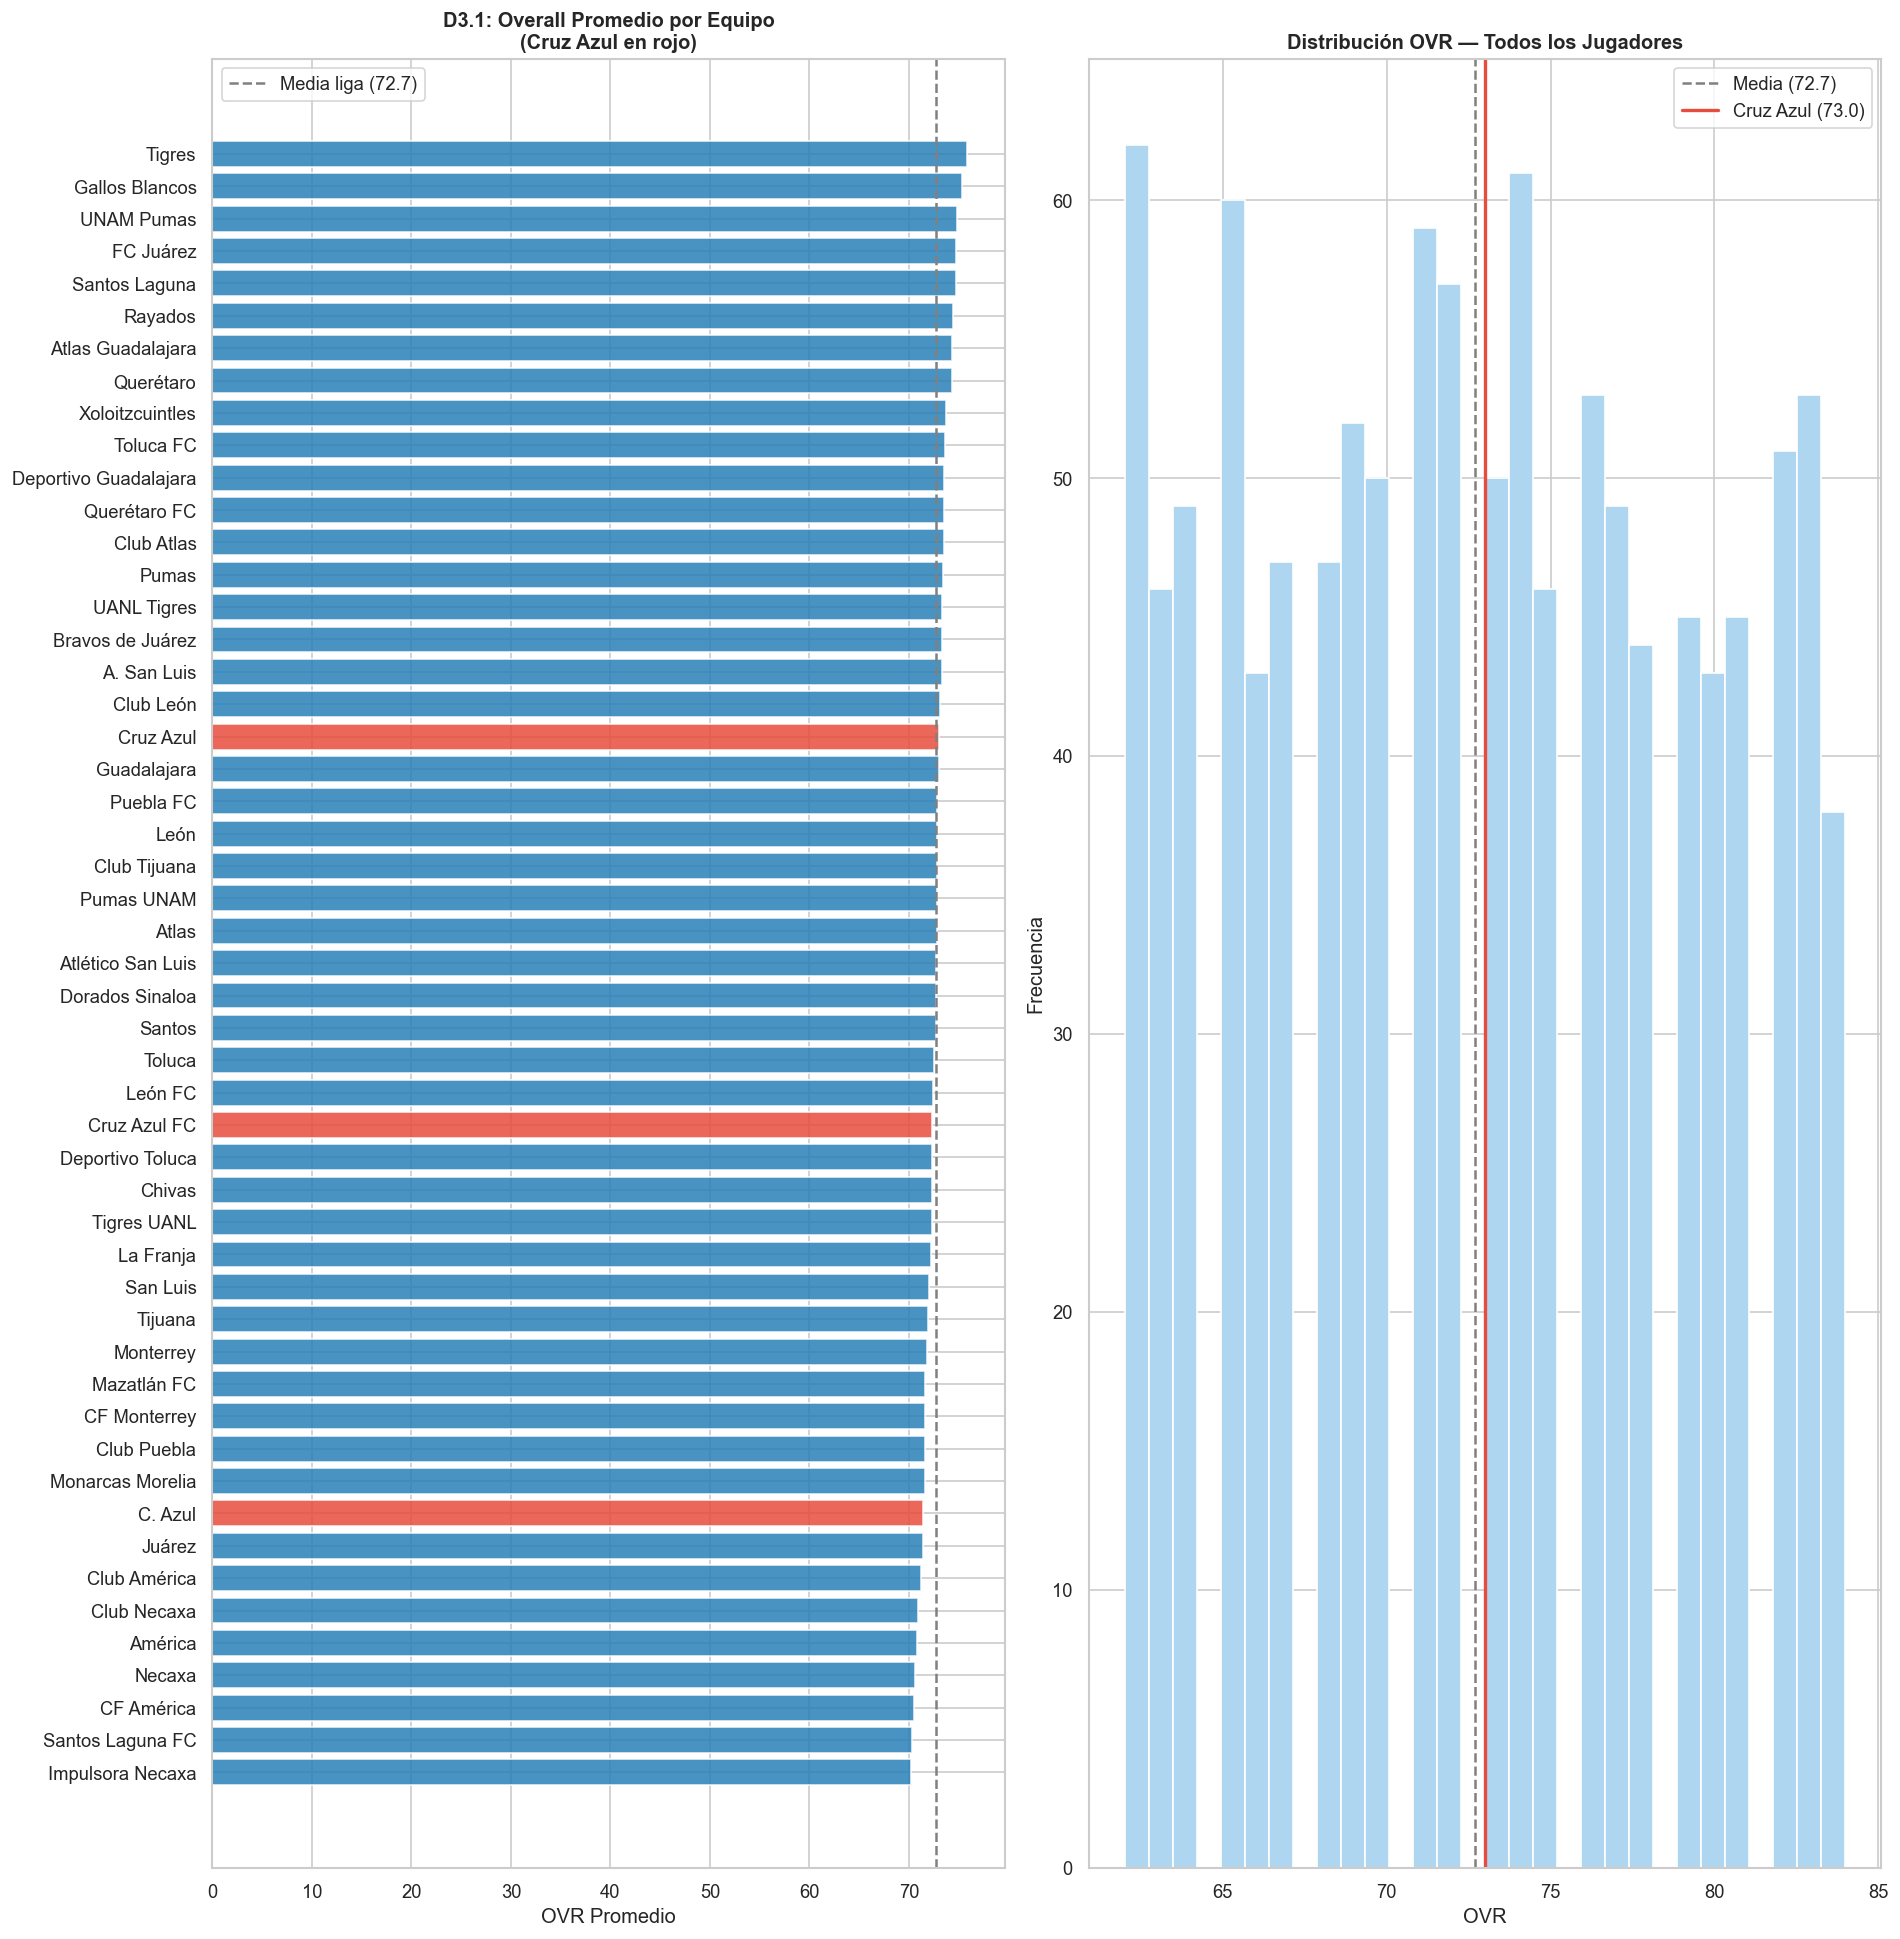

=== D3.1: TOP 15 EQUIPOS POR OVR PROMEDIO (SCOUTING) ===


,equipo,ovr_mean,ovr_std,n
0,Tigres,75.87,7.32,15
1,Gallos Blancos,75.30,6.70,30
2,UNAM Pumas,74.86,5.77,21
3,FC Juárez,74.71,7.08,28
4,Santos Laguna,74.68,5.74,28
5,Rayados,74.45,5.55,22
6,Atlas Guadalajara,74.36,7.06,22
7,Querétaro,74.36,8.02,14
8,Xoloitzcuintles,73.70,5.76,23
9,Toluca FC,73.59,6.25,17



Cruz Azul — OVR promedio: 73.0 | Posición: #19 de 51 equipos


In [68]:
# Identificar columna de equipo  
equipo_col = 'EQUIPO' if 'EQUIPO' in df_scouting.columns else None
ovr_col = 'OVR' if 'OVR' in df_scouting.columns else None

if equipo_col and ovr_col:
    sc_eq = df_scouting[[equipo_col, ovr_col]].dropna()
    eq_ovr = sc_eq.groupby(equipo_col)[ovr_col].agg(['mean', 'std', 'count']).reset_index()
    eq_ovr.columns = ['equipo', 'ovr_mean', 'ovr_std', 'n']
    eq_ovr = eq_ovr[eq_ovr['n'] >= 3].sort_values('ovr_mean', ascending=False).reset_index(drop=True)

    media_liga = sc_eq[ovr_col].mean()
    ca_mask = eq_ovr['equipo'].str.contains('Cruz|Azul|C\.Azul', case=False, na=False)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, max(6, len(eq_ovr) * 0.32)))

    colors31 = ['#E74C3C' if m else '#2980B9' for m in ca_mask]
    ax1.barh(eq_ovr['equipo'][::-1], eq_ovr['ovr_mean'][::-1], color=colors31[::-1], alpha=0.85)
    ax1.axvline(media_liga, color='gray', ls='--', lw=1.5, label=f'Media liga ({media_liga:.1f})')
    ax1.set_title('D3.1: Overall Promedio por Equipo\n(Cruz Azul en rojo)', fontweight='bold')
    ax1.set_xlabel('OVR Promedio')
    ax1.legend()

    # Distribución del OVR general
    ax2.hist(sc_eq[ovr_col].dropna(), bins=30, color='#AED6F1', edgecolor='white')
    ax2.axvline(media_liga, color='gray', ls='--', lw=1.5, label=f'Media ({media_liga:.1f})')
    if ca_mask.any():
        ca_ovr = eq_ovr.loc[ca_mask, 'ovr_mean'].values[0]
        ax2.axvline(ca_ovr, color='#E74C3C', ls='-', lw=2, label=f'Cruz Azul ({ca_ovr:.1f})')
    ax2.set_title('Distribución OVR — Todos los Jugadores', fontweight='bold')
    ax2.set_xlabel('OVR'); ax2.set_ylabel('Frecuencia')
    ax2.legend()

    plt.tight_layout()
    plt.show()

    print('=== D3.1: TOP 15 EQUIPOS POR OVR PROMEDIO (SCOUTING) ===')
    display(eq_ovr.head(15).round(2))
    if ca_mask.any():
        ca_rank = eq_ovr[ca_mask].index[0] + 1
        print(f'\nCruz Azul — OVR promedio: {ca_ovr:.1f} | Posición: #{ca_rank} de {len(eq_ovr)} equipos')
else:
    print('Columnas EQUIPO/OVR no encontradas. Columnas disponibles:', df_scouting.columns.tolist())

---
### D3.2 — Distribución de G+A/90 por posición y por origen (EXT vs NAC)
> **Método:** Generamos boxplots de G+A/90 por posición. Comparamos medias entre extranjeros (EXT=SÍ) y nacionales.  

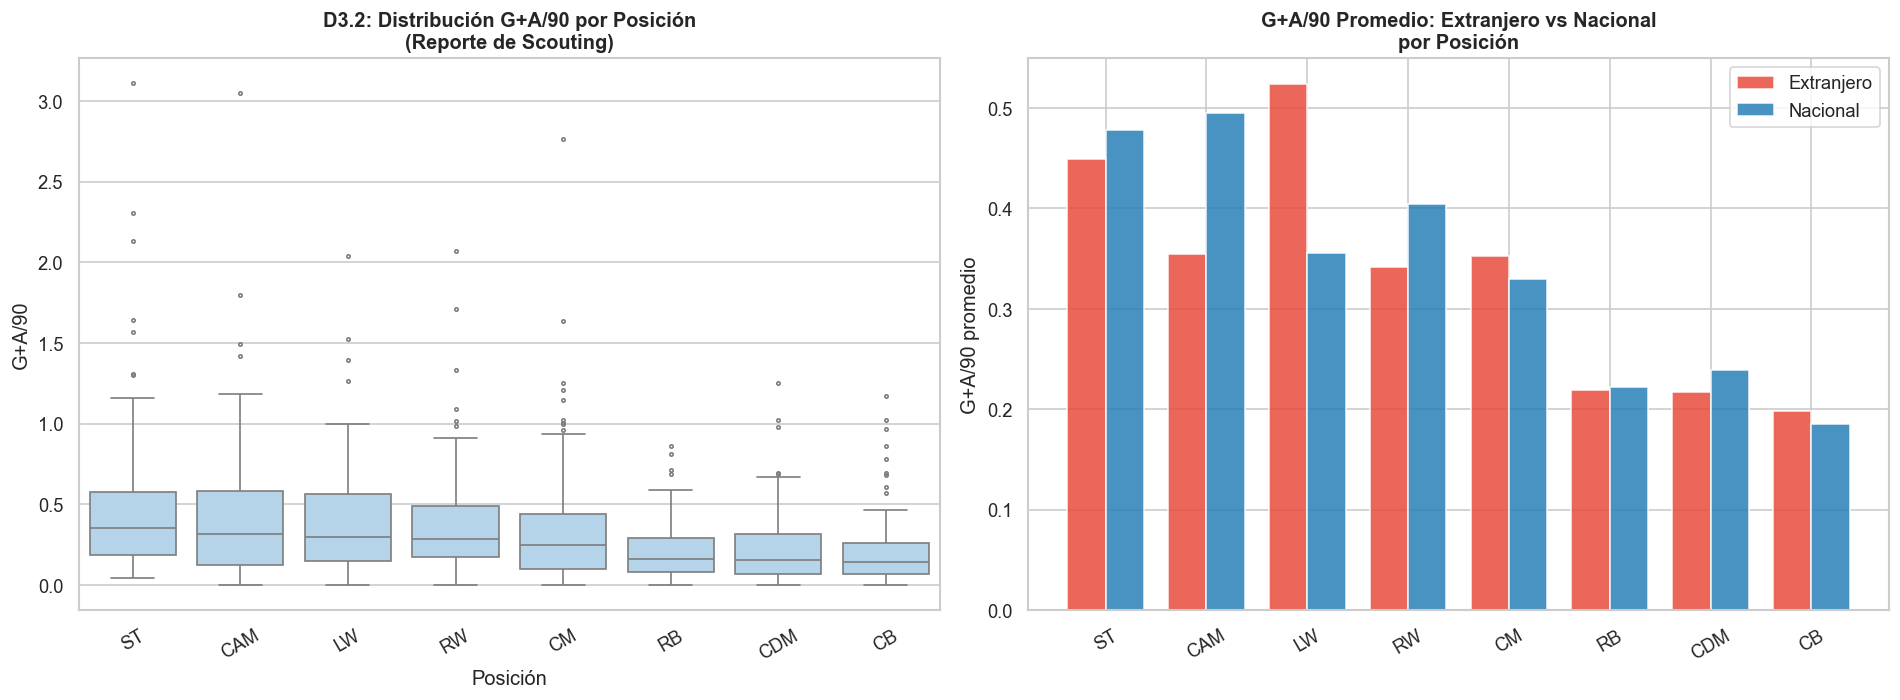

=== D3.2: G+A/90 PROMEDIO POR POSICIÓN ===


,mean,median,std,count
POS,,,,
CAM,0.441,0.314,0.482,73
CB,0.191,0.140,0.205,146
CDM,0.231,0.158,0.239,98
CM,0.340,0.247,0.352,158
LW,0.409,0.298,0.361,88
RB,0.221,0.163,0.193,79
RW,0.384,0.288,0.349,88
ST,0.468,0.352,0.451,127



=== TEST MANN-WHITNEY U: Extranjero vs Nacional en G+A/90 ===
Extranjero media: 0.320 | Nacional media: 0.337
U=83674.0, p=0.3382 ->  Sin diferencia significativa


In [69]:
ga_col  = 'G_A_90' if 'G_A_90' in df_scouting.columns else None
pos_col = 'POS' if 'POS' in df_scouting.columns else None
ext_col = 'EXT' if 'EXT' in df_scouting.columns else None

if ga_col and pos_col:
    sc32 = df_scouting[[pos_col, ga_col]].dropna().copy()
    if ext_col:
        sc32['ext'] = df_scouting[ext_col].apply(lambda x: 'Extranjero' if isinstance(x, str) and x.strip().upper().startswith('S') else 'Nacional')
    else:
        sc32['ext'] = 'Nacional'

    # Top 8 posiciones
    top_pos32 = sc32[pos_col].value_counts().head(8).index.tolist()
    sc32 = sc32[sc32[pos_col].isin(top_pos32)]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Boxplot por posición
    order32 = sc32.groupby(pos_col)[ga_col].median().sort_values(ascending=False).index.tolist()
    sns.boxplot(data=sc32, x=pos_col, y=ga_col, order=order32, color='#AED6F1', fliersize=2, ax=ax1)
    ax1.set_title('D3.2: Distribución G+A/90 por Posición\n(Reporte de Scouting)', fontweight='bold')
    ax1.set_xlabel('Posición'); ax1.set_ylabel('G+A/90')
    ax1.tick_params(axis='x', rotation=30)

    # Comparativa Extranjero vs Nacional por posición
    if ext_col:
        ga_ext = sc32.groupby(['ext'])[ga_col].agg(['mean', 'median', 'count'])
        ga_pos_ext = sc32.groupby([pos_col, 'ext'])[ga_col].mean().unstack(fill_value=0)
        if 'Extranjero' in ga_pos_ext.columns and 'Nacional' in ga_pos_ext.columns:
            x32 = np.arange(len(order32))
            w32 = 0.38
            ax2.bar(x32 - w32/2, [ga_pos_ext.loc[p, 'Extranjero'] if p in ga_pos_ext.index else 0 for p in order32], w32, label='Extranjero', color='#E74C3C', alpha=0.85)
            ax2.bar(x32 + w32/2, [ga_pos_ext.loc[p, 'Nacional'] if p in ga_pos_ext.index else 0 for p in order32], w32, label='Nacional', color='#2980B9', alpha=0.85)
            ax2.set_xticks(x32)
            ax2.set_xticklabels(order32, rotation=30)
            ax2.set_title('G+A/90 Promedio: Extranjero vs Nacional\npor Posición', fontweight='bold')
            ax2.set_ylabel('G+A/90 promedio'); ax2.legend()

    plt.tight_layout()
    plt.show()

    print('=== D3.2: G+A/90 PROMEDIO POR POSICIÓN ===')
    display(sc32.groupby(pos_col)[ga_col].agg(['mean', 'median', 'std', 'count']).round(3))

    if ext_col:
        from scipy.stats import mannwhitneyu
        ext_vals = sc32[sc32['ext'] == 'Extranjero'][ga_col].dropna()
        nac_vals = sc32[sc32['ext'] == 'Nacional'][ga_col].dropna()
        stat, pval = mannwhitneyu(ext_vals, nac_vals, alternative='two-sided')
        print(f'\n=== TEST MANN-WHITNEY U: Extranjero vs Nacional en G+A/90 ===')
        print(f'Extranjero media: {ext_vals.mean():.3f} | Nacional media: {nac_vals.mean():.3f}')
        print(f'U={stat:.1f}, p={pval:.4f} -> ', 'Diferencia significativa' if pval < 0.05 else 'Sin diferencia significativa')
else:
    print('Columnas POS/G_A_90 no encontradas. Disponibles:', df_scouting.columns.tolist())

---
### D3.3 — ¿Hay correlación entre minutos jugados (MINS) y producción ofensiva (G+A/90)?
> **Método:** Generamos un scatter entre MINS y G+A/90 con regresión lineal. Calcularmos la correlación de Pearson y Spearman. Segmentamos por posición para ver si el patrón es consistente.  

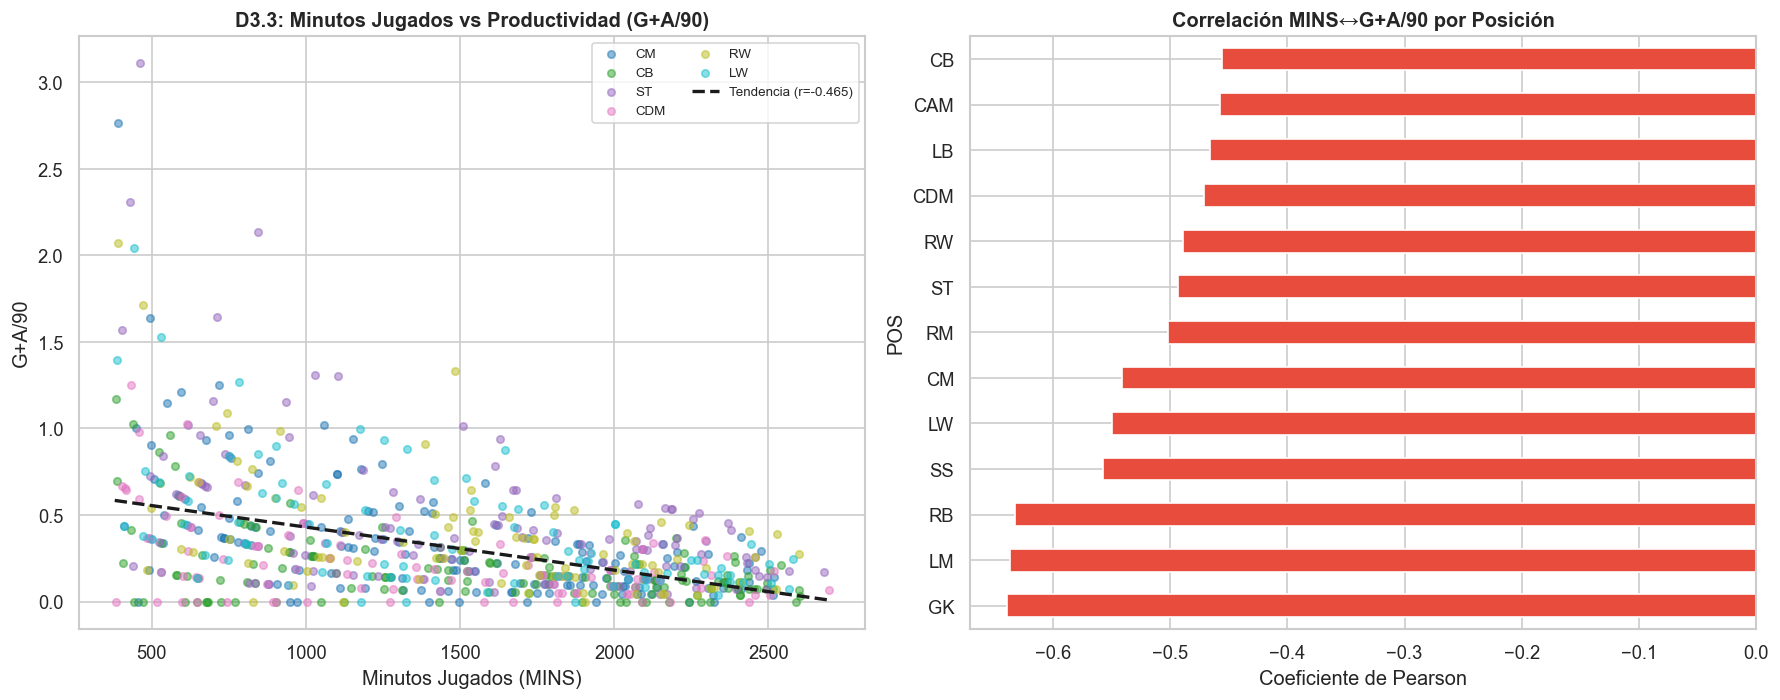

=== D3.3: CORRELACIÓN GLOBAL MINS vs G+A/90 ===
Pearson  r = -0.4649  (p=0.0000)
Spearman r = -0.4640 (p=0.0000)

Correlación NEGATIVA y significativa (α=0.05)
	Jugadores con más minutos tienden a tener MENOR G+A/90 (posiblemente más defensivos).


In [70]:
mins_col = 'MINS' if 'MINS' in df_scouting.columns else None

if mins_col and ga_col and pos_col:
    sc33 = df_scouting[[mins_col, ga_col, pos_col]].dropna().copy()
    sc33 = sc33[(sc33[mins_col] > 0) & (sc33[ga_col] >= 0)]

    from scipy.stats import pearsonr, spearmanr
    r_pear, p_pear = pearsonr(sc33[mins_col], sc33[ga_col])
    r_spear, p_spear = spearmanr(sc33[mins_col], sc33[ga_col])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # Tendencias
    top_pos33 = sc33[pos_col].value_counts().head(6).index.tolist()
    sc33_top  = sc33[sc33[pos_col].isin(top_pos33)]
    cmap33 = plt.cm.get_cmap('tab10', len(top_pos33))
    for i, pos in enumerate(top_pos33):
        sub = sc33_top[sc33_top[pos_col] == pos]
        ax1.scatter(sub[mins_col], sub[ga_col], alpha=0.5, s=20, color=cmap33(i), label=pos)
    # Línea de tendencia global
    z33 = np.polyfit(sc33[mins_col], sc33[ga_col], 1)
    x33 = np.linspace(sc33[mins_col].min(), sc33[mins_col].max(), 200)
    ax1.plot(x33, np.poly1d(z33)(x33), 'k--', lw=2, label=f'Tendencia (r={r_pear:.3f})')
    ax1.set_xlabel('Minutos Jugados (MINS)')
    ax1.set_ylabel('G+A/90')
    ax1.set_title('D3.3: Minutos Jugados vs Productividad (G+A/90)', fontweight='bold')
    ax1.legend(fontsize=8, ncol=2)

    # Correlación por posición
    corr_pos = sc33.groupby(pos_col).apply(
        lambda g: g[[mins_col, ga_col]].corr().iloc[0, 1] if len(g) > 5 else np.nan
    ).dropna().sort_values()

    corr_pos.plot(kind='barh', ax=ax2, color=['#E74C3C' if c < 0 else '#27AE60' for c in corr_pos.values])
    ax2.axvline(0, color='black', lw=0.8)
    ax2.set_title('Correlación MINS↔G+A/90 por Posición', fontweight='bold')
    ax2.set_xlabel('Coeficiente de Pearson')

    plt.tight_layout()
    plt.show()

    print('=== D3.3: CORRELACIÓN GLOBAL MINS vs G+A/90 ===')
    print(f'Pearson  r = {r_pear:.4f}  (p={p_pear:.4f})')
    print(f'Spearman r = {r_spear:.4f} (p={p_spear:.4f})')
    print(f'\nCorrelación {"POSITIVA" if r_pear > 0 else "NEGATIVA"} y {"significativa" if p_pear < 0.05 else "NO significativa"} (α=0.05)')

    if p_pear < 0.05 and r_pear > 0:
        print('\tLos jugadores con más minutos tienden a tener mayor G+A/90.')
    elif p_pear < 0.05 and r_pear < 0:
        print('\tJugadores con más minutos tienden a tener MENOR G+A/90 (posiblemente más defensivos).')
    else:
        print('\tNo hay evidencia estadística de correlación lineal.')
else:
    print('Columnas MINS/G_A_90/POS no disponibles:', df_scouting.columns.tolist())

---
### P3.4 — ¿Se puede predecir el G+A/90 de un jugador con OVR, posición, edad y origen?
> **Método:** Usamos Gradient Boosting Regressor, con Target: G+A/90. Features: OVR, posición codificada, EDAD, EXT binario.  

=== P3.4: PREDICCIÓN G+A/90 — GRADIENT BOOSTING (SCOUTING) ===
RMSE : 0.3664
R²: -0.2246


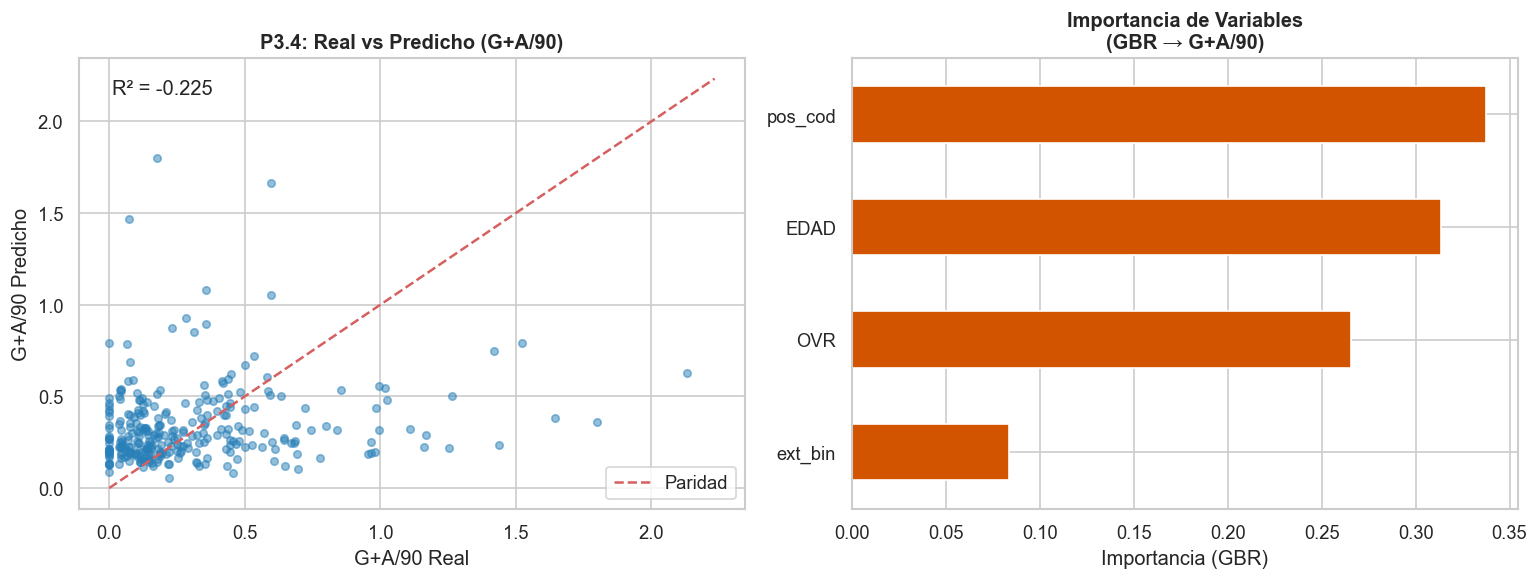


Residual promedio por posición (+ = modelo sub-predice):


,mean,std
posicion,,
CAM,-0.059,0.649
CB,0.001,0.308
CDM,0.085,0.320
CM,-0.067,0.288
GK,-0.113,0.398
LB,-0.131,0.395
LM,-0.096,0.412
LW,0.021,0.354
RB,0.031,0.436


In [71]:
edad_col = 'EDAD' if 'EDAD' in df_scouting.columns else None

if ovr_col and ga_col and pos_col and edad_col:
    sc34 = df_scouting[[ovr_col, ga_col, pos_col, edad_col]].copy()
    if ext_col:
        sc34['ext_bin'] = df_scouting[ext_col].map({'SÍ': 1, 'SI': 1, 'NO': 0}).fillna(0)
    else:
        sc34['ext_bin'] = 0
    sc34 = sc34.dropna(subset=[ovr_col, ga_col, edad_col])
    sc34 = sc34[(sc34[ga_col] >= 0) & (sc34[ga_col] < 5)]  # quitar outliers extremos

    le34 = LabelEncoder()
    sc34['pos_cod'] = le34.fit_transform(sc34[pos_col].fillna('UNK'))

    feats34 = [ovr_col, edad_col, 'pos_cod', 'ext_bin']
    X34 = sc34[feats34].values
    y34 = sc34[ga_col].values

    X34_tr, X34_te, y34_tr, y34_te = train_test_split(X34, y34, test_size=0.25, random_state=42)
    gbr34 = GradientBoostingRegressor(n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42)
    gbr34.fit(X34_tr, y34_tr)
    y34_pred = gbr34.predict(X34_te)

    rmse34 = np.sqrt(mean_squared_error(y34_te, y34_pred))
    r2_34 = r2_score(y34_te, y34_pred)

    print('=== P3.4: PREDICCIÓN G+A/90 — GRADIENT BOOSTING (SCOUTING) ===')
    print(f'RMSE : {rmse34:.4f}')
    print(f'R²: {r2_34:.4f}')

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

    ax1.scatter(y34_te, y34_pred, alpha=0.5, s=20, color='#2980B9')
    lim34 = max(y34_te.max(), y34_pred.max()) + 0.1
    ax1.plot([0, lim34], [0, lim34], 'r--', lw=1.5, label='Paridad')
    ax1.set_xlabel('G+A/90 Real'); ax1.set_ylabel('G+A/90 Predicho')
    ax1.set_title('P3.4: Real vs Predicho (G+A/90)', fontweight='bold')
    ax1.text(0.05, 0.92, f'R² = {r2_34:.3f}', transform=ax1.transAxes)
    ax1.legend()

    imp34 = pd.Series(gbr34.feature_importances_, index=feats34).sort_values()
    imp34.plot(kind='barh', ax=ax2, color='#D35400')
    ax2.set_title('Importancia de Variables\n(GBR → G+A/90)', fontweight='bold')
    ax2.set_xlabel('Importancia (GBR)')

    plt.tight_layout()
    plt.show()

    # Residuales por posición
    sc34_te = sc34.iloc[X34_te.shape[0] * 0 :].copy()
    resid = pd.DataFrame({'real': y34_te, 'pred': y34_pred,
                          'residual': y34_te - y34_pred,
                          'pos_cod': sc34.iloc[len(X34_tr):]['pos_cod'].values})
    resid['posicion'] = le34.inverse_transform(resid['pos_cod'].astype(int))
    resid_pos = resid.groupby('posicion')['residual'].agg(['mean', 'std']).round(3)
    print('\nResidual promedio por posición (+ = modelo sub-predice):')
    display(resid_pos)
else:
    print('Columnas necesarias no disponibles:', df_scouting.columns.tolist())

---
### PR3.5 — ¿Qué jugadores del scouting tienen la mejor relación calidad-precio?
> **Método:** Calculamos un índice compuesto = 60 % G+A/90 normalizado − 40 % MVAL_EUR normalizado. Posteriormente, filtramos jugadores que NO sean de Cruz Azul, y seleccionamos el top 10 candidatos como fichajes de alta eficiencia.

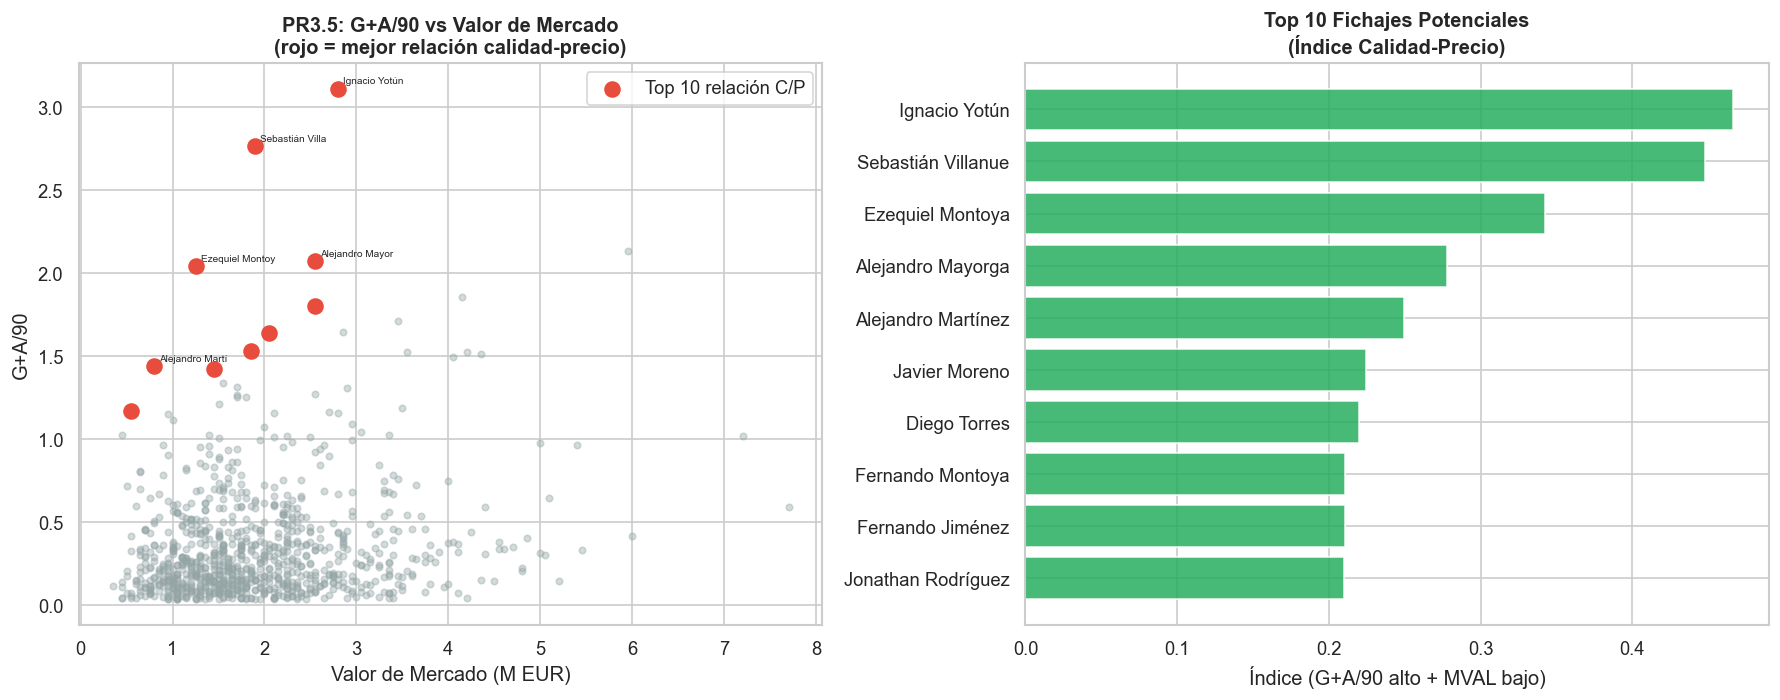

=== PR3.5: TOP 10 FICHAJES POTENCIALES — MEJOR RELACIÓN CALIDAD-PRECIO ===
(Excluye jugadores de Cruz Azul; considera solo G+A/90 > 0 y MVAL conocido)



,NOMBRE_TM,EQUIPO,POS,G_A_90,MVAL(M),Índice C/P
859,Ignacio Yotún,Gallos Blancos,ST,3.110,2.80,0.467
188,Sebastián Villanue,Chivas,CM,2.762,1.90,0.448
74,Ezequiel Montoya,Club América,LW,2.041,1.25,0.342
951,Alejandro Mayorga,Tigres UANL,RW,2.072,2.55,0.278
1080,Alejandro Martínez,Club Necaxa,GK,1.438,0.80,0.249
983,Javier Moreno,Club Atlas,CAM,1.800,2.55,0.225
166,Diego Torres,Atlas Guadalajara,CM,1.636,2.05,0.220
291,Fernando Montoya,Santos,CAM,1.421,1.45,0.211
978,Fernando Jiménez,Puebla FC,CB,1.169,0.55,0.210
148,Jonathan Rodríguez,América,LW,1.528,1.85,0.210



PRESCRIPCIÓN: Estos jugadores maximizan el rendimiento ofensivo por euro invertido.
Son candidatos prioritarios para el mercado de fichajes en el siguiente período.


In [73]:
mval_col = 'MVAL_EUR' if 'MVAL_EUR' in df_scouting.columns else None
nombre_col = 'NOMBRE_TM'  if 'NOMBRE_TM'  in df_scouting.columns else None

if ga_col and mval_col and nombre_col:
    sc35 = df_scouting[[nombre_col, equipo_col or 'TEMP           EQUIPO', pos_col, ga_col, mval_col, ovr_col or 'OVR']].dropna(subset=[ga_col, mval_col]).copy()
    sc35 = sc35[(sc35[mval_col] > 0) & (sc35[ga_col] > 0)].copy()

    # Excluir jugadores de Cruz Azul
    if equipo_col:
        sc35 = sc35[~sc35[equipo_col].str.contains('Cruz|Azul', case=False, na=False)]

    sc_mm = MinMaxScaler()
    sc35['ga_n']   = sc_mm.fit_transform(sc35[[ga_col]])
    sc35['vm_n']   = sc_mm.fit_transform(sc35[[mval_col]])
    sc35['indice_cp'] = sc35['ga_n'] * 0.60 - sc35['vm_n'] * 0.40

    top10_cp = sc35.nlargest(10, 'indice_cp')

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    ax1.scatter(sc35[mval_col] / 1e6, sc35[ga_col], alpha=0.4, s=15, color='#95A5A6')
    ax1.scatter(top10_cp[mval_col] / 1e6, top10_cp[ga_col], color='#E74C3C', s=80, zorder=5, label='Top 10 relación C/P')
    ax1.set_xlabel('Valor de Mercado (M EUR)')
    ax1.set_ylabel('G+A/90')
    ax1.set_title('PR3.5: G+A/90 vs Valor de Mercado\n(rojo = mejor relación calidad-precio)', fontweight='bold')
    ax1.legend()
    for _, row in top10_cp.head(5).iterrows():
        ax1.annotate(str(row[nombre_col])[:15], (row[mval_col] / 1e6, row[ga_col]), fontsize=6, ha='left', xytext=(3, 3), textcoords='offset points')

    # Top 10 barras de índice
    top10_sorted = top10_cp.sort_values('indice_cp')
    ax2.barh(top10_sorted[nombre_col].astype(str), top10_sorted['indice_cp'], color='#27AE60', alpha=0.85)
    ax2.set_title('Top 10 Fichajes Potenciales\n(Índice Calidad-Precio)', fontweight='bold')
    ax2.set_xlabel('Índice (G+A/90 alto + MVAL bajo)')

    plt.tight_layout()
    plt.show()

    print('=== PR3.5: TOP 10 FICHAJES POTENCIALES — MEJOR RELACIÓN CALIDAD-PRECIO ===')
    print('(Excluye jugadores de Cruz Azul; considera solo G+A/90 > 0 y MVAL conocido)\n')
    cols_disp = [nombre_col, equipo_col or 'EQUIPO', pos_col, ga_col, mval_col, 'indice_cp']
    cols_disp = [c for c in cols_disp if c in top10_cp.columns]
    disp35 = top10_cp[cols_disp].copy()
    disp35[mval_col] = (disp35[mval_col] / 1e6).round(2)
    disp35.columns = [c.replace(mval_col, 'MVAL(M)').replace('indice_cp', 'Índice C/P') for c in disp35.columns]
    display(disp35.round(3))
    print('\nPRESCRIPCIÓN: Estos jugadores maximizan el rendimiento ofensivo por euro invertido.')
    print('Son candidatos prioritarios para el mercado de fichajes en el siguiente período.')
else:
    print('Columnas necesarias no encontradas:', df_scouting.columns.tolist())

---
### D4.1 — ¿Qué equipos concentran jugadores con doble nacionalidad y cómo rinden?
> **Método:** Contamos jugadores con `doble_nac=True` por equipo. Comparamos `goles_casa + goles_fuera` entre jugadores con y sin doble nacionalidad.  


Columnas detectadas:
doble_nac=doble_nac, equipo=equipo
goles_casa=goles_casa, goles_fuera=goles_fuera
p_casa=p_casa, p_fuera=p_fuera
tarj_am=tarj_am, tarj_roj=tarj_roj

Goles promedio — Doble Nac.: 1.639 | Sin: 0.000


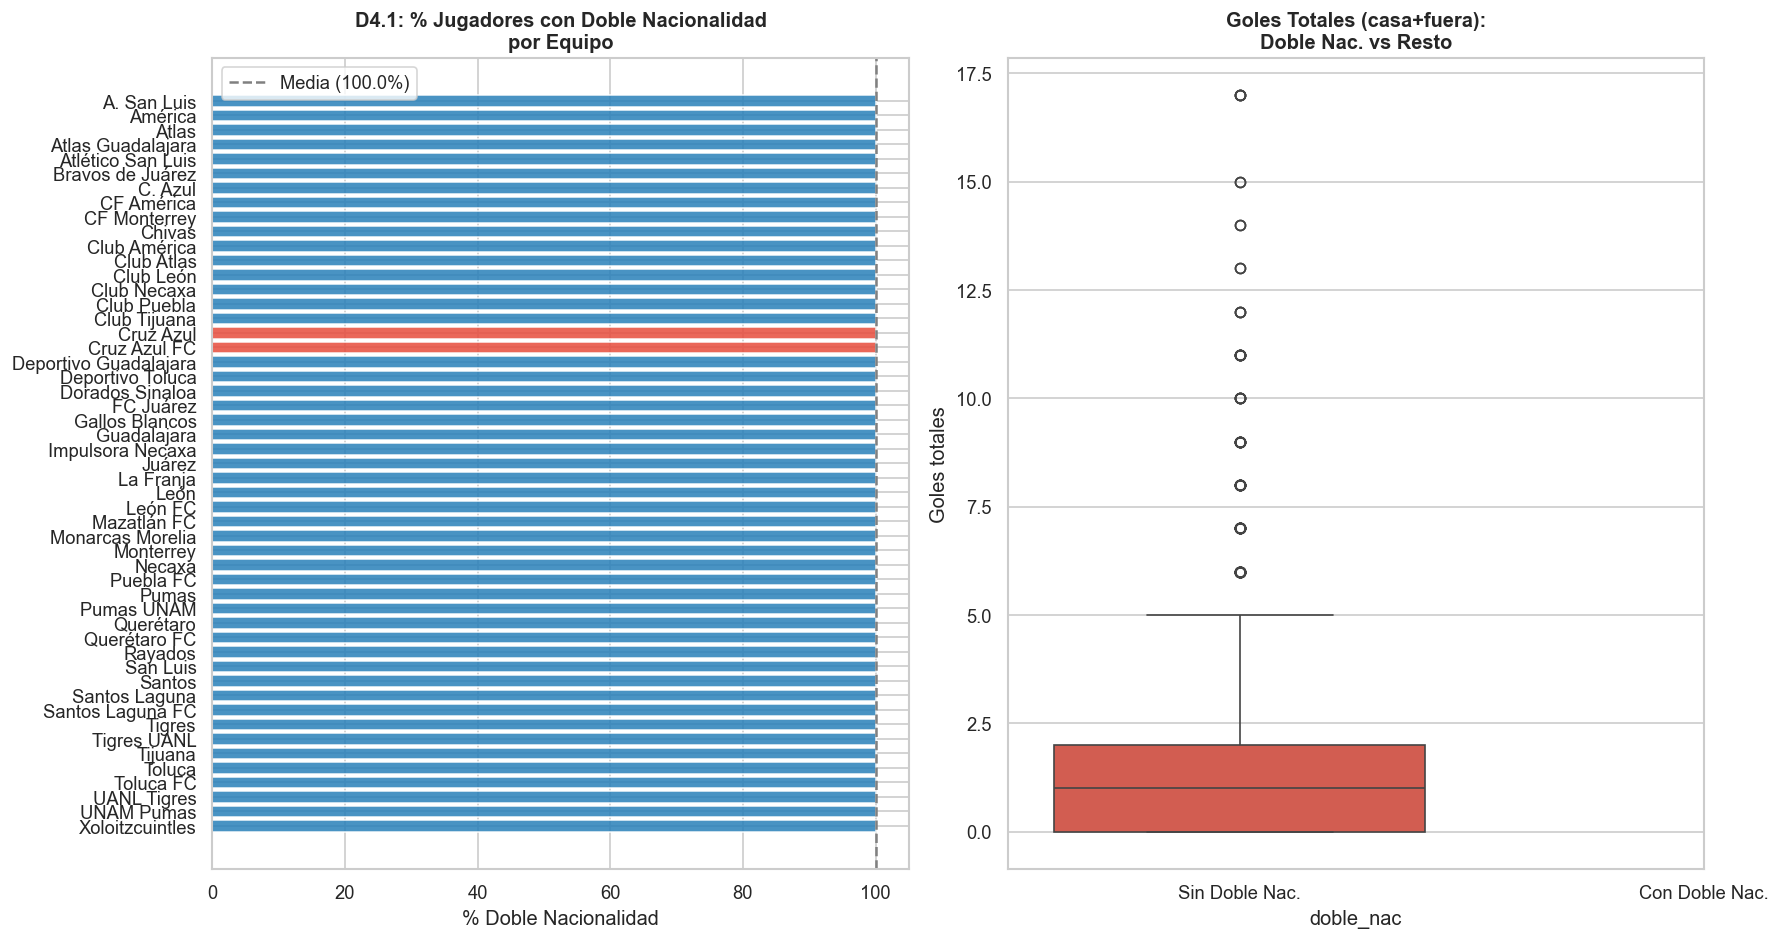


=== D4.1: TOP 10 EQUIPOS CON MAYOR % DOBLE NACIONALIDAD ===


,equipo,doble,total,pct_doble
0,A. San Luis,23,23,100.0
1,América,18,18,100.0
2,Atlas,11,11,100.0
3,Atlas Guadalajara,22,22,100.0
4,Atlético San Luis,16,16,100.0
5,Bravos de Juárez,25,25,100.0
6,C. Azul,21,21,100.0
7,CF América,18,18,100.0
8,CF Monterrey,16,16,100.0
9,Chivas,21,21,100.0


In [ ]:
# Detectar columnas clave
col_doble = next((c for c in df_xlsx.columns if 'doble' in c.lower()), None)
col_equipo_x = next((c for c in df_xlsx.columns if 'equipo' in c.lower()), None)
col_gc = next((c for c in df_xlsx.columns if 'goles_casa' in c.lower()), None)
col_gf = next((c for c in df_xlsx.columns if 'goles_fuera' in c.lower()), None)
col_pc = next((c for c in df_xlsx.columns if c.lower() in ['p_casa', 'partidos_casa']), None)
col_pf = next((c for c in df_xlsx.columns if c.lower() in ['p_fuera', 'partidos_fuera']), None)
col_tam = next((c for c in df_xlsx.columns if 'tarj' in c.lower() and 'am' in c.lower()), None)
col_troj= next((c for c in df_xlsx.columns if 'tarj' in c.lower() and 'roj' in c.lower()), None)

print(f'\nColumnas detectadas:')
print(f'doble_nac={col_doble}, equipo={col_equipo_x}')
print(f'goles_casa={col_gc}, goles_fuera={col_gf}')
print(f'p_casa={col_pc}, p_fuera={col_pf}')
print(f'tarj_am={col_tam}, tarj_roj={col_troj}')

if col_doble and col_equipo_x:
    x41 = df_xlsx[[col_equipo_x, col_doble]].dropna().copy()
    x41['doble_nac'] = x41[col_doble].astype(bool)

    # Proporción por equipo
    eq_doble = x41.groupby(col_equipo_x)['doble_nac'].agg(['sum', 'count']).reset_index()
    eq_doble.columns = ['equipo', 'doble', 'total']
    eq_doble['pct_doble'] = eq_doble['doble'] / eq_doble['total'] * 100
    eq_doble = eq_doble[eq_doble['total'] >= 5].sort_values('pct_doble', ascending=False)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 10))

    # % doble nacionalidad por equipo
    colors41 = ['#E74C3C' if 'Cruz' in str(e) or 'T001' in str(e) else '#2980B9' for e in eq_doble['equipo']]
    ax1.barh(eq_doble['equipo'][::-1], eq_doble['pct_doble'][::-1], color=colors41[::-1], alpha=0.85)
    ax1.axvline(eq_doble['pct_doble'].mean(), color='gray', ls='--', lw=1.5, label=f'Media ({eq_doble["pct_doble"].mean():.1f}%)')
    ax1.set_title('D4.1: % Jugadores con Doble Nacionalidad\npor Equipo', fontweight='bold')
    ax1.set_xlabel('% Doble Nacionalidad'); ax1.legend()

    # Goles totales: doble vs sin doble
    if col_gc and col_gf:
        x41_g = df_xlsx[[col_doble, col_gc, col_gf]].dropna().copy()
        x41_g['doble_nac'] = x41_g[col_doble].astype(bool)
        x41_g['goles_totales'] = pd.to_numeric(x41_g[col_gc], errors='coerce').fillna(0) + pd.to_numeric(x41_g[col_gf], errors='coerce').fillna(0)
        sns.boxplot(data=x41_g, x='doble_nac', y='goles_totales', palette={'True': '#E74C3C', 'False': '#2980B9'}, ax=ax2)
        ax2.set_xticks([0, 1])
        ax2.set_xticklabels(['Sin Doble Nac.', 'Con Doble Nac.'])
        ax2.set_title('Goles Totales (casa+fuera):\nDoble Nac. vs Resto', fontweight='bold')
        ax2.set_ylabel('Goles totales')

        medias = x41_g.groupby('doble_nac')['goles_totales'].mean()
        print(f'\nGoles promedio — Doble Nac.: {medias.get(True, 0):.3f} | Sin: {medias.get(False, 0):.3f}')

    plt.tight_layout()
    plt.show()

    print('\n=== D4.1: TOP 10 EQUIPOS CON MAYOR % DOBLE NACIONALIDAD ===')
    display(eq_doble.head(10).round(2))

---
### D4.2 — ¿Qué equipos acumulan más tarjetas? ¿Hay equipos con índice de disciplina crítico?
> **Método:** Sumamos `tarj_am` y `tarj_roj` por equipo. Con esto, calculamos un índice de indisciplina ponderado: amarillas + 3 × rojas. Comparamos con número de partidos totales.  

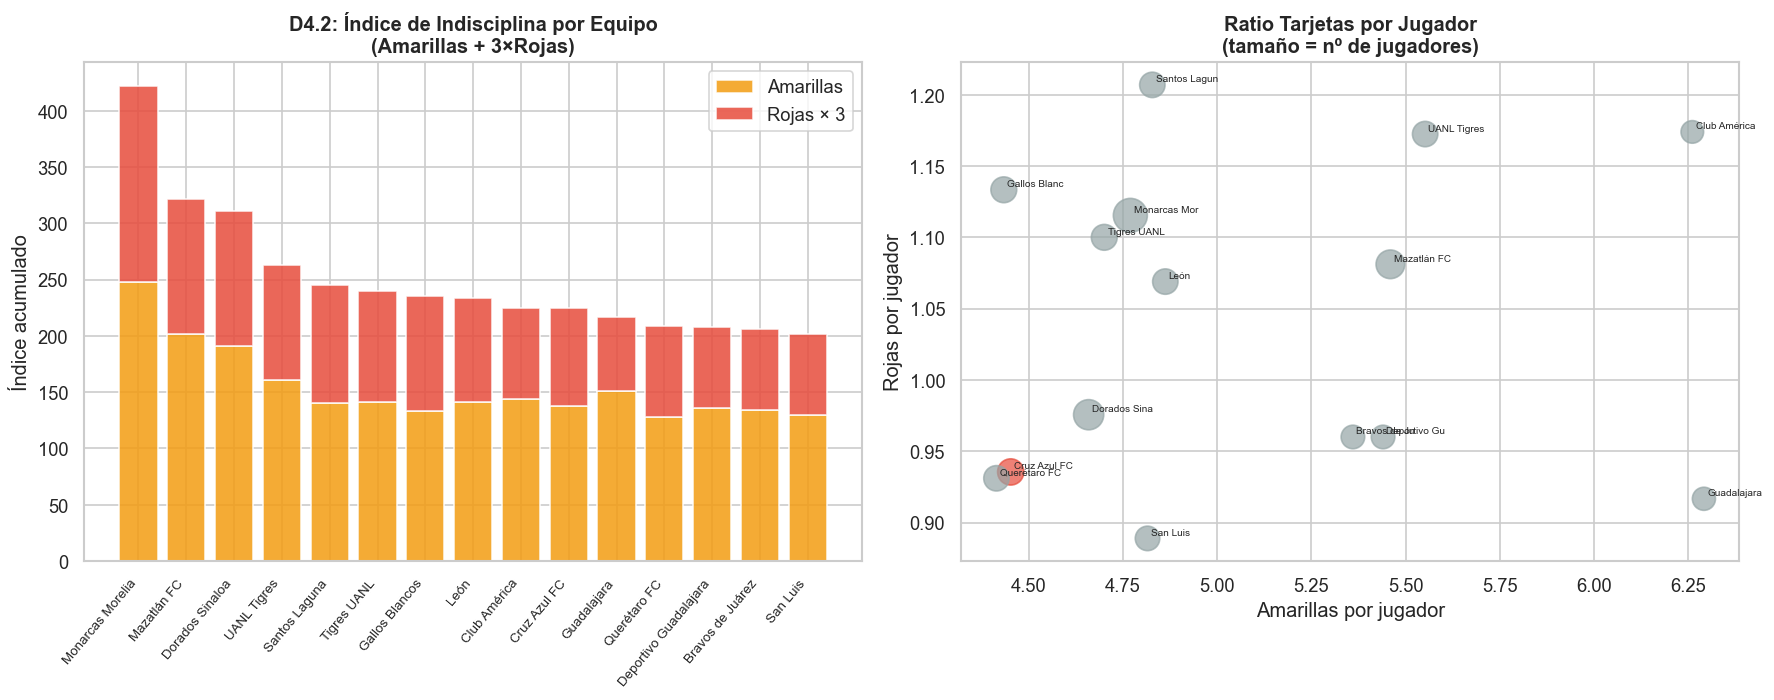

=== D4.2: TOP 10 EQUIPOS POR ÍNDICE DE INDISCIPLINA ===


,equipo,jugadores,amarillas,rojas,indice,am_x_jug,roj_x_jug
30,Monarcas Morelia,52,248,58,422,4.77,1.12
29,Mazatlán FC,37,202,40,322,5.46,1.08
20,Dorados Sinaloa,41,191,40,311,4.66,0.98
48,UANL Tigres,29,161,34,263,5.55,1.17
41,Santos Laguna,29,140,35,245,4.83,1.21
44,Tigres UANL,30,141,33,240,4.70,1.10
22,Gallos Blancos,30,133,34,235,4.43,1.13
27,León,29,141,31,234,4.86,1.07
10,Club América,23,144,27,225,6.26,1.17
17,Cruz Azul FC,31,138,29,225,4.45,0.94



Cruz Azul — Índice: 225 | Posición: #10


In [77]:
if col_tam and col_troj and col_equipo_x:
    x42 = df_xlsx[[col_equipo_x, col_tam, col_troj]].copy()
    x42[col_tam]  = pd.to_numeric(x42[col_tam],  errors='coerce').fillna(0)
    x42[col_troj] = pd.to_numeric(x42[col_troj], errors='coerce').fillna(0)
    x42 = x42.dropna(subset=[col_equipo_x])

    eq_disc = x42.groupby(col_equipo_x).agg(
        jugadores=(col_equipo_x, 'count'),
        amarillas=(col_tam, 'sum'),
        rojas=(col_troj, 'sum')
    ).reset_index()
    eq_disc.columns = ['equipo', 'jugadores', 'amarillas', 'rojas']
    eq_disc['indice'] = eq_disc['amarillas'] + 3 * eq_disc['rojas']
    eq_disc['am_x_jug'] = eq_disc['amarillas'] / eq_disc['jugadores']
    eq_disc['roj_x_jug'] = eq_disc['rojas'] / eq_disc['jugadores']
    eq_disc = eq_disc[eq_disc['jugadores'] >= 3].sort_values('indice', ascending=False)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    top15_d = eq_disc.head(15)
    x_d = np.arange(len(top15_d))
    ca_mask42 = [bool(pd.Series([e]).str.contains('Cruz|Azul|T001', case=False, na=False).any()) for e in top15_d['equipo']]
    ax1.bar(x_d, top15_d['amarillas'], label='Amarillas', color='#F39C12', alpha=0.85)
    ax1.bar(x_d, top15_d['rojas'] * 3, bottom=top15_d['amarillas'], label='Rojas × 3', color='#E74C3C', alpha=0.85)
    ax1.set_xticks(x_d)
    ax1.set_xticklabels(top15_d['equipo'], rotation=50, ha='right', fontsize=8)
    ax1.set_title('D4.2: Índice de Indisciplina por Equipo\n(Amarillas + 3×Rojas)', fontweight='bold')
    ax1.set_ylabel('Índice acumulado'); ax1.legend()

    # Amarillas/jugador vs Rojas/jugador
    colors42 = ['#E74C3C' if m else '#95A5A6' for m in ca_mask42]
    ax2.scatter(top15_d['am_x_jug'], top15_d['roj_x_jug'], s=top15_d['jugadores'] * 8, c=colors42, alpha=0.7)
    for _, row in top15_d.iterrows():
        ax2.annotate(str(row['equipo'])[:12], (row['am_x_jug'], row['roj_x_jug']), fontsize=6, ha='left', xytext=(2, 2), textcoords='offset points')
    ax2.set_xlabel('Amarillas por jugador'); ax2.set_ylabel('Rojas por jugador')
    ax2.set_title('Ratio Tarjetas por Jugador\n(tamaño = nº de jugadores)', fontweight='bold')

    plt.tight_layout()
    plt.show()

    print('=== D4.2: TOP 10 EQUIPOS POR ÍNDICE DE INDISCIPLINA ===')
    display(eq_disc.head(10).round(2))
    ca_rows = eq_disc[eq_disc['equipo'].str.contains('Cruz|Azul', case=False, na=False)]
    if len(ca_rows) > 0:
        ca_rank42 = eq_disc.index.get_loc(ca_rows.index[0]) + 1
        print(f'\nCruz Azul — Índice: {ca_rows.iloc[0]["indice"]:.0f} | Posición: #{ca_rank42}')
elif not col_tam:
    print('Columnas de tarjetas no detectadas en el XLSX. Columnas disponibles:', df_xlsx.columns.tolist())

---
### D4.3 — ¿Difiere la tasa goleadora casa/fuera entre equipos?
> **Método:** Calculamos `tasa_casa = goles_casa / p_casa` y `tasa_fuera = goles_fuera / p_fuera` por equipo. Identificamos equipos con mayor caída de rendimiento en visita.  

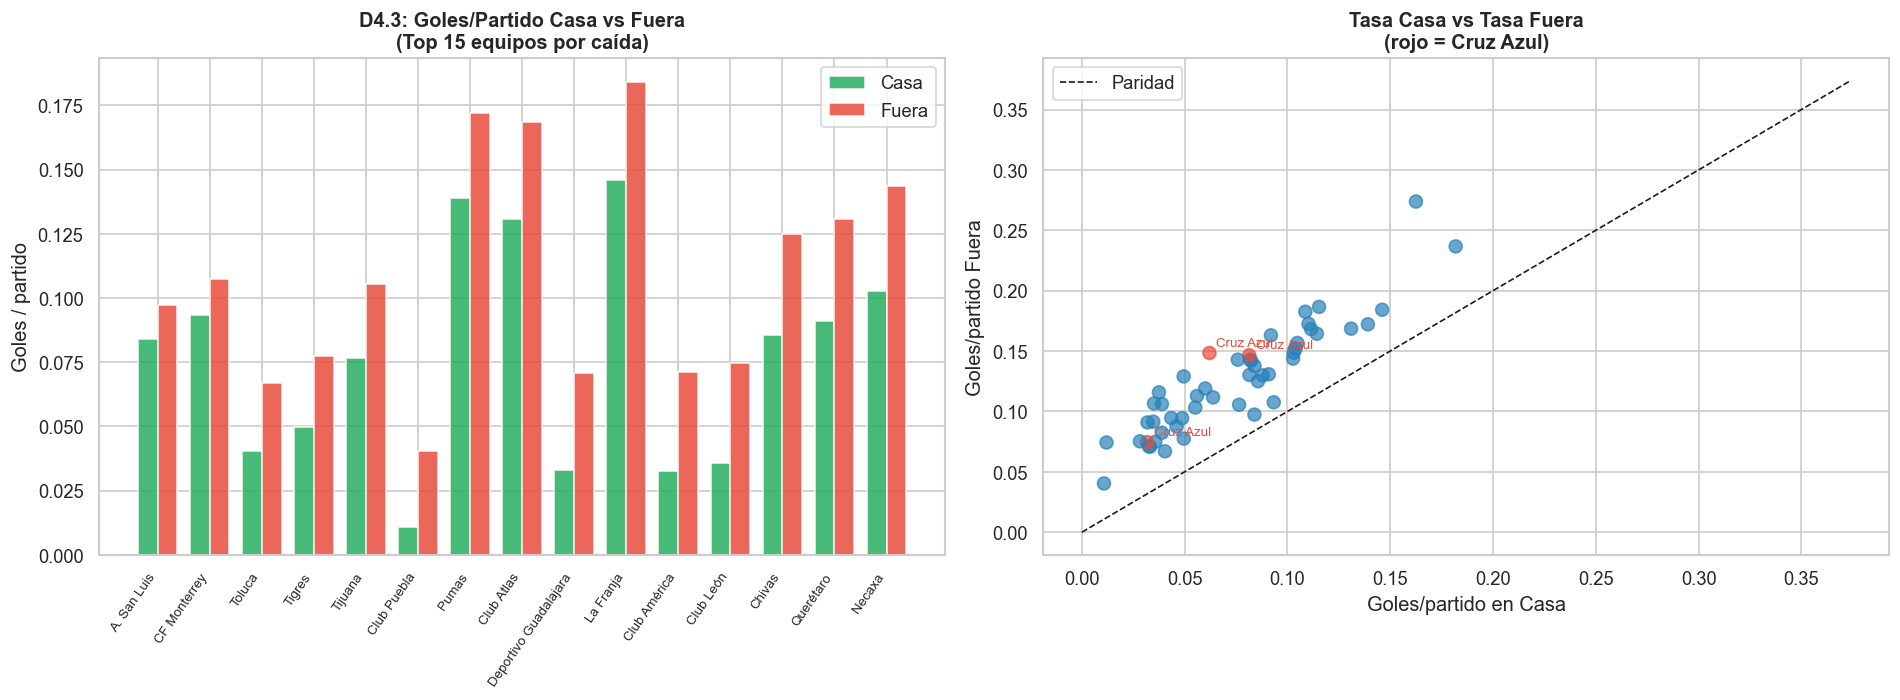

=== D4.3: TASA GOLEADORA CASA vs FUERA POR EQUIPO ===


,equipo,goles_casa,p_casa,goles_fuera,p_fuera,tasa_casa,tasa_fuera,caida
0,A. San Luis,12,143,15,154,0.084,0.097,-0.013
8,CF Monterrey,14,150,17,158,0.093,0.108,-0.014
46,Toluca,8,198,14,209,0.040,0.067,-0.027
43,Tigres,6,121,10,129,0.050,0.078,-0.028
45,Tijuana,13,170,19,180,0.076,0.106,-0.029
14,Club Puebla,1,93,4,99,0.011,0.040,-0.030
34,Pumas,16,115,21,122,0.139,0.172,-0.033
11,Club Atlas,22,168,30,178,0.131,0.169,-0.038
18,Deportivo Guadalajara,7,211,16,226,0.033,0.071,-0.038
26,La Franja,26,178,35,190,0.146,0.184,-0.038



Cruz Azul — Casa: 0.032 | Fuera: 0.075 | Caída: -0.043


In [78]:
if col_gc and col_gf and col_pc and col_pf and col_equipo_x:
    x43 = df_xlsx[[col_equipo_x, col_gc, col_gf, col_pc, col_pf]].copy()
    for c in [col_gc, col_gf, col_pc, col_pf]:
        x43[c] = pd.to_numeric(x43[c], errors='coerce')
    x43 = x43.dropna()
    x43 = x43[(x43[col_pc] > 0) & (x43[col_pf] > 0)]

    eq43 = x43.groupby(col_equipo_x).agg(
        goles_casa=(col_gc, 'sum'), partidos_casa=(col_pc, 'sum'),
        goles_fuera=(col_gf, 'sum'), partidos_fuera=(col_pf, 'sum')
    ).reset_index()
    eq43.columns = ['equipo', 'goles_casa', 'p_casa', 'goles_fuera', 'p_fuera']
    eq43['tasa_casa'] = eq43['goles_casa']  / eq43['p_casa']
    eq43['tasa_fuera'] = eq43['goles_fuera'] / eq43['p_fuera']
    eq43['caida'] = eq43['tasa_casa'] - eq43['tasa_fuera']
    eq43 = eq43[eq43['p_casa'] >= 10].sort_values('caida', ascending=False)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    top15_43 = eq43.head(15)
    x43_idx = np.arange(len(top15_43))
    w43 = 0.38
    ax1.bar(x43_idx - w43/2, top15_43['tasa_casa'], w43, label='Casa', color='#27AE60', alpha=0.85)
    ax1.bar(x43_idx + w43/2, top15_43['tasa_fuera'], w43, label='Fuera', color='#E74C3C', alpha=0.85)
    ax1.set_xticks(x43_idx)
    ax1.set_xticklabels(top15_43['equipo'], rotation=55, ha='right', fontsize=8)
    ax1.set_title('D4.3: Goles/Partido Casa vs Fuera\n(Top 15 equipos por caída)', fontweight='bold')
    ax1.set_ylabel('Goles / partido'); ax1.legend()

    # tasa_casa vs tasa_fuera
    ca_mask43 = eq43['equipo'].str.contains('Cruz|Azul', case=False, na=False)
    ax2.scatter(eq43['tasa_casa'], eq43['tasa_fuera'], c=['#E74C3C' if m else '#2980B9' for m in ca_mask43], s=60, alpha=0.7)
    lim43 = max(eq43['tasa_casa'].max(), eq43['tasa_fuera'].max()) + 0.1
    ax2.plot([0, lim43], [0, lim43], 'k--', lw=1, label='Paridad')
    ax2.set_xlabel('Goles/partido en Casa'); ax2.set_ylabel('Goles/partido Fuera')
    ax2.set_title('Tasa Casa vs Tasa Fuera\n(rojo = Cruz Azul)', fontweight='bold')
    ax2.legend()
    for _, row in eq43[ca_mask43].iterrows():
        ax2.annotate('Cruz Azul', (row['tasa_casa'], row['tasa_fuera']), fontsize=8, color='#E74C3C', xytext=(4, 4), textcoords='offset points')

    plt.tight_layout()
    plt.show()

    print('=== D4.3: TASA GOLEADORA CASA vs FUERA POR EQUIPO ===')
    display(eq43.sort_values('caida', ascending=False).round(3))
    ca43 = eq43[ca_mask43]
    if len(ca43) > 0:
        print(f'\nCruz Azul — Casa: {ca43.iloc[0]["tasa_casa"]:.3f} | Fuera: {ca43.iloc[0]["tasa_fuera"]:.3f}'
              f' | Caída: {ca43.iloc[0]["caida"]:.3f}')
elif not (col_gc and col_gf):
    print('Columnas goles_casa/goles_fuera no detectadas. Disponibles:', df_xlsx.columns.tolist())

---
### P4.4 — ¿Se puede predecir si un jugador recibirá tarjeta roja?
> **Método:** A través de clasificación binaria (tarj_roj > 0 = 1) implementada con Regresión Logística + Random Forest. Features: `tarj_am`, `p_casa`, `p_fuera`, `goles_casa`, `goles_fuera`. 

Distribución target: Sin roja=398 | Con roja=767
=== P4.4: PREDICCIÓN TARJETA ROJA (XLSX) ===
              precision    recall  f1-score   support

    Sin roja       0.38      0.54      0.44       100
    Con roja       0.69      0.53      0.60       192

    accuracy                           0.53       292
   macro avg       0.53      0.54      0.52       292
weighted avg       0.58      0.53      0.55       292

AUC-ROC: 0.5436


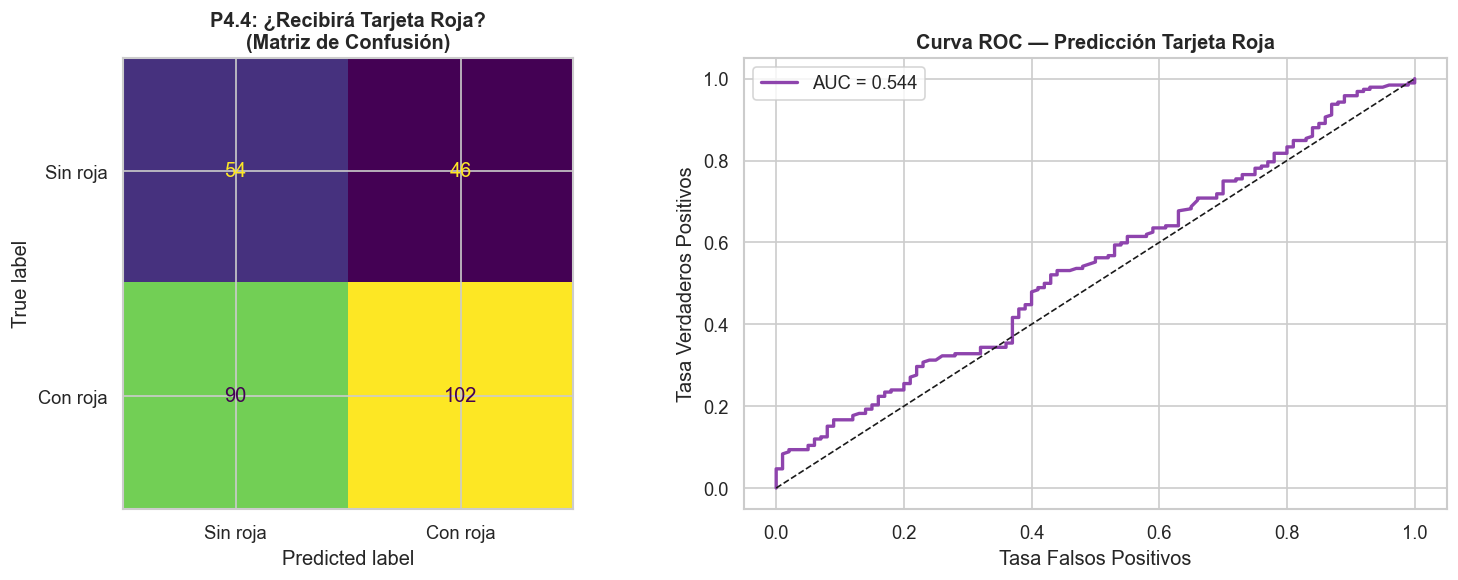


Importancia de variables:


tarj_am        0.2799
p_fuera        0.2249
p_casa         0.1852
goles_fuera    0.1735
goles_casa     0.1364
dtype: float64

In [80]:
feats44_cols = [c for c in [col_tam, col_pc, col_pf, col_gc, col_gf] if c is not None]

if col_troj and len(feats44_cols) >= 2:
    x44 = df_xlsx[feats44_cols + [col_troj]].copy()
    for c in feats44_cols + [col_troj]:
        x44[c] = pd.to_numeric(x44[c], errors='coerce')
    x44 = x44.dropna()
    x44['target'] = (x44[col_troj] > 0).astype(int)

    X44 = x44[feats44_cols].values
    y44 = x44['target'].values

    print(f'Distribución target: Sin roja={( y44==0).sum()} | Con roja={(y44==1).sum()}')

    X44_tr, X44_te, y44_tr, y44_te = train_test_split(X44, y44, test_size=0.25, random_state=42, stratify=y44)
    rf44 = RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42, class_weight='balanced')
    rf44.fit(X44_tr, y44_tr)
    y44_pred = rf44.predict(X44_te)
    y44_prob = rf44.predict_proba(X44_te)[:, 1]
    auc44 = roc_auc_score(y44_te, y44_prob)

    print('=== P4.4: PREDICCIÓN TARJETA ROJA (XLSX) ===')
    print(classification_report(y44_te, y44_pred, target_names=['Sin roja', 'Con roja']))
    print(f'AUC-ROC: {auc44:.4f}')

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

    cm44 = confusion_matrix(y44_te, y44_pred)
    ConfusionMatrixDisplay(cm44, display_labels=['Sin roja', 'Con roja']).plot(ax=ax1, colorbar=False)
    ax1.set_title('P4.4: ¿Recibirá Tarjeta Roja?\n(Matriz de Confusión)', fontweight='bold')

    fpr44, tpr44, _ = roc_curve(y44_te, y44_prob)
    ax2.plot(fpr44, tpr44, color='#8E44AD', lw=2, label=f'AUC = {auc44:.3f}')
    ax2.plot([0, 1], [0, 1], 'k--', lw=1)
    ax2.set_xlabel('Tasa Falsos Positivos'); ax2.set_ylabel('Tasa Verdaderos Positivos')
    ax2.set_title('Curva ROC — Predicción Tarjeta Roja', fontweight='bold')
    ax2.legend()

    plt.tight_layout()
    plt.show()

    imp44 = pd.Series(rf44.feature_importances_, index=feats44_cols).sort_values(ascending=False)
    print('\nImportancia de variables:')
    display(imp44.round(4))
else:
    print('Columnas de tarjetas insuficientes:', df_xlsx.columns.tolist())

---
### PR4.5 — ¿Qué jugadores externos a Cruz Azul tienen mejor rendimiento ofensivo en visita?
> **Método:** Calculamos `tasa_goles_visita = goles_fuera / p_fuera` por jugador. Filtramos jugadores con al menos 5 partidos fuera, excluyendo a los de Cruz Azul. Con lo anterior, creamos un índice combinado con tasa_goles_visita y tasa_goles_total.  

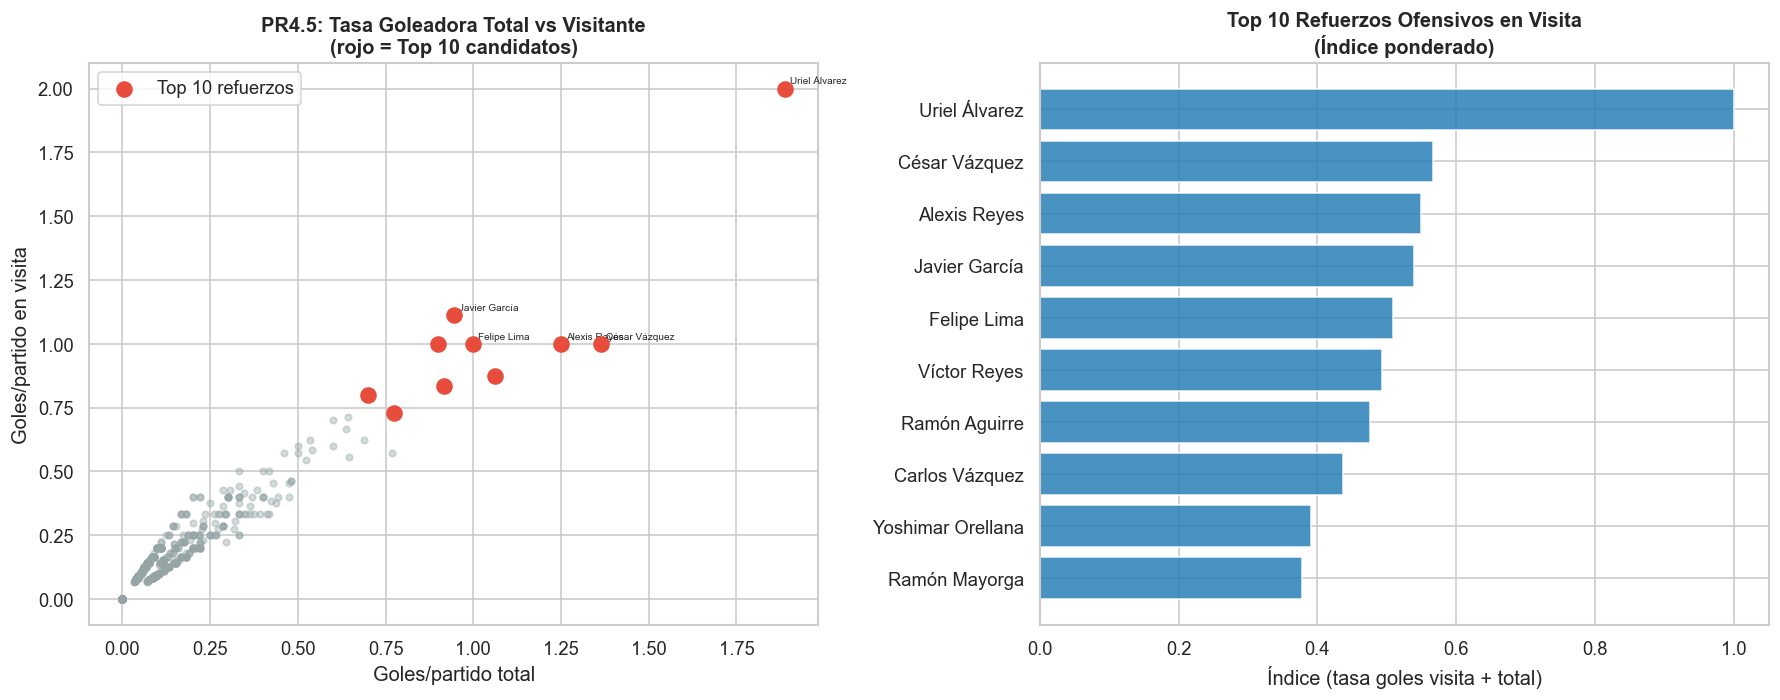

=== PR4.5: TOP 10 REFUERZOS OFENSIVOS PARA CRUZ AZUL (RENDIMIENTO VISITANTE) ===
(Jugadores con ≥5 partidos fuera, excluidos los de Cruz Azul)



,nombre_tm,equipo,goles_casa,p_casa,goles_fuera,p_fuera,tasa_goles_visita,indice_visita
551,Uriel Álvarez,Club Atlas,7,4,10,5,2.000,1.000
998,César Vázquez,La Franja,9,5,6,6,1.000,0.567
608,Alexis Reyes,Mazatlán FC,9,6,6,6,1.000,0.549
32,Javier García,FC Juárez,7,9,10,9,1.111,0.539
127,Felipe Lima,Guadalajara,5,5,6,6,1.000,0.509
133,Víctor Reyes,Querétaro FC,4,5,5,5,1.000,0.493
1057,Ramón Aguirre,Tigres UANL,10,8,7,8,0.875,0.475
241,Carlos Vázquez,Monarcas Morelia,6,6,5,6,0.833,0.437
278,Yoshimar Orellana,Tijuana,3,5,4,5,0.800,0.391
597,Ramón Mayorga,Bravos de Juárez,9,11,8,11,0.727,0.377



PRESCRIPCIÓN: Estos jugadores mantienen una alta producción goleadora fuera de casa.
Cruz Azul debería priorizarlos en el mercado de invierno para reforzar su ataque visitante.


In [81]:
nombre_x_col = next((c for c in df_xlsx.columns if 'nombre' in c.lower() and 'tm' in c.lower()), None)
if nombre_x_col is None:
    nombre_x_col = next((c for c in df_xlsx.columns if 'nombre' in c.lower()), None)

if col_gf and col_pf and col_equipo_x:
    x45 = df_xlsx.copy()
    for c in [col_gf, col_pf, col_gc, col_pc]:
        if c:
            x45[c] = pd.to_numeric(x45[c], errors='coerce')
    x45 = x45.dropna(subset=[col_gf, col_pf])
    x45 = x45[(x45[col_pf] >= 5)]  # al menos 5 partidos fuera

    # Excluimos Cruz Azul
    x45 = x45[~x45[col_equipo_x].str.contains('Cruz|Azul|T001', case=False, na=False)]

    x45['tasa_goles_visita'] = x45[col_gf] / x45[col_pf]
    if col_gc and col_pc:
        x45 = x45[x45[col_pc] > 0]
        x45['tasa_goles_total'] = (x45[col_gc].fillna(0) + x45[col_gf]) / (x45[col_pc].fillna(0) + x45[col_pf])
    else:
        x45['tasa_goles_total'] = x45['tasa_goles_visita']

    # Índice: 70% visita + 30% total
    sc45 = MinMaxScaler()
    x45['tv_n'] = sc45.fit_transform(x45[['tasa_goles_visita']])
    x45['tt_n'] = sc45.fit_transform(x45[['tasa_goles_total']])
    x45['indice_visita'] = x45['tv_n'] * 0.70 + x45['tt_n'] * 0.30

    top10_v = x45.nlargest(10, 'indice_visita')

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    ax1.scatter(x45['tasa_goles_total'], x45['tasa_goles_visita'], alpha=0.4, s=15, color='#95A5A6')
    ax1.scatter(top10_v['tasa_goles_total'], top10_v['tasa_goles_visita'], color='#E74C3C', s=80, zorder=5, label='Top 10 refuerzos')
    ax1.set_xlabel('Goles/partido total'); ax1.set_ylabel('Goles/partido en visita')
    ax1.set_title('PR4.5: Tasa Goleadora Total vs Visitante\n(rojo = Top 10 candidatos)', fontweight='bold')
    ax1.legend()
    if nombre_x_col:
        for _, row in top10_v.head(5).iterrows():
            ax1.annotate(str(row[nombre_x_col])[:14], (row['tasa_goles_total'], row['tasa_goles_visita']), fontsize=6, xytext=(3, 3), textcoords='offset points')

    # Barras índice top 10
    top10_s = top10_v.sort_values('indice_visita')
    nombre_label = nombre_x_col if nombre_x_col else col_equipo_x
    ax2.barh(top10_s[nombre_label].astype(str), top10_s['indice_visita'], color='#2980B9', alpha=0.85)
    ax2.set_title('Top 10 Refuerzos Ofensivos en Visita\n(Índice ponderado)', fontweight='bold')
    ax2.set_xlabel('Índice (tasa goles visita + total)')

    plt.tight_layout()
    plt.show()

    print('=== PR4.5: TOP 10 REFUERZOS OFENSIVOS PARA CRUZ AZUL (RENDIMIENTO VISITANTE) ===')
    print('(Jugadores con ≥5 partidos fuera, excluidos los de Cruz Azul)\n')
    cols_show = [c for c in [nombre_x_col, col_equipo_x, col_gc, col_pc, col_gf, col_pf, 'tasa_goles_visita', 'indice_visita'] if c and c in top10_v.columns]
    disp45 = top10_v[cols_show].round(3)
    display(disp45)
    print('\nPRESCRIPCIÓN: Estos jugadores mantienen una alta producción goleadora fuera de casa.')
    print('Cruz Azul debería priorizarlos en el mercado de invierno para reforzar su ataque visitante.')
else:
    print('Columnas goles_fuera/p_fuera no detectadas:', df_xlsx.columns.tolist())